# 1. Import Libraries & Setup

In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print(gpus)
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU Memory Growth Enabled")
    except RuntimeError as e:
        print(e)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU Memory Growth Enabled


In [2]:
# !pip install tensorflow pandas matplotlib seaborn nltk gensim scikit-learn wordcloud
# !pip install "numpy<2.0.0"

In [3]:
# Core libraries
import pandas as pd
import numpy as np
from scipy.stats import gmean
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modern NLP libraries
import re
from collections import Counter

# Sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_curve, auc
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.decomposition import TruncatedSVD

# Deep Learning libraries
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, SimpleRNN, Bidirectional, Embedding, Dropout, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Modern word embeddings
from gensim.models import Word2Vec

# Utilities
from wordcloud import WordCloud

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 2. NLTK Tools & Data

In [4]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [5]:
# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# 3. Data Loading and Initial Data Exploration thorugh Pandas

In [6]:
TRAIN_CSV = "C:/Users/User/Documents/CSE440_Project/Question Answer Classification Dataset 3.csv"
TEST_CSV = "C:/Users/User/Documents/CSE440_Project/[Updated] Question Answer Classification Dataset[Test].csv"

In [7]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

In [8]:
# Create a summary comparison DataFrame
summary = pd.DataFrame({
    'Train': [
        train_df.shape,
        train_df.columns.tolist(),
        train_df.isnull().sum().sum(),
        train_df.select_dtypes(include=['object']).columns.tolist()
    ],
    'Test': [
        test_df.shape,
        test_df.columns.tolist(),
        test_df.isnull().sum().sum(),
        test_df.select_dtypes(include=['object']).columns.tolist()
    ]
}, index=['Shape', 'Columns', 'Total Nulls', 'Object Columns'])

print("=== SUMMARY COMPARISON ===")
display(summary)

# Show head side by side
print("\n=== HEAD - TRAIN ===")
display(train_df.head())
print("\n=== HEAD - TEST ===")
display(test_df.head())

# Show tail side by side
print("\n=== TAIL - TRAIN ===")
display(train_df.tail())
print("\n=== TAIL - TEST ===")
display(test_df.tail())

# Side by side describe
print("\n=== DESCRIBE - TRAIN ===")
display(train_df.describe())
print("\n=== DESCRIBE - TEST ===")
display(test_df.describe())

=== SUMMARY COMPARISON ===


,Train,Test
Shape,"(93333, 2)","(59999, 2)"
Columns,"[QA Text, Class]","[QA Text, Class]"
Total Nulls,0,0
Object Columns,"[QA Text, Class]","[QA Text, Class]"



=== HEAD - TRAIN ===


,QA Text,Class
0,<html> Question Title:\n <br> can a sinus infe...,Health
1,<html> Question Title:\n <br> i m in 12th.i wa...,Education & Reference
2,<html> Question Title:\n <br> Which issue is m...,Society & Culture
3,"<html> Question Title:\n <br> what does ""ily"" ...",Education & Reference
4,<html> Question Title:\n <br> notebook-sony va...,Computers & Internet



=== HEAD - TEST ===


,QA Text,Class
0,<html>\nQuestion Title:<br>Why does Zebras hav...,Science & Mathematics
1,<html>\nQuestion Title:<br>What did the itsy b...,Education & Reference
2,<html>\nQuestion Title:<br>What is the differe...,Education & Reference
3,<form>\nQuestion Title:<br>Why do women get PM...,Health
4,<html>\nQuestion Title:<br>If your co-worker i...,Health



=== TAIL - TRAIN ===


,QA Text,Class
93328,<html> Question Title:\n <br> how do i know if...,Family & Relationships
93329,<html> Question Title:\n <br> Sometimes I get ...,Family & Relationships
93330,"<html> Question Title:\n <br> In fact, how muc...",Society & Culture
93331,<html> Question Title:\n <br> list of germany ...,Sports
93332,<html> Question Title:\n <br> How can I find o...,Politics & Government



=== TAIL - TEST ===


,QA Text,Class
59994,<html>\nQuestion Title:<br>if you could be any...,Family & Relationships
59995,<html>\nQuestion Title:<br>Tell me something a...,Entertainment & Music
59996,<form>\nQuestion Title:<br>Why are men always ...,Health
59997,<html>\nQuestion Title:<br>est ce que DOMENECH...,Sports
59998,<form>\nQuestion Title:<br>No sound or low sou...,Computers & Internet



=== DESCRIBE - TRAIN ===


,QA Text,Class
count,93333,93333
unique,93333,10
top,<html> Question Title:\n <br> can a sinus infe...,Entertainment & Music
freq,1,9455



=== DESCRIBE - TEST ===


,QA Text,Class
count,59999,59999
unique,59999,10
top,<html>\nQuestion Title:<br>Why does Zebras hav...,Science & Mathematics
freq,1,6000


# 4. Deep EDA for Training Data

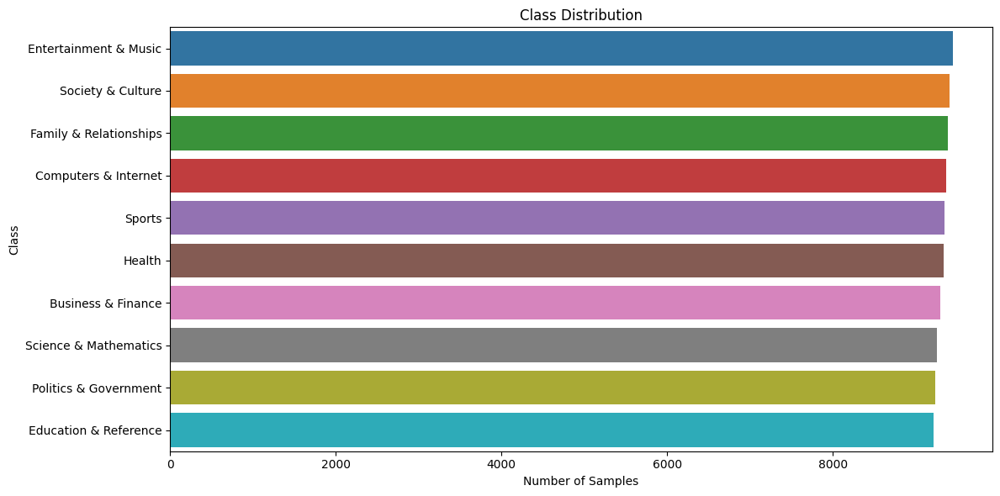

In [9]:
# Class Distribution
class_counts = train_df['Class'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.values, y=class_counts.index, hue=class_counts.index)
plt.title('Class Distribution')
plt.xlabel('Number of Samples')
plt.ylabel('Class')
plt.tight_layout()
plt.savefig('class_distribution.png')

Text(0.5, 1.0, 'Class Distribution (Pie Chart)')

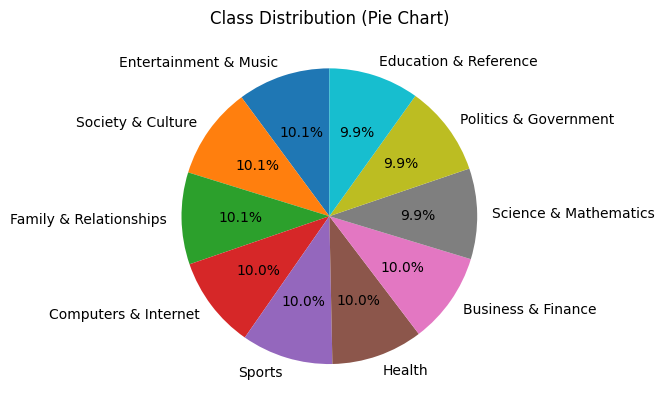

In [10]:
# Class distribution pie chart
plt.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution (Pie Chart)')

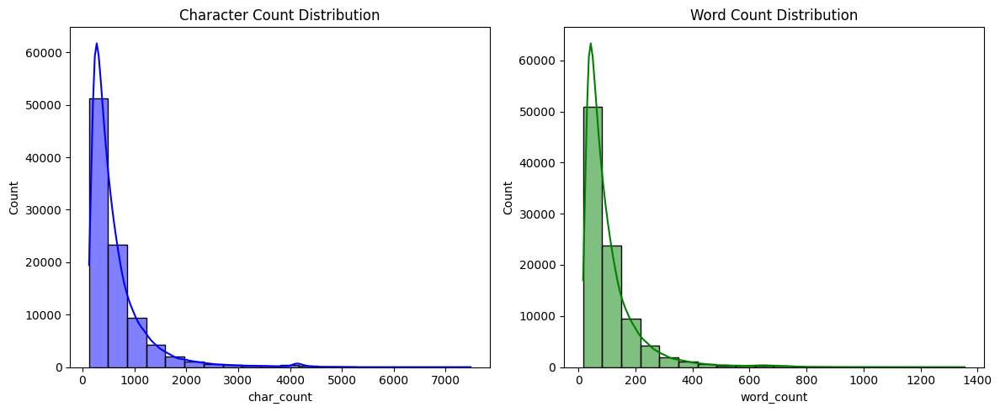

In [11]:
# Text Length Analysis
train_df['char_count'] = train_df['QA Text'].apply(len)   # Counts characters
train_df['word_count'] = train_df['QA Text'].apply(lambda x: len(x.split())) # Counts words

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(train_df['char_count'], bins=20, kde=True, color='blue')
plt.title('Character Count Distribution')

plt.subplot(1, 2, 2)
sns.histplot(train_df['word_count'], bins=20, kde=True, color='green')
plt.title('Word Count Distribution')
plt.tight_layout()
plt.savefig('text_length_distributions.png')

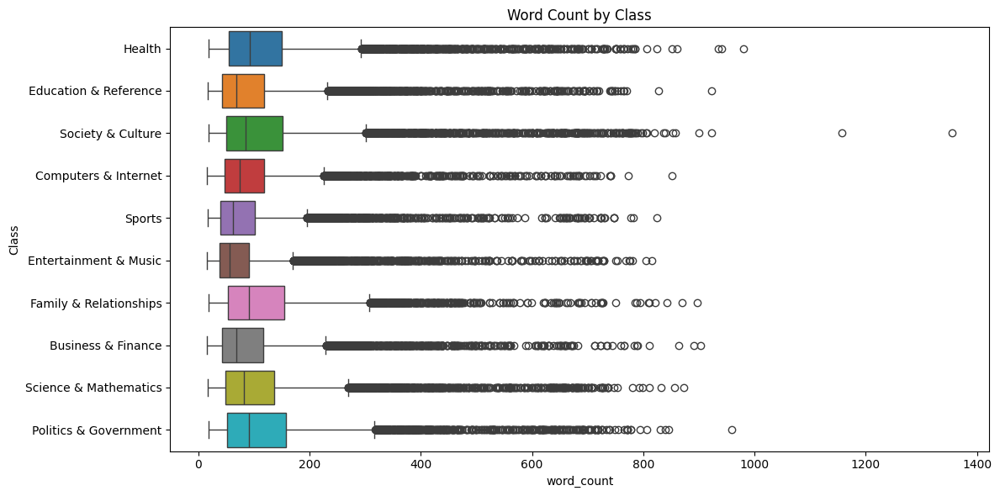

In [12]:
# Class-wise Word Count Distribution
plt.figure(figsize=(12, 6))
sns.boxplot(x='word_count', y='Class', data=train_df, hue='Class')
plt.title('Word Count by Class')
plt.tight_layout()
plt.savefig('word_count_by_class.png')

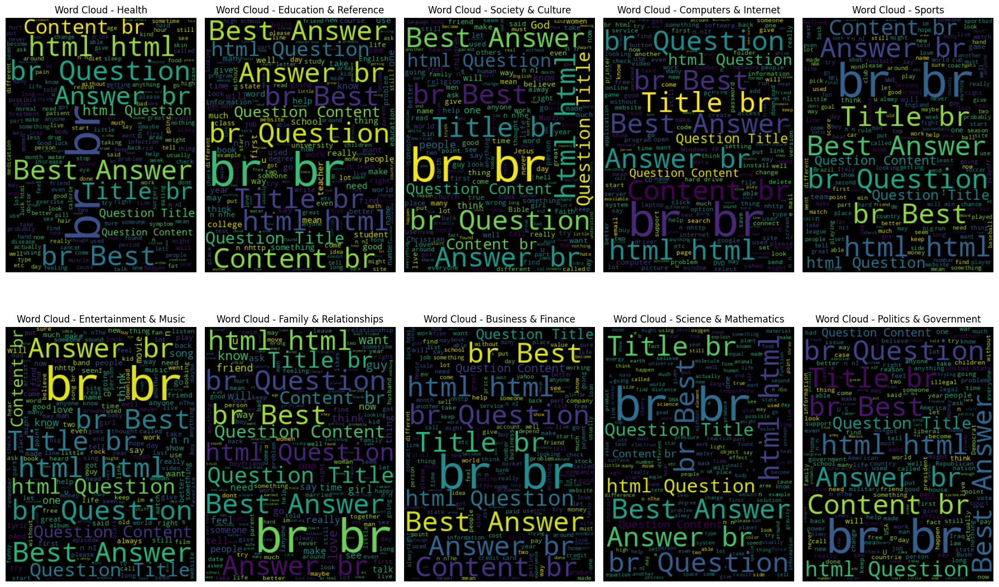

In [13]:
# Generate word clouds for different classes
classes = train_df['Class'].unique()

fig, axes = plt.subplots(2, len(classes)//2, figsize=(18, 12))
axes = axes.ravel()

for i, class_name in enumerate(classes):
    class_text = ' '.join(train_df[train_df['Class'] == class_name]['QA Text'].astype(str))
    wordcloud = WordCloud(width=300, height=400, background_color='black').generate(class_text)

    axes[i].imshow(wordcloud.to_image(), interpolation='bilinear')
    axes[i].set_title(f'Word Cloud - {class_name}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# 5. Pre Processing

## 5.1 Removing HTML Tags

In [14]:
def check_html_tags(df):
    # Check for HTML tags
    html_tag_pattern = re.compile(r'<[^>]+>')
    df['has_html'] = df['QA Text'].apply(lambda x: bool(html_tag_pattern.search(x)))
    html_presence = df['has_html'].value_counts()

    print(f"HTML tags are in {int(html_presence[True])} out of {len(df)} entries")

In [15]:
def remove_html_tags(df):

    def get_most_common_words(text_list, n=20):
        all_words = " ".join(text_list).lower().split()
        return Counter(all_words).most_common(n)

    def clean_html(text):
        split_text = text.split()                             # split text into a list of words by spaces
        clean_text = []
        for word in split_text:
            # If there are no brackets, it's a "safe" word
            if '<' not in word and '>' not in word:
                clean_text.append(word)
            else:
                # Split by '<' and for each segment, take everything after the '>'
                parts = word.split('<')
                for part in parts:
                    if '>' in part:
                        # Keep only the text after the closing tag
                        content = part.split('>')[-1]
                        if content:
                            clean_text.append(content)
                    elif part:
                        # Keep text that didn't have a '>' (text before the first tag)
                        clean_text.append(part)

        return " ".join(clean_text)                           # stick the list back into a single string without any tags

                       # saves the clean version in a new column called No HTML

    print("Top 20 words before cleaning:")
    print(get_most_common_words(df['QA Text']))

    df['No HTML'] = df['QA Text'].apply(clean_html)


    print("\nTop 20 words after removing HTML and headers:")
    print(get_most_common_words(df['No HTML']))

    return df

## 5.2 Divide Text into Title, Content, and Answer

In [16]:
def divide_into_columns(df):

    pattern = (
        r'(?:Question Title:\s*(?P<Question_Title>.*?))?'
        r'(?:\s*Question Content:\s*(?P<Question_Content>.*?))?'
        r'(?:\s*Best Answer:\s*(?P<Best_Answer>.*))?$'
    )

    extracted = df['No HTML'].str.extract(    # Applies the pattern and returns a new DataFrame with 3 columns (Title, Content, Answer).
        pattern,
        flags=re.DOTALL         # Allows the regex . to match newlines (Enter key), so it captures multi-line paragraphs.
    )

    # Assign to new columns
    df[['Question Title', 'Question Content', 'Best Answer']] = extracted

In [17]:
def count_word_by_class(df):
    df['word_title'] = df['Question Title'].apply(lambda x: len(x.split()))
    df['word_content'] = df['Question Content'].apply(lambda x: len(x.split()))
    df['word_answer'] = df['Best Answer'].apply(lambda x: len(x.split()))

    word_counts_by_class = (df.groupby('Class')[['word_title', 'word_content', 'word_answer']].sum())

    return word_counts_by_class

In [18]:
def count_char_by_class(df):
    df['char_title'] = df['Question Title'].apply(len)
    df['char_content'] = df['Question Content'].apply(len)
    df['char_answer'] = df['Best Answer'].apply(len)

    char_counts_by_class = (df.groupby('Class')[['char_title', 'char_content', 'char_answer']].sum())

    return char_counts_by_class

In [19]:
def empty_summary_by_class(df):
    df['empty_title'] = df['Question Title'].apply(lambda x: len(x)<1 | (x.strip() == ""))

    df['empty_content'] = df['Question Content'].apply(lambda x: len(x)<1 | (x.strip() == ""))

    df['empty_answer'] = df['Best Answer'].apply(lambda x: len(x)<1 | (x.strip() == ""))

    empty_summary = (df.groupby('Class')[['empty_title', 'empty_content', 'empty_answer']].sum())

    return empty_summary

## 5.3 Feature Engineering

In [20]:
def feature_engineering(df):
    # Mapping columns to their specific replacement strings
    replacements = {
        "Question Title": "empty title",
        "Question Content": "empty content",
        "Best Answer": "empty answer"
    }

    # Replace exact empty strings ("") with the values in the dictionary
    return df.replace({col: {"": val} for col, val in replacements.items()})

## 5.4 NLTK


Cleaning steps:

- Lowercase
- Remove URLs & emails
- Remove non-alphabetic characters
- Tokenize
- Stopword removal
- Lemmatization

In [21]:
def preprocess_nltk(df):

    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    url_re = re.compile(r'(https?://\S+|www\.\S+)')
    email_re = re.compile(r'\b[\w\.-]+@[\w\.-]+\.\w+\b')
    non_letter_re = re.compile(r'[^a-zA-Z\s]')

    def clean_text(text):
        # Convert to string and lowercase
        text = str(text).lower()

        # 1. Remove URLs and Emails first (before structure is destroyed)
        text = url_re.sub('', text)
        text = email_re.sub('', text)

        # 2. Remove non-alphabetic characters
        text = non_letter_re.sub('', text)

        # 3. Tokenize
        tokens = word_tokenize(text)

        # 4. Remove Stopwords & Lemmatize
        cleaned = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]

        return " ".join(cleaned)

    # Combine columns
    df['combined_text'] = (
        df['Question Title'].fillna('') + " " +
        df['Question Content'].fillna('') + " " +
        df['Best Answer'].fillna('')
    )

    # Apply cleaning
    df['cleaned_text_No_HTML'] = df['No HTML'].apply(clean_text)
    df['cleaned_text_feature_engineered'] = df['combined_text'].apply(clean_text)

    return df

## 5.5 Preprocess Train and Test

### Train DF

In [22]:
check_html_tags(train_df)
remove_html_tags(train_df)

divide_into_columns(train_df)

train_df = feature_engineering(train_df)

train_df = preprocess_nltk(train_df)

HTML tags are in 93333 out of 93333 entries
Top 20 words before cleaning:
[('<br>', 559998), ('the', 357295), ('to', 235943), ('and', 202635), ('a', 200721), ('question', 191617), ('of', 159955), ('i', 158611), ('is', 144000), ('you', 138215), ('in', 120738), ('answer:', 93408), ('title:', 93345), ('content:', 93335), ('<html>', 93333), ('<br><br><br>', 93333), ('<br>best', 93333), ('</html>', 93333), ('that', 92888), ('it', 91351)]

Top 20 words after removing HTML and headers:
[('the', 357309), ('to', 235948), ('and', 202640), ('a', 200771), ('question', 191617), ('of', 159955), ('i', 158628), ('is', 144005), ('you', 138216), ('in', 120745), ('best', 102634), ('answer:', 93408), ('title:', 93345), ('content:', 93335), ('that', 92895), ('it', 91352), ('for', 80842), ('are', 66096), ('have', 64058), ('on', 56813)]


In [23]:
# Display comparison for the first row
print("Original Dataset Text excerpt:", train_df['QA Text'].iloc[0][:100], "...")
print("\nRaw (HTML removed):", train_df['No HTML'].iloc[0][:100], "...")
print("\nCombined Text After Feature Engineering:", train_df['combined_text'].iloc[0][:100], "...")
print("\nCleaned Text (No HTML) After NLTK Preprocessing:", train_df['cleaned_text_No_HTML'].iloc[0][:100], "...")
print("\nCleaned Text (Feature Engineered) After NLTK Preprocessing:", train_df['cleaned_text_feature_engineered'].iloc[0][:100], "...")

Original Dataset Text excerpt: <html> Question Title:
 <br> can a sinus infection cause a swollen lymph node, sore throat, and ear  ...

Raw (HTML removed): Question Title: can a sinus infection cause a swollen lymph node, sore throat, and ear congestion? Q ...

Combined Text After Feature Engineering: can a sinus infection cause a swollen lymph node, sore throat, and ear congestion? there is no fever ...

Cleaned Text (No HTML) After NLTK Preprocessing: question title sinus infection cause swollen lymph node sore throat ear congestion question content  ...

Cleaned Text (Feature Engineered) After NLTK Preprocessing: sinus infection cause swollen lymph node sore throat ear congestion fever wieght loss night sweat na ...


### Test DF

In [24]:
check_html_tags(test_df)
remove_html_tags(test_df)

divide_into_columns(test_df)

test_df = feature_engineering(test_df)

test_df = preprocess_nltk(test_df)

HTML tags are in 59999 out of 59999 entries
Top 20 words before cleaning:
[('the', 225072), ('to', 151404), ('and', 129521), ('a', 127547), ('of', 102497), ('is', 89205), ('you', 86077), ('i', 84397), ('in', 76282), ('question', 63046), ('that', 59325), ('it', 55919), ('for', 51045), ('are', 41114), ('have', 41067), ('on', 36678), ('be', 36060), ('<html>', 36038), ('</html>', 36038), ('with', 33602)]

Top 20 words after removing HTML and headers:
[('the', 229130), ('to', 151843), ('and', 129854), ('a', 129074), ('question', 123178), ('of', 102653), ('i', 101540), ('is', 92817), ('you', 88568), ('in', 77523), ('best', 65966), ('answer:', 60037), ('title:', 60001), ('content:', 60000), ('that', 59757), ('it', 58247), ('for', 51685), ('are', 42251), ('have', 41607), ('on', 36964)]


In [25]:
# Display comparison for the first row
print("Original Dataset Text excerpt:", test_df['QA Text'].iloc[0], "...")
print("\nRaw (HTML removed):", test_df['No HTML'].iloc[0], "...")
print("\nCombined Text After Feature Engineering:", test_df['combined_text'].iloc[0], "...")
print("\nCleaned Text (No HTML) After NLTK Preprocessing:", test_df['cleaned_text_No_HTML'].iloc[0], "...")
print("\nCleaned Text (Feature Engineered) After NLTK Preprocessing:", test_df['cleaned_text_feature_engineered'].iloc[0], "...")

Original Dataset Text excerpt: <html>
Question Title:<br>Why does Zebras have stripes?<br><br>Question Content:<br>What is the purpose or those stripes? Who do they serve the Zebras in the wild life?<br><br>Best Answer:<br>this provides camouflage - predator vision is such that it is usually difficult for them to see complex patterns
</html> ...

Raw (HTML removed): Question Title: Why does Zebras have stripes? Question Content: What is the purpose or those stripes? Who do they serve the Zebras in the wild life? Best Answer: this provides camouflage - predator vision is such that it is usually difficult for them to see complex patterns ...

Combined Text After Feature Engineering: Why does Zebras have stripes? What is the purpose or those stripes? Who do they serve the Zebras in the wild life? this provides camouflage - predator vision is such that it is usually difficult for them to see complex patterns ...

Cleaned Text (No HTML) After NLTK Preprocessing: question title zebra stripe 

In [26]:
# STOPWORDS = set(stopwords.words('english'))
# LEMMATIZER = WordNetLemmatizer()

# _RE_TAGS = re.compile(r'<[^>]+>')
# _RE_URL = re.compile(r'(https?://\S+|www\.\S+)')
# _RE_EMAIL = re.compile(r'\b[\w\.-]+@[\w\.-]+\.\w+\b')
# _RE_NON_LETTERS = re.compile(r'[^a-zA-Z\s]')

# def clean_text(text: str) -> str:
#     if not isinstance(text, str):
#         text = '' if text is None else str(text)

#     # Remove HTML and normalize whitespace
#     text = _RE_TAGS.sub(' ', text)
#     text = text.replace('\n', ' ').replace('\r', ' ')

#     # Lowercase
#     text = text.lower()

#     # Remove urls/emails
#     text = _RE_URL.sub(' ', text)
#     text = _RE_EMAIL.sub(' ', text)

#     # Keep letters and spaces only
#     text = _RE_NON_LETTERS.sub(' ', text)

#     # Tokenize
#     tokens = nltk.word_tokenize(text)

#     # Stopword removal + lemmatization
#     tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
#     tokens = [LEMMATIZER.lemmatize(t) for t in tokens]

#     return ' '.join(tokens)

# # Quick sanity check
# example_raw = train_df['QA Text'].iloc[0]
# print('RAW:')
# print(example_raw[:300])
# print('\nCLEAN:')
# print(clean_text(example_raw)[:300])

# train_df['clean_text'] = train_df['QA Text'].astype(str).apply(clean_text)
# test_df['clean_text'] = test_df['QA Text'].astype(str).apply(clean_text)

# # Remove any empty rows after cleaning
# train_df = train_df[train_df['clean_text'].str.len() > 0].copy()
# test_df = test_df[test_df['clean_text'].str.len() > 0].copy()

# print('Train after cleaning:', train_df.shape)
# print('Test after cleaning :', test_df.shape)

# 6. Post Pre Processing EDA

In [27]:
word_counts_by_class_train = count_word_by_class(train_df)
char_counts_by_class_train = count_char_by_class(train_df)
empty_summary_train = empty_summary_by_class(train_df)

In [28]:
word_counts_by_class_train

,word_title,word_content,word_answer
Class,,,
Business & Finance,104522,160571,520415
Computers & Internet,107310,193812,476473
Education & Reference,93476,152497,537898
Entertainment & Music,93918,171881,379539
Family & Relationships,105280,371957,505345
Health,99314,239696,683199
Politics & Government,105305,264065,648127
Science & Mathematics,92916,149788,682110
Society & Culture,99435,264857,664494


In [29]:
char_counts_by_class_train

,char_title,char_content,char_answer
Class,,,
Business & Finance,547470,863546,3033294
Computers & Internet,564343,1054774,2897824
Education & Reference,514413,849652,3255199
Entertainment & Music,496079,946533,2207814
Family & Relationships,519064,1864866,2672452
Health,522876,1252746,3905668
Politics & Government,580216,1486246,3771429
Science & Mathematics,516715,851835,4097906
Society & Culture,533879,1462685,3786158


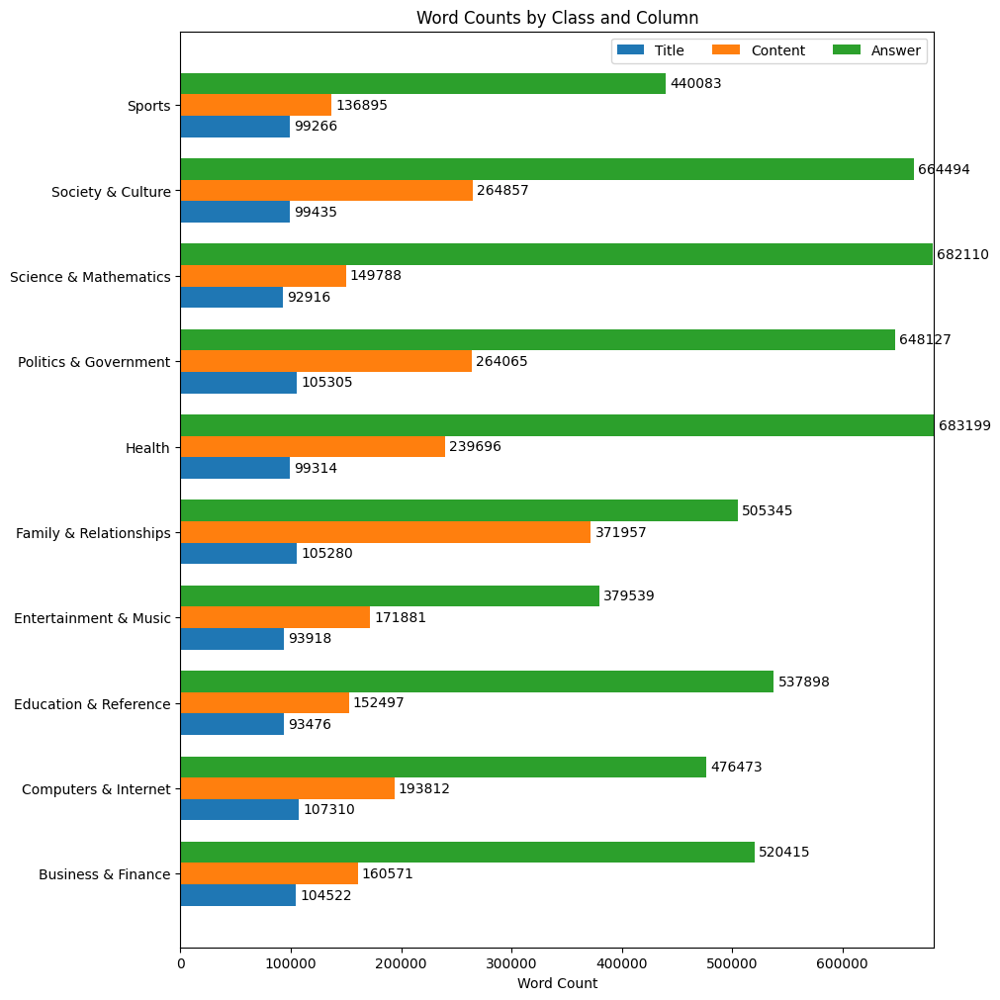

In [30]:
classes = word_counts_by_class_train.index
y = np.arange(len(classes))  # label locations
height = 0.25  # height of the bars
multiplier = 0

# Create the plot for word counts
fig, ax = plt.subplots(figsize=(10, 10), layout='constrained')

for attribute, measurement in zip(['word_title', 'word_content', 'word_answer'],
                                  [word_counts_by_class_train['word_title'], word_counts_by_class_train['word_content'], word_counts_by_class_train['word_answer']]):
    offset = height * multiplier
    rects = ax.barh(y + offset, measurement, height, label=attribute.replace('word_', '').capitalize())
    ax.bar_label(rects, padding=3, rotation=0)  # Keep the numbers horizontal
    multiplier += 1

# Add labels, title, custom y-axis tick labels, etc., for word counts
ax.set_xlabel('Word Count')
ax.set_title('Word Counts by Class and Column')
ax.set_yticks(y + height, classes)
ax.legend(loc='upper right', ncols=3)
ax.set_xlim(0, word_counts_by_class_train.max().max() + 50)

# Show the plot
plt.show()

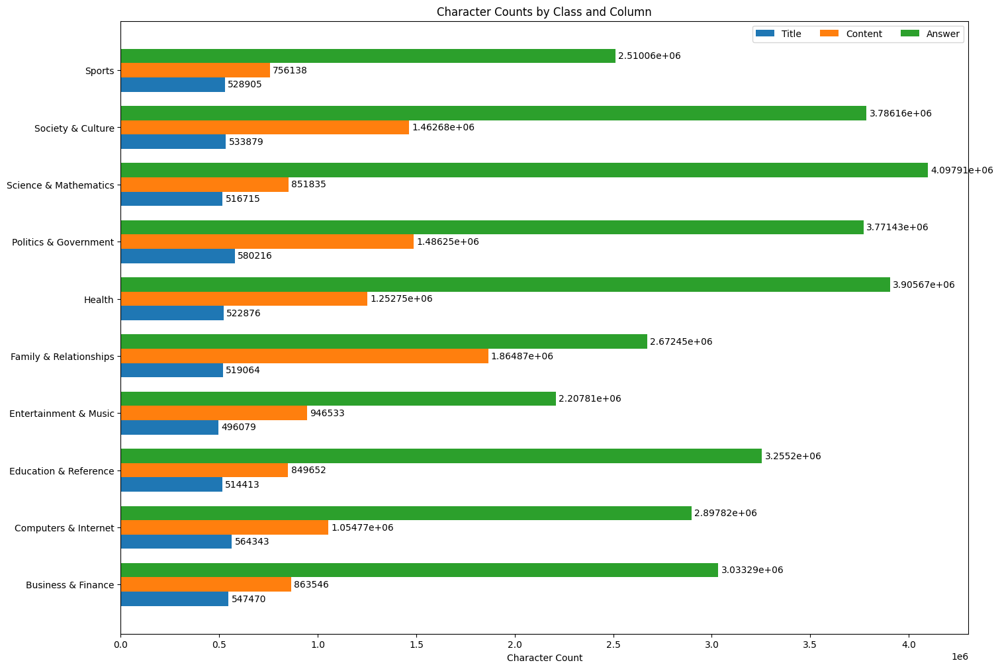

In [31]:
classes = char_counts_by_class_train.index
y = np.arange(len(classes))  # label locations
height = 0.25  # height of the bars
multiplier = 0

# Create the plot for character counts
fig, ax = plt.subplots(figsize=(15, 10), layout='constrained')

for attribute, measurement in zip(['char_title', 'char_content', 'char_answer'],
                                  [char_counts_by_class_train['char_title'], char_counts_by_class_train['char_content'], char_counts_by_class_train['char_answer']]):
    offset = height * multiplier
    rects = ax.barh(y + offset, measurement, height, label=attribute.replace('char_', '').capitalize())
    ax.bar_label(rects, padding=3, rotation=0)  # Keep the numbers horizontal
    multiplier += 1

# Add labels, title, custom y-axis tick labels, etc., for character counts
ax.set_xlabel('Character Count')
ax.set_title('Character Counts by Class and Column')
ax.set_yticks(y + height, classes)
ax.legend(loc='upper right', ncols=3)
# ax.set_xlim(0, char_counts_by_class.max().max() + 50000)

# Show the plot
plt.show()

In [32]:
empty_summary_train

,empty_title,empty_content,empty_answer
Class,,,
Business & Finance,0,0,0
Computers & Internet,0,0,0
Education & Reference,0,0,0
Entertainment & Music,0,0,0
Family & Relationships,0,0,0
Health,0,0,0
Politics & Government,0,0,0
Science & Mathematics,0,0,0
Society & Culture,0,0,0


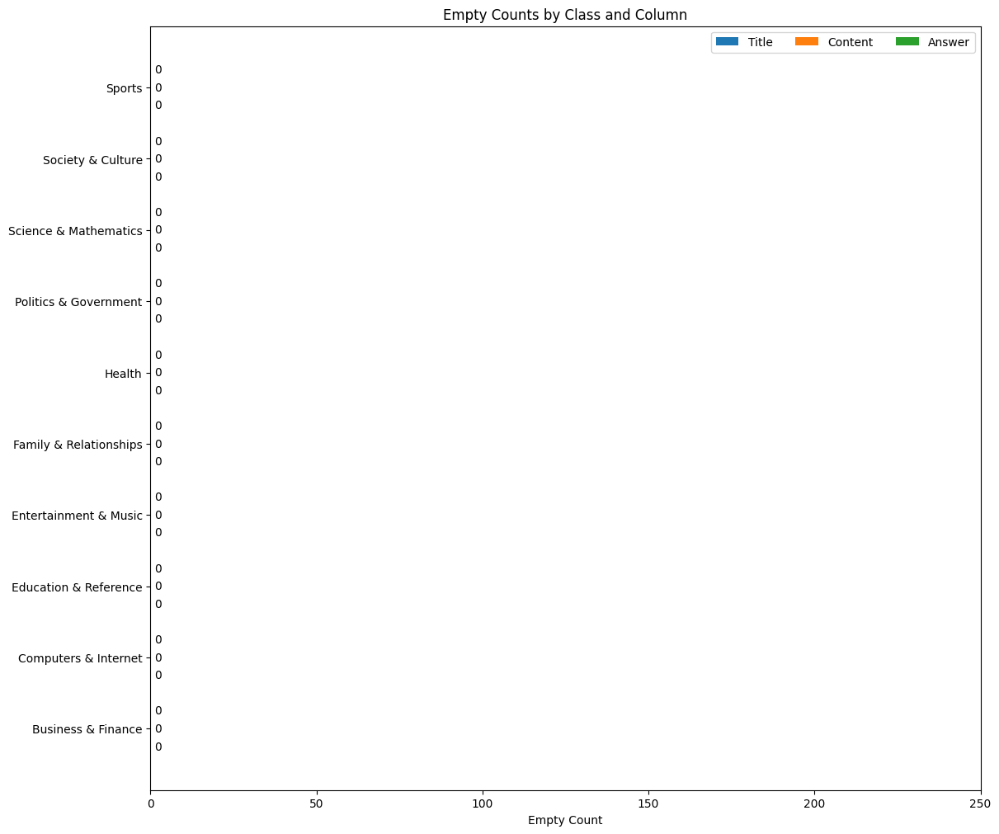

In [33]:
classes = empty_summary_train.index
y = np.arange(len(classes))  # label locations
height = 0.25  # height of the bars
multiplier = 0

# Create the plot for word counts
fig, ax = plt.subplots(figsize=(12, 10), layout='constrained')

for attribute, measurement in zip(['empty_title', 'empty_content', 'empty_answer'],
                                  [empty_summary_train['empty_title'], empty_summary_train['empty_content'], empty_summary_train['empty_answer']]):
    offset = height * multiplier
    rects = ax.barh(y + offset, measurement, height, label=attribute.replace('empty_', '').capitalize())
    ax.bar_label(rects, padding=3, rotation=0)  # Keep the numbers horizontal
    multiplier += 1

# Add labels, title, custom y-axis tick labels, etc., for word counts
ax.set_xlabel('Empty Count')
ax.set_title('Empty Counts by Class and Column')
ax.set_yticks(y + height, classes)
ax.legend(loc='upper right', ncols=3)
ax.set_xlim(0, empty_summary_train.max().max()+250)

# Show the plot
plt.show()

In [34]:
empty_summary_after_feature_engineering = empty_summary_by_class(train_df)
empty_summary_after_feature_engineering

,empty_title,empty_content,empty_answer
Class,,,
Business & Finance,0,0,0
Computers & Internet,0,0,0
Education & Reference,0,0,0
Entertainment & Music,0,0,0
Family & Relationships,0,0,0
Health,0,0,0
Politics & Government,0,0,0
Science & Mathematics,0,0,0
Society & Culture,0,0,0


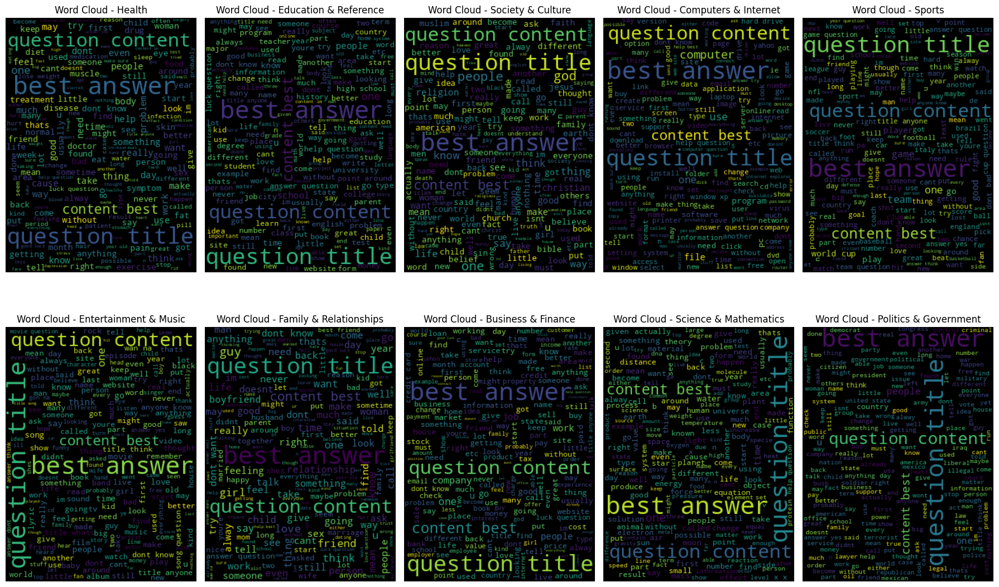

In [35]:
# Generate word clouds for different classes
classes = train_df['Class'].unique()

fig, axes = plt.subplots(2, len(classes)//2, figsize=(18, 12))
axes = axes.ravel()

for i, class_name in enumerate(classes):
    class_text = ' '.join(train_df[train_df['Class'] == class_name]['cleaned_text_No_HTML'].astype(str)) #train_df['cleaned_text_No_HTML'] cleaned_text_feature_engineered
    wordcloud = WordCloud(width=300, height=400, background_color='black').generate(class_text)

    axes[i].imshow(wordcloud.to_image(), interpolation='bilinear')
    axes[i].set_title(f'Word Cloud - {class_name}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

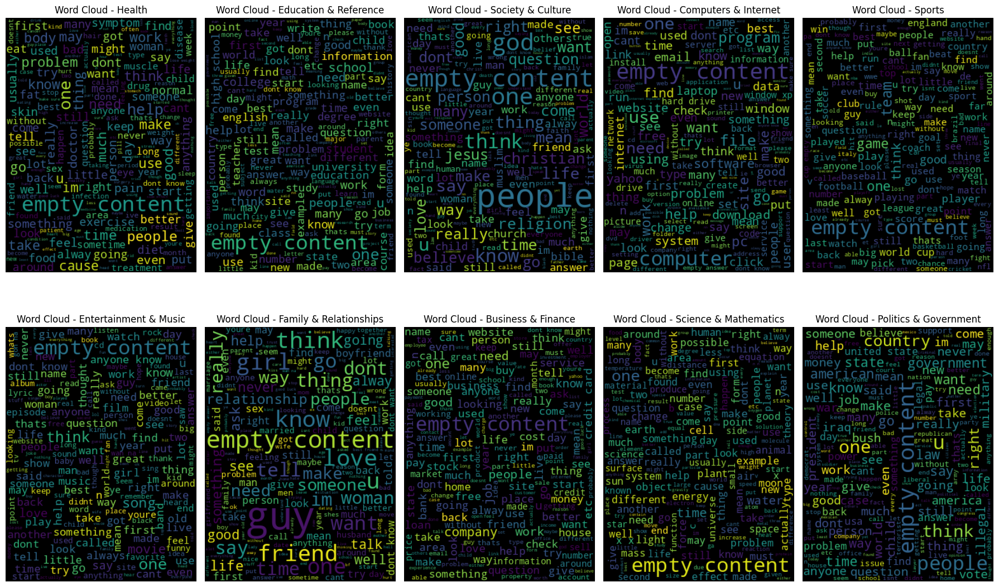

In [36]:
# Generate word clouds for different classes
classes = train_df['Class'].unique()

fig, axes = plt.subplots(2, len(classes)//2, figsize=(18, 12))
axes = axes.ravel()

for i, class_name in enumerate(classes):
    class_text = ' '.join(train_df[train_df['Class'] == class_name]['cleaned_text_feature_engineered'].astype(str)) #train_df['cleaned_text_No_HTML'] cleaned_text_feature_engineered
    wordcloud = WordCloud(width=300, height=400, background_color='black').generate(class_text)

    axes[i].imshow(wordcloud.to_image(), interpolation='bilinear')
    axes[i].set_title(f'Word Cloud - {class_name}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Extra (Dont Run)

In [37]:
# # 1. Filter the DataFrame to get only the rows with the flag
# original_entries = train_df[train_df['has_html_2'] == True]['QA Text']
# problematic_entries = train_df[train_df['has_html_2'] == True]['No HTML']

# # 2. Print the entries with a separator for readability
# print(f"Found {len(problematic_entries)} entries containing '>':\n")

# for index, text in problematic_entries.items():
#     print(f"--- Row Index: {index} ---")
#     print(text)
#     print("-" * 50)

In [38]:
# for index, text in original_entries.items():
#     print(f"--- Row Index: {index} ---")
#     # Replace actual newlines with the literal string '\n'
#     print(text.replace('\n', '\\n'))
#     print("-" * 50)

# 7. Train / Validation Split (from training CSV)

In [39]:
# Create a list of the columns you want
selected_columns = [
    'cleaned_text_No_HTML',
    'cleaned_text_feature_engineered',
    'Class'
]

# Copy them into a new DataFrame X
train_selected = train_df[selected_columns].copy()
test_selected = test_df[selected_columns].copy()

In [40]:
"""
DATA STRUCTURE DICTIONARY: data_standard / data_fe
--------------------------------------------------
Each dictionary contains 11 key-value pairs representing the
complete pipeline for a specific text feature:

{
    'X_train'      : ndarray  -> The raw text features (Strings) for the training set.
    'X_val'        : ndarray  -> The raw text features (Strings) for the validation set.
    'X_test'       : ndarray  -> The raw text features (Strings) for the test set.

    'y_train_enc'  : ndarray  -> Target labels for training as integers (0 to N-1).
    'y_val_enc'    : ndarray  -> Target labels for validation as integers (0 to N-1).
    'y_test_enc'   : ndarray  -> Target labels for testing as integers (0 to N-1).

    'y_train_oh'   : ndarray  -> One-Hot encoded training labels (Matrix of 0s and 1s).
                                 Shape: (n_train, num_classes)
    'y_val_oh'     : ndarray  -> One-Hot encoded validation labels (Matrix of 0s and 1s).
                                 Shape: (n_val, num_classes)
    'y_test_oh'    : ndarray  -> One-Hot encoded test labels (Matrix of 0s and 1s).
                                 Shape: (n_test, num_classes)

    'classes'      : list     -> The original string class names, indexed by
                                 their encoded integer value.
    'num_classes'  : int      -> The total count of unique classes in the dataset.
}
"""


def prepare_training_data(train_df, feature_col, test_df):
    """
    Splits data, encodes labels, and generates one-hot vectors for a given feature.
    """
    # 1. Extract values
    # train
    X_data = train_df[feature_col].values
    y_data = train_df['Class'].values

    # test
    X_test  = test_df[feature_col].values
    y_test_data  = test_df['Class'].values

    # 2. Train/Validation Split
    X_train, X_val, y_train, y_val = train_test_split(
        X_data, y_data,
        test_size=0.2,
        random_state=42,
        stratify=y_data
    )

    # 3. Label Encoding
    le = LabelEncoder()

    # train
    y_train_enc = le.fit_transform(y_train)
    y_val_enc = le.transform(y_val)

    # test
    y_test_enc = le.transform(y_test_data)

    classes = list(le.classes_)
    num_classes = len(classes)

    # 4. One-Hot Encoding

    # train
    y_train_oh = to_categorical(y_train_enc, num_classes=num_classes)
    y_val_oh = to_categorical(y_val_enc, num_classes=num_classes)

    # test
    y_test_oh = to_categorical(y_test_enc, num_classes=num_classes)

    # Return a structured dictionary for easy access
    return {
        "X_train": X_train,
        "X_val": X_val,
        "y_train_enc": y_train_enc,
        "y_val_enc": y_val_enc,
        "y_train_oh": y_train_oh,
        "y_val_oh": y_val_oh,
        "X_test": X_test,
        "y_test_enc": y_test_enc,
        "y_test_oh": y_test_oh,
        "classes": classes,
        "num_classes": num_classes
    }

In [41]:
# Prepare standard cleaned data
data_std = prepare_training_data(train_selected, 'cleaned_text_No_HTML', test_selected)

# Prepare feature engineered data
data_eng = prepare_training_data(train_selected, 'cleaned_text_feature_engineered', test_selected)

# Example: How to access the values
print(f"Standard Classes: {data_std['num_classes']}")
print(f"FE Train Shape: {data_eng['X_train'].shape}")

Standard Classes: 10
FE Train Shape: (74666,)


# 8. Evaluate Functions

In [42]:
def evaluate_model(y_true, y_pred, class_names, title):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')

    print(f"{title}")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1-macro : {f1_macro:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names,
                yticklabels=class_names,
                cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return acc, f1_macro

In [43]:
def test_performance_ml(data, vectorizer, model, data_name="data"):
    # --- STEP 1: Prepare Test Data ---
    # Extract raw text and labels from your dictionary
    raw_X_test = data['X_test']
    y_test     = data['y_test_enc']

    # --- STEP 2: Vectorize Test Data ---
    # CRITICAL: Use the ALREADY FITTED vectorizer (e.g., 'tfidf' or 'vectorizer')
    # Use .transform(), NOT .fit_transform() to avoid data leakage.
    # Replace 'tfidf' below with whatever variable name you gave your vectorizer.
    X_test_tfidf = vectorizer.transform(raw_X_test)

    # --- STEP 3: Predict & Evaluate ---
    # Generate predictions using your trained model
    test_pred = model.predict(X_test_tfidf)

    # Run your evaluation function
    evaluate_model(
        y_test,
        test_pred,
        class_names=data['classes'],
        title=f"{model} + {vectorizer} ({data_name})- TEST SET PERFORMANCE"
    )

In [44]:
def test_performance_dnn(data, vectorizer, dnn, X_test_dense, data_name="data"):
    X_test_tfidf = vectorizer.transform(data['X_test'])

    # 1. Convert Sparse TF-IDF to Dense (if not already done)
    
    # 2. Get Model Predictions (Probabilities)
    test_probs = dnn.predict(X_test_dense)

    # 3. Convert Predictions to Integers (e.g., [0, 2, 1...])
    test_pred = test_probs.argmax(axis=1)

    # 4. Convert True One-Hot Labels to Integers
    # We take the column index of the '1' in each row
    y_test_true_from_oh = data['y_test_oh'].argmax(axis=1)

    # 5. Evaluate
    evaluate_model(
        y_test_true_from_oh,          # Passed the converted One-Hot labels
        test_pred,
        class_names=data['classes'],
        title=f"{vectorizer} + {dnn} (Test {data_name} - From One-Hot)"
    )

# 9. TF-IDF Models

Every Model will run 4 times

| Data Type | Encoding Type | X_train | y_train | X_val | y_val | X_test | y_test |
|-----------|---------------|---------|---------|-------|-------|--------|-------|
| **Standard Data**    | Label Encoding  | data_std['X_train']      | data_std['y_train_enc']     | data_std['X_val']      | data_std['y_val_enc']    | data_std['X_test']   | data_std['y_test_enc'] |
| **Standard Data**    | One Hot         | data_std['X_train']      | data_std['y_train_oh']      | data_std['X_val']      | data_std['y_val_oh']     | data_std['X_test']   | data_std['y_test_oh'] |
| **Feature Engineered** | Label Encoding | data_eng['X_train']      | data_eng['y_train_enc']     | data_eng['X_val']      | data_eng['y_val_enc']    | data_eng['X_test']   | data_eng['y_test_enc'] |
| **Feature Engineered** | One Hot        | data_eng['X_train']      | data_eng['y_train_oh']      | data_eng['X_val']      | data_eng['y_val_oh']     | data_eng['X_test']   | data_eng['y_test_oh'] |


## 9.1 TF-IDF

In [45]:
def tfidf_vectorizer_func(data):

    # TF-IDF configuration

    tfidf_vectorizer = TfidfVectorizer(
        max_features=30000,      # 🔴 CRITICAL: cap feature size
        min_df=5,                # ignore rare words
        max_df=0.9,              # ignore overly common words
        ngram_range=(1, 2),      # uni + bi-grams (optional)
        stop_words='english',
        dtype=np.float32         # avoid float64 memory blow-up
    )

    # standard
    X_train_tfidf = tfidf_vectorizer.fit_transform(data['X_train'])
    X_val_tfidf   = tfidf_vectorizer.transform(data['X_val'])
    X_test_tfidf  = tfidf_vectorizer.transform(data['X_test'])

    print("TF-IDF shapes:")
    print("Train:", X_train_tfidf.shape)
    print("Val  :", X_val_tfidf.shape)
    print("Test :", X_test_tfidf.shape)

    return tfidf_vectorizer, X_train_tfidf, X_val_tfidf, X_test_tfidf


## 9.2 TF-IDF + Logistic Regression

In [46]:
def logistic_regression(data, X_train_tfidf, X_val_tfidf):
    # 1. Initialize Logistic Regression
    lr_model = LogisticRegression(
        random_state=42,
        max_iter=1000,   # Increased to handle high-dimensional TF-IDF data
    )

    # 2. LABEL ENCODED TARGETS
    y_train = data['y_train_enc']
    y_val   = data['y_val_enc']

    # 3. Fit the model
    lr_model.fit(X_train_tfidf, y_train)

    # 4. Predict
    val_pred = lr_model.predict(X_val_tfidf)

    # 5. Evaluate
    evaluate_model(
        y_val,
        val_pred,
        class_names=data_std['classes'],
        title="Logistic Regression + TF-IDF (Standard Data)"
    )

    return lr_model

In [47]:
def logictic_regression_hyperparameter(data, X_train_tfidf, X_val_tfidf):

    # 1. Initialize Logistic Regression
    lr_model_l2 = LogisticRegression(
        penalty='l2',        # <--- Explicitly set L2
        C=0.25,               # Control strength (smaller = stronger regularization)
        random_state=42,
        max_iter=1000,
    )

    # 2. LABEL ENCODED TARGETS
    y_train = data['y_train_enc']
    y_val   = data['y_val_enc']

    # 3. Fit the model
    lr_model_l2.fit(X_train_tfidf, y_train)

    # 4. Predict
    val_pred = lr_model_l2.predict(X_val_tfidf)

    # 5. Evaluate
    evaluate_model(
        y_val,
        val_pred,
        class_names=data_std['classes'],
        title="Logistic Regression L2 + TF-IDF (Standard Data)"
    )

    return lr_model_l2

## 9.3 TF-IDF + DNN

In [48]:
def dnn(data, X_train_tfidf, X_val_tfidf, X_test_tfidf):
    svd = TruncatedSVD(
        n_components=500,   # 300–500 is ideal
        random_state=42
    )
    
    X_train_dense = svd.fit_transform(X_train_tfidf).astype('float32')
    X_val_dense   = svd.transform(X_val_tfidf).astype('float32')
    X_test_dense  = svd.transform(X_test_tfidf).astype('float32')

    def build_dnn(input_dim, num_classes, learning_rate=0.001): # Add parameter
        model = models.Sequential([
            layers.Input(shape=(input_dim,), name="input_layer"), 
            layers.Dense(256, activation='relu'),
            layers.Dropout(0.25),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(num_classes, activation='softmax')
        ])

        model.compile(
            # Pass the object with custom LR, not the string 'adam'
            optimizer=Adam(learning_rate=learning_rate),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        return model

    dnn = build_dnn(
        input_dim=X_train_dense.shape[1],
        num_classes=data['num_classes']
    )

    # Define the early stopping criteria
    early_stop = EarlyStopping(
        monitor='val_loss',      # Watch the validation loss
        patience=5,              # How many epochs to wait for improvement before stopping
        restore_best_weights=True # Keep the weights from the best epoch, not the last one
    )

    history = dnn.fit(
        X_train_dense,
        data['y_train_oh'],
        validation_data=(X_val_dense, data['y_val_oh']),
        epochs=150,
        batch_size=32,
        callbacks=[early_stop],
        verbose=1
    )

    return dnn, history, X_test_dense

In [49]:
def dnn_hyperparameter(data, X_train_tfidf, X_val_tfidf, X_test_tfidf):
    svd = TruncatedSVD(
        n_components=500,   # 300–500 is ideal
        random_state=42
    )
    
    X_train_dense = svd.fit_transform(X_train_tfidf).astype('float32')
    X_val_dense   = svd.transform(X_val_tfidf).astype('float32')
    X_test_dense  = svd.transform(X_test_tfidf).astype('float32')

    def build_dnn(input_dim, num_classes, learning_rate=0.001):
        model = models.Sequential([
            layers.Input(shape=(input_dim,), name="input_layer"), 

            layers.Dense(128, activation='relu'),
            layers.Dropout(0.25),
    
            layers.Dense(64, activation='relu'),
            layers.Dropout(0.5),
    
            layers.Dense(32, activation='tanh'),
            layers.Dropout(0.3),
    
            layers.Dense(num_classes, activation='softmax')
        ])

        model.compile(
            optimizer=Adam(learning_rate=learning_rate),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        return model

    dnn_hyper = build_dnn(
        input_dim=X_train_dense.shape[1],
        num_classes=data['num_classes']
    )

    # Define the early stopping criteria
    early_stop = EarlyStopping(
        monitor='val_loss',      # Watch the validation loss
        patience=5,              # How many epochs to wait for improvement before stopping
        restore_best_weights=True # Keep the weights from the best epoch, not the last one
    )

    history = dnn_hyper.fit(
        X_train_dense,
        data['y_train_oh'],
        validation_data=(X_val_dense, data['y_val_oh']),
        epochs=150,
        batch_size=32,
        callbacks=[early_stop]
    )

    return dnn_hyper, history, X_test_dense

## 9.4 TF-IDF Execution

### Standard Data

In [50]:
tfidf_vectorizer_std, X_train_tfidf_std, X_val_tfidf_std, X_test_tfidf_std = tfidf_vectorizer_func(data_std)

TF-IDF shapes:
Train: (74666, 30000)
Val  : (18667, 30000)
Test : (59999, 30000)


Logistic Regression + TF-IDF (Standard Data)
Accuracy : 0.6892
F1-macro : 0.6875

Classification Report:
                        precision    recall  f1-score   support

    Business & Finance       0.56      0.51      0.53      1861
  Computers & Internet       0.80      0.85      0.82      1874
 Education & Reference       0.52      0.50      0.51      1844
 Entertainment & Music       0.65      0.68      0.66      1891
Family & Relationships       0.70      0.75      0.72      1878
                Health       0.74      0.76      0.75      1869
 Politics & Government       0.76      0.73      0.75      1847
 Science & Mathematics       0.68      0.73      0.70      1851
     Society & Culture       0.60      0.58      0.59      1882
                Sports       0.86      0.82      0.84      1870

              accuracy                           0.69     18667
             macro avg       0.69      0.69      0.69     18667
          weighted avg       0.69      0.69      0.69     186

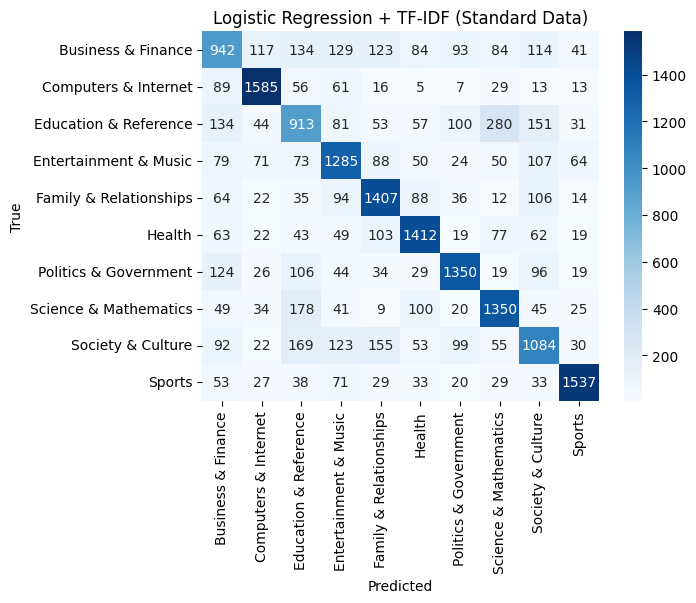

Logistic Regression L2 + TF-IDF (Standard Data)
Accuracy : 0.6784
F1-macro : 0.6761

Classification Report:
                        precision    recall  f1-score   support

    Business & Finance       0.57      0.50      0.53      1861
  Computers & Internet       0.79      0.84      0.81      1874
 Education & Reference       0.52      0.48      0.50      1844
 Entertainment & Music       0.63      0.67      0.65      1891
Family & Relationships       0.68      0.75      0.71      1878
                Health       0.72      0.74      0.73      1869
 Politics & Government       0.75      0.73      0.74      1847
 Science & Mathematics       0.65      0.74      0.69      1851
     Society & Culture       0.60      0.55      0.58      1882
                Sports       0.84      0.79      0.82      1870

              accuracy                           0.68     18667
             macro avg       0.68      0.68      0.68     18667
          weighted avg       0.68      0.68      0.68     

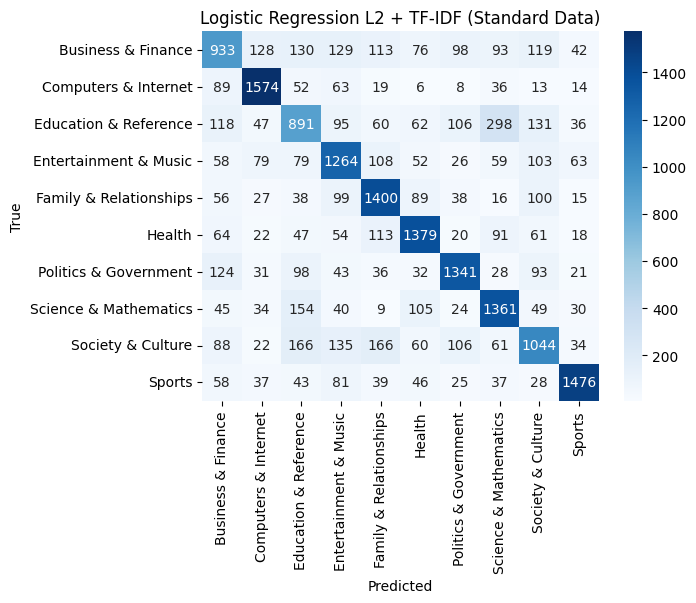

In [51]:
lr_model_std = logistic_regression(data_std, X_train_tfidf_std, X_val_tfidf_std)
lr_model_hyper_std = logictic_regression_hyperparameter(data_std, X_train_tfidf_std, X_val_tfidf_std)

In [52]:
dnn_std, dnn_history_std, X_test_dense_std = dnn(data_std, X_train_tfidf_std, X_val_tfidf_std, X_test_tfidf_std)
dnn_std_hyper, dnn_hyper_history_std, X_test_dense_hyper_std = dnn_hyperparameter(data_std, X_train_tfidf_std, X_val_tfidf_std, X_test_tfidf_std)

Epoch 1/150
2334/2334 [==============================] - 6s 2ms/step - loss: 1.2956 - accuracy: 0.5931 - val_loss: 1.0944 - val_accuracy: 0.6540
Epoch 2/150
2334/2334 [==============================] - 5s 2ms/step - loss: 1.1160 - accuracy: 0.6500 - val_loss: 1.0774 - val_accuracy: 0.6595
Epoch 3/150
2334/2334 [==============================] - 5s 2ms/step - loss: 1.0783 - accuracy: 0.6577 - val_loss: 1.0585 - val_accuracy: 0.6645
Epoch 4/150
2334/2334 [==============================] - 5s 2ms/step - loss: 1.0438 - accuracy: 0.6682 - val_loss: 1.0571 - val_accuracy: 0.6644
Epoch 5/150
2334/2334 [==============================] - 5s 2ms/step - loss: 1.0127 - accuracy: 0.6759 - val_loss: 1.0490 - val_accuracy: 0.6655
Epoch 6/150
2334/2334 [==============================] - 5s 2ms/step - loss: 0.9829 - accuracy: 0.6833 - val_loss: 1.0534 - val_accuracy: 0.6667
Epoch 7/150
2334/2334 [==============================] - 5s 2ms/step - loss: 0.9536 - accuracy: 0.6908 - val_loss: 1.0552 - val_ac

LogisticRegression(max_iter=1000, random_state=42) + TfidfVectorizer(dtype=<class 'numpy.float32'>, max_df=0.9, max_features=30000,
                min_df=5, ngram_range=(1, 2), stop_words='english') (Standard Data)- TEST SET PERFORMANCE
Accuracy : 0.6834
F1-macro : 0.6817

Classification Report:
                        precision    recall  f1-score   support

    Business & Finance       0.55      0.50      0.52      6000
  Computers & Internet       0.81      0.84      0.82      6000
 Education & Reference       0.52      0.49      0.51      6000
 Entertainment & Music       0.65      0.67      0.66      6000
Family & Relationships       0.68      0.74      0.71      5999
                Health       0.74      0.77      0.75      6000
 Politics & Government       0.75      0.72      0.74      6000
 Science & Mathematics       0.68      0.72      0.70      6000
     Society & Culture       0.58      0.55      0.57      6000
                Sports       0.85      0.82      0.84      60

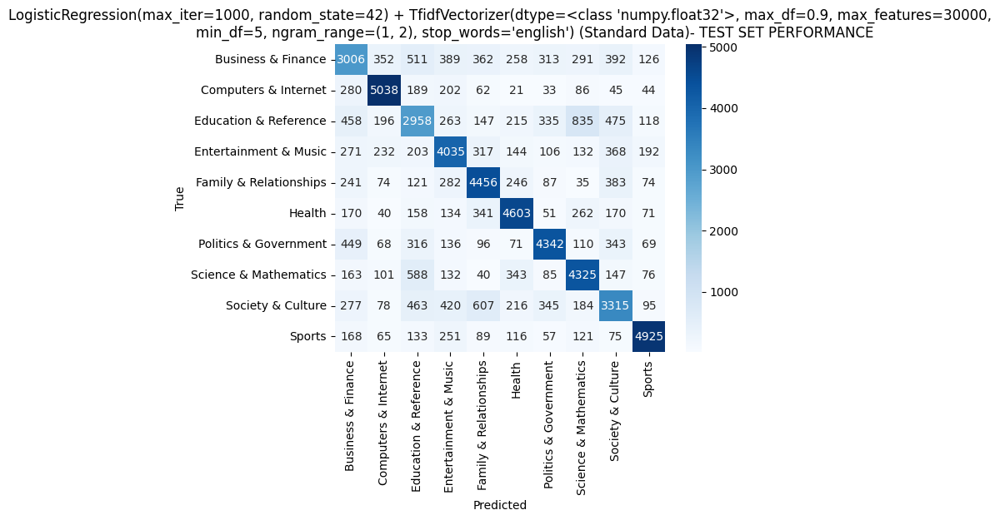

LogisticRegression(C=0.25, max_iter=1000, random_state=42) + TfidfVectorizer(dtype=<class 'numpy.float32'>, max_df=0.9, max_features=30000,
                min_df=5, ngram_range=(1, 2), stop_words='english') (Standard Data)- TEST SET PERFORMANCE
Accuracy : 0.6751
F1-macro : 0.6725

Classification Report:
                        precision    recall  f1-score   support

    Business & Finance       0.56      0.50      0.53      6000
  Computers & Internet       0.78      0.83      0.81      6000
 Education & Reference       0.54      0.48      0.51      6000
 Entertainment & Music       0.63      0.65      0.64      6000
Family & Relationships       0.67      0.75      0.71      5999
                Health       0.72      0.76      0.74      6000
 Politics & Government       0.74      0.71      0.73      6000
 Science & Mathematics       0.65      0.73      0.69      6000
     Society & Culture       0.59      0.54      0.56      6000
                Sports       0.83      0.80      0.82

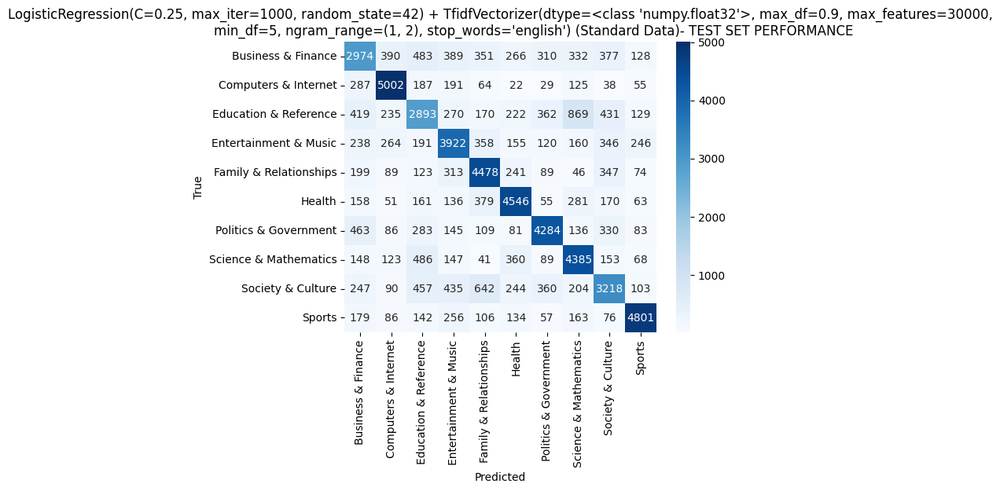

In [53]:
test_performance_ml(data_std, tfidf_vectorizer_std, lr_model_std, "Standard Data")
test_performance_ml(data_std, tfidf_vectorizer_std, lr_model_hyper_std, "Standard Data")

1875/1875 [==============================] - 1s 700us/step
TfidfVectorizer(dtype=<class 'numpy.float32'>, max_df=0.9, max_features=30000,
                min_df=5, ngram_range=(1, 2), stop_words='english') + <keras.engine.sequential.Sequential object at 0x0000027DE168AA90> (Test Standard Data - From One-Hot)
Accuracy : 0.6593
F1-macro : 0.6527

Classification Report:
                        precision    recall  f1-score   support

    Business & Finance       0.59      0.44      0.50      6000
  Computers & Internet       0.77      0.84      0.80      6000
 Education & Reference       0.55      0.41      0.47      6000
 Entertainment & Music       0.61      0.61      0.61      6000
Family & Relationships       0.64      0.74      0.69      5999
                Health       0.72      0.75      0.73      6000
 Politics & Government       0.67      0.77      0.72      6000
 Science & Mathematics       0.67      0.70      0.68      6000
     Society & Culture       0.55      0.54      0.54

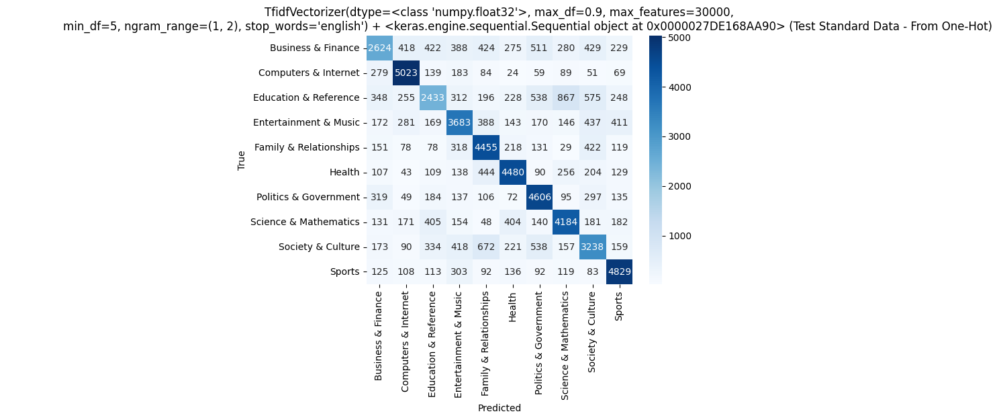

1875/1875 [==============================] - 1s 704us/step
TfidfVectorizer(dtype=<class 'numpy.float32'>, max_df=0.9, max_features=30000,
                min_df=5, ngram_range=(1, 2), stop_words='english') + <keras.engine.sequential.Sequential object at 0x0000027DE6A919A0> (Test Standard Data - From One-Hot)
Accuracy : 0.6549
F1-macro : 0.6496

Classification Report:
                        precision    recall  f1-score   support

    Business & Finance       0.56      0.45      0.50      6000
  Computers & Internet       0.79      0.82      0.80      6000
 Education & Reference       0.54      0.43      0.48      6000
 Entertainment & Music       0.61      0.61      0.61      6000
Family & Relationships       0.65      0.73      0.69      5999
                Health       0.70      0.74      0.72      6000
 Politics & Government       0.71      0.72      0.72      6000
 Science & Mathematics       0.62      0.73      0.67      6000
     Society & Culture       0.56      0.52      0.54

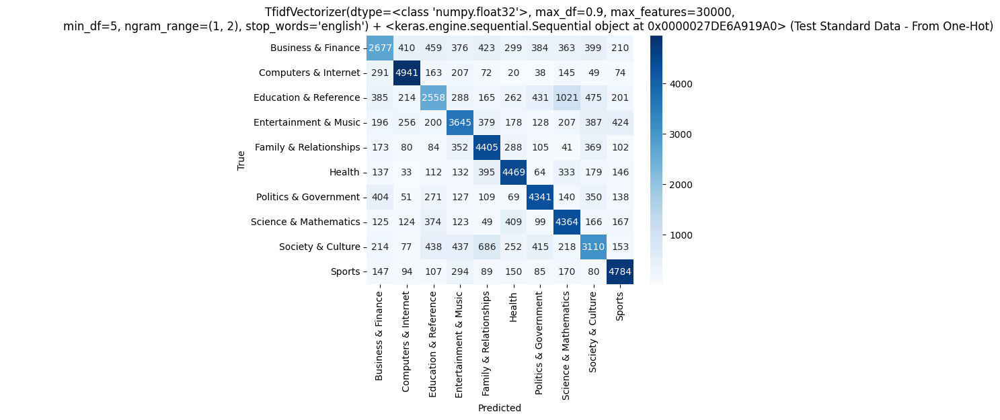

In [54]:
test_performance_dnn(data_std, tfidf_vectorizer_std, dnn_std, X_test_dense_std, "Standard Data")
test_performance_dnn(data_std, tfidf_vectorizer_std, dnn_std_hyper, X_test_dense_hyper_std, "Standard Data")

### Feature Engineered Data

In [55]:
tfidf_vectorizer_eng, X_train_tfidf_eng, X_val_tfidf_eng, X_test_tfidf_eng = tfidf_vectorizer_func(data_eng)

TF-IDF shapes:
Train: (74666, 30000)
Val  : (18667, 30000)
Test : (59999, 30000)


Logistic Regression + TF-IDF (Standard Data)
Accuracy : 0.6883
F1-macro : 0.6863

Classification Report:
                        precision    recall  f1-score   support

    Business & Finance       0.57      0.51      0.54      1861
  Computers & Internet       0.81      0.85      0.83      1874
 Education & Reference       0.52      0.49      0.51      1844
 Entertainment & Music       0.65      0.67      0.66      1891
Family & Relationships       0.69      0.75      0.72      1878
                Health       0.74      0.76      0.75      1869
 Politics & Government       0.75      0.73      0.74      1847
 Science & Mathematics       0.67      0.73      0.70      1851
     Society & Culture       0.59      0.58      0.58      1882
                Sports       0.85      0.82      0.84      1870

              accuracy                           0.69     18667
             macro avg       0.69      0.69      0.69     18667
          weighted avg       0.69      0.69      0.69     186

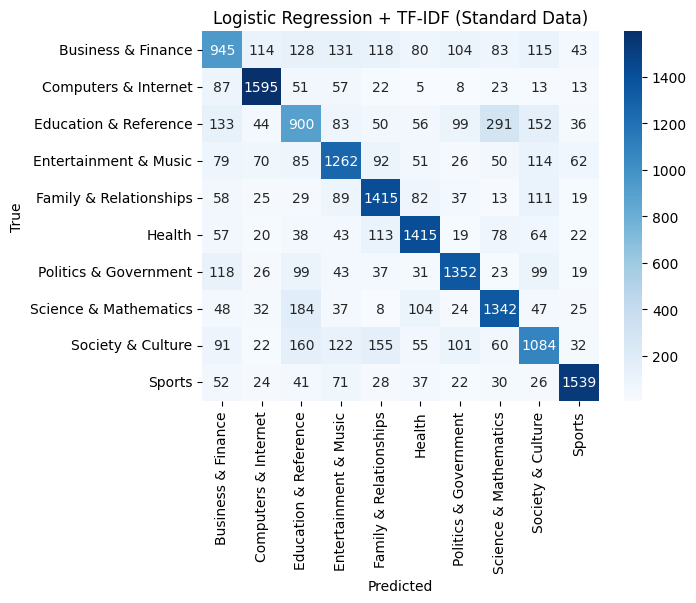

Logistic Regression L2 + TF-IDF (Standard Data)
Accuracy : 0.6793
F1-macro : 0.6769

Classification Report:
                        precision    recall  f1-score   support

    Business & Finance       0.57      0.50      0.53      1861
  Computers & Internet       0.78      0.84      0.81      1874
 Education & Reference       0.53      0.48      0.50      1844
 Entertainment & Music       0.64      0.66      0.65      1891
Family & Relationships       0.68      0.74      0.71      1878
                Health       0.72      0.74      0.73      1869
 Politics & Government       0.75      0.72      0.73      1847
 Science & Mathematics       0.66      0.74      0.69      1851
     Society & Culture       0.60      0.56      0.58      1882
                Sports       0.85      0.80      0.82      1870

              accuracy                           0.68     18667
             macro avg       0.68      0.68      0.68     18667
          weighted avg       0.68      0.68      0.68     

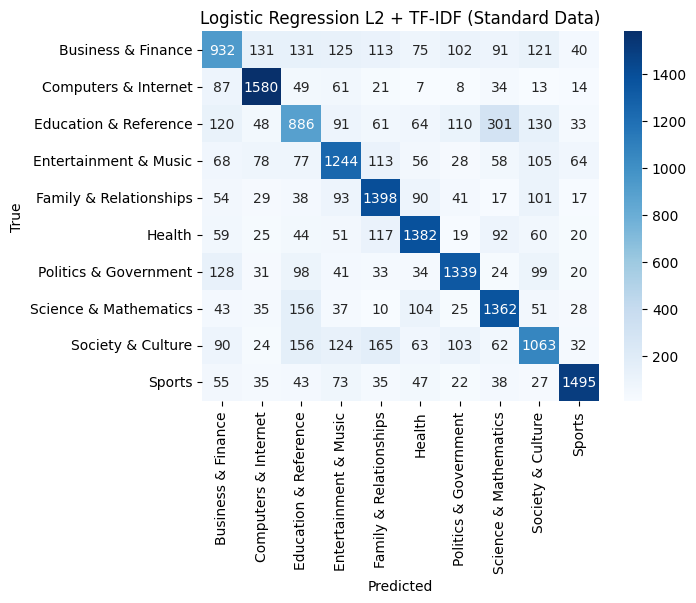

In [56]:
lr_model_eng = logistic_regression(data_eng, X_train_tfidf_eng, X_val_tfidf_eng)
lr_model_hyper_eng = logictic_regression_hyperparameter(data_eng, X_train_tfidf_eng, X_val_tfidf_eng)

In [57]:
dnn_eng, dnn_history_eng, X_test_dense_eng = dnn(data_eng, X_train_tfidf_eng, X_val_tfidf_eng, X_test_tfidf_eng)
dnn_eng_hyper, dnn_hyper_history_eng, X_test_dense_hyper_eng = dnn_hyperparameter(data_eng, X_train_tfidf_eng, X_val_tfidf_eng, X_test_tfidf_eng)

Epoch 1/150
2334/2334 [==============================] - 5s 2ms/step - loss: 1.3007 - accuracy: 0.5924 - val_loss: 1.0923 - val_accuracy: 0.6543
Epoch 2/150
2334/2334 [==============================] - 5s 2ms/step - loss: 1.1179 - accuracy: 0.6488 - val_loss: 1.0762 - val_accuracy: 0.6545
Epoch 3/150
2334/2334 [==============================] - 4s 2ms/step - loss: 1.0812 - accuracy: 0.6590 - val_loss: 1.0621 - val_accuracy: 0.6600
Epoch 4/150
2334/2334 [==============================] - 4s 2ms/step - loss: 1.0482 - accuracy: 0.6662 - val_loss: 1.0557 - val_accuracy: 0.6608
Epoch 5/150
2334/2334 [==============================] - 5s 2ms/step - loss: 1.0157 - accuracy: 0.6744 - val_loss: 1.0518 - val_accuracy: 0.6643
Epoch 6/150
2334/2334 [==============================] - 4s 2ms/step - loss: 0.9848 - accuracy: 0.6831 - val_loss: 1.0532 - val_accuracy: 0.6604
Epoch 7/150
2334/2334 [==============================] - 4s 2ms/step - loss: 0.9575 - accuracy: 0.6902 - val_loss: 1.0569 - val_ac

LogisticRegression(max_iter=1000, random_state=42) + TfidfVectorizer(dtype=<class 'numpy.float32'>, max_df=0.9, max_features=30000,
                min_df=5, ngram_range=(1, 2), stop_words='english') (Feature Engineered Data)- TEST SET PERFORMANCE
Accuracy : 0.6830
F1-macro : 0.6814

Classification Report:
                        precision    recall  f1-score   support

    Business & Finance       0.55      0.50      0.53      6000
  Computers & Internet       0.81      0.84      0.82      6000
 Education & Reference       0.53      0.49      0.51      6000
 Entertainment & Music       0.65      0.67      0.66      6000
Family & Relationships       0.68      0.74      0.71      5999
                Health       0.74      0.77      0.75      6000
 Politics & Government       0.75      0.72      0.74      6000
 Science & Mathematics       0.68      0.72      0.70      6000
     Society & Culture       0.57      0.55      0.56      6000
                Sports       0.85      0.82      0.

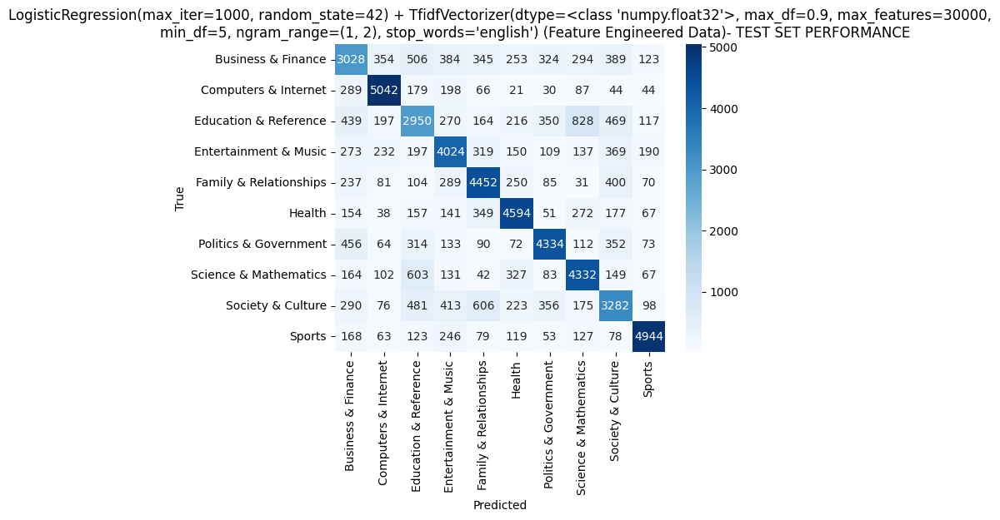

LogisticRegression(C=0.25, max_iter=1000, random_state=42) + TfidfVectorizer(dtype=<class 'numpy.float32'>, max_df=0.9, max_features=30000,
                min_df=5, ngram_range=(1, 2), stop_words='english') (Feature Engineered Data)- TEST SET PERFORMANCE
Accuracy : 0.6742
F1-macro : 0.6716

Classification Report:
                        precision    recall  f1-score   support

    Business & Finance       0.56      0.49      0.52      6000
  Computers & Internet       0.78      0.84      0.81      6000
 Education & Reference       0.53      0.48      0.50      6000
 Entertainment & Music       0.64      0.65      0.64      6000
Family & Relationships       0.67      0.74      0.70      5999
                Health       0.72      0.76      0.74      6000
 Politics & Government       0.74      0.71      0.73      6000
 Science & Mathematics       0.66      0.73      0.69      6000
     Society & Culture       0.58      0.54      0.56      6000
                Sports       0.84      0.80

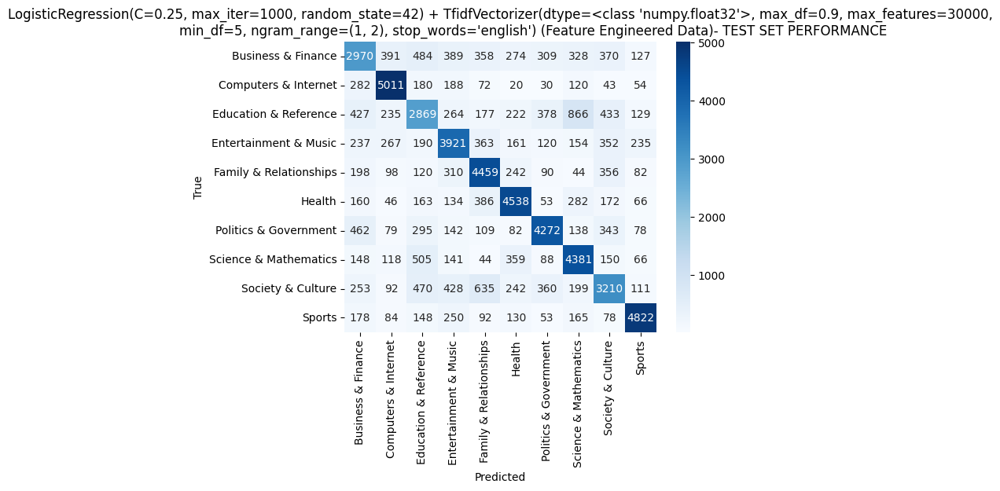

In [58]:
test_performance_ml(data_eng, tfidf_vectorizer_eng, lr_model_eng, "Feature Engineered Data")
test_performance_ml(data_eng, tfidf_vectorizer_eng, lr_model_hyper_eng, "Feature Engineered Data")

1875/1875 [==============================] - 2s 849us/step
TfidfVectorizer(dtype=<class 'numpy.float32'>, max_df=0.9, max_features=30000,
                min_df=5, ngram_range=(1, 2), stop_words='english') + <keras.engine.sequential.Sequential object at 0x0000027DE163B430> (Test Feature Engineered Data - From One-Hot)
Accuracy : 0.6577
F1-macro : 0.6526

Classification Report:
                        precision    recall  f1-score   support

    Business & Finance       0.59      0.44      0.50      6000
  Computers & Internet       0.77      0.83      0.80      6000
 Education & Reference       0.52      0.43      0.47      6000
 Entertainment & Music       0.61      0.62      0.61      6000
Family & Relationships       0.62      0.76      0.68      5999
                Health       0.73      0.74      0.73      6000
 Politics & Government       0.69      0.75      0.72      6000
 Science & Mathematics       0.66      0.70      0.68      6000
     Society & Culture       0.55      0.53

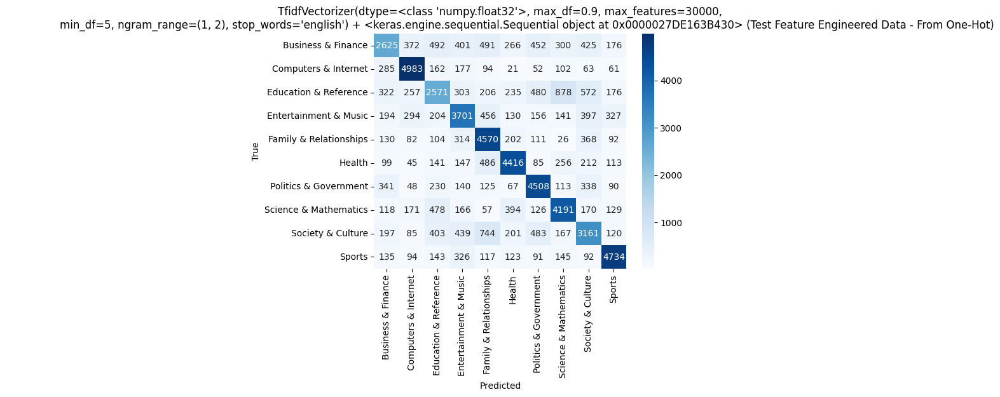

1875/1875 [==============================] - 1s 776us/step
TfidfVectorizer(dtype=<class 'numpy.float32'>, max_df=0.9, max_features=30000,
                min_df=5, ngram_range=(1, 2), stop_words='english') + <keras.engine.sequential.Sequential object at 0x0000027DB170F790> (Test Feature Engineered Data - From One-Hot)
Accuracy : 0.6571
F1-macro : 0.6524

Classification Report:
                        precision    recall  f1-score   support

    Business & Finance       0.59      0.43      0.50      6000
  Computers & Internet       0.78      0.83      0.81      6000
 Education & Reference       0.52      0.44      0.48      6000
 Entertainment & Music       0.60      0.63      0.61      6000
Family & Relationships       0.64      0.74      0.69      5999
                Health       0.70      0.75      0.72      6000
 Politics & Government       0.72      0.72      0.72      6000
 Science & Mathematics       0.64      0.71      0.68      6000
     Society & Culture       0.55      0.52

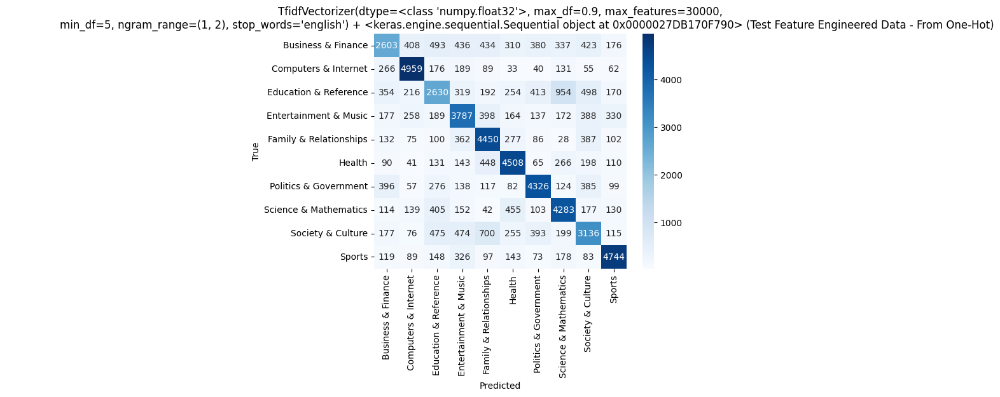

In [59]:
test_performance_dnn(data_eng, tfidf_vectorizer_eng, dnn_eng, X_test_dense_eng, "Feature Engineered Data")
test_performance_dnn(data_eng, tfidf_vectorizer_eng, dnn_eng_hyper, X_test_dense_hyper_eng, "Feature Engineered Data")

# 10. Unified Training Function

In [60]:
def apply_pad_sequencing(tokenizer, data):
    def prepare_sequences(tokenizer, texts):
        # Step A: Replace each word with its unique integer ID (e.g., "apple" -> 5)
        sequences = tokenizer.texts_to_sequences(texts)
    
        # Step B: Ensure all sequences have the same length so they can be fed into a neural network matrix
        # padding='post' puts zeros at the end; truncating='post' cuts off the end if the text is too long
        return pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
    
    # Process the training, validation, and test sets into uniform numerical arrays
    X_train_seq = prepare_sequences(tokenizer, data['X_train'])
    X_val_seq   = prepare_sequences(tokenizer, data['X_val'])
    X_test_seq  = prepare_sequences(tokenizer, data['X_test'])

    return X_train_seq, X_val_seq, X_test_seq

In [61]:
def run_nn_experiment(data, tokenizer, model, model_name):

    X_train_seq, X_val_seq, X_test_seq = apply_pad_sequencing(tokenizer, data)
    y_train_oh = data['y_train_oh']
    y_val_oh = data['y_val_oh']
    y_test_oh = data['y_test_oh']
    class_names = data['classes']
    
    """
    Compiles, fits, and evaluates a Keras model using the existing evaluate_model framework.
    """
    print(f"\n--- Training {model_name} ---")

    # 1. Compile
    model.compile(
        optimizer=Adam(learning_rate=0.001), # Standard LR
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Define the early stopping criteria
    early_stop = EarlyStopping(
        monitor='val_loss',      # Watch the validation loss
        patience=10,              # How many epochs to wait for improvement before stopping
        restore_best_weights=True # Keep the weights from the best epoch, not the last one
    )
    
    # 2. Fit (using the early_stop you defined in TF-IDF section)
    history = model.fit(
        X_train_seq, y_train_oh,
        validation_data=(X_val_seq, y_val_oh),
        epochs=1000,                  # High epoch count, relying on EarlyStopping
        batch_size=32,
        callbacks=[early_stop],      # Use your existing callback
        verbose=1
    )

    # 3. Predict on Test Data
    test_probs = model.predict(X_test_seq)
    test_pred = test_probs.argmax(axis=1) # Convert probs to class ID
    y_test_true = y_test_oh.argmax(axis=1) # Convert One-Hot to class ID

    # 4. Evaluate
    evaluate_model(
        y_test_true,
        test_pred,
        class_names=class_names,
        title=f"{model_name} (Test Set)"
    )

    return history

# 11. Skipgram Models

Skip‑gram (Required) + 7 NN models

## 11.1 Load GLOVE 6B 100d

In [62]:
# 1. Calculate Arithmetic Mean for MAX_SEQUENCE_LENGTH
# Count words in each training sample
def cal_max_seq_length(data):
    sentence_lengths = [len(str(text).split()) for text in data['X_train']]
    
    # Calculate the simple average (arithmetic mean)
    max_sequence_length = int(np.round(np.mean(sentence_lengths)))
    
    # Adjusted MAX_SEQUENCE_LENGTH for outliers as we saw from our outliers from box plots
    max_sequence_length = int(max_sequence_length + (max_sequence_length * 0.5))
    
    print(f"Adjusted Calculated Arithmetic Mean Sequence Length: {max_sequence_length}")

    return max_sequence_length

In [63]:
global GLOVE_PATH
global EMBEDDING_DIM
global MAX_SEQUENCE_LENGTH

GLOVE_PATH = "C:/Users/User/Documents/CSE440_Project/glove.6B.100d.txt"
EMBEDDING_DIM = 100
MAX_SEQUENCE_LENGTH_STD = cal_max_seq_length(data_std)
MAX_SEQUENCE_LENGTH_ENG = cal_max_seq_length(data_eng)

MAX_SEQUENCE_LENGTH = int((MAX_SEQUENCE_LENGTH_STD + MAX_SEQUENCE_LENGTH_ENG) / 2)
print("Average MAX_SEQUENCE_LENGTH:", MAX_SEQUENCE_LENGTH)

Adjusted Calculated Arithmetic Mean Sequence Length: 78
Adjusted Calculated Arithmetic Mean Sequence Length: 70
Average MAX_SEQUENCE_LENGTH: 74


## 11.2 Embedding matrix

In [64]:
def build_embedding_matrix(data):
    # 2. Tokenization (All words included)
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(data['X_train'])
    vocab_size = len(tokenizer.word_index) + 1  # +1 for padding index 0

    # 4. Build GloVe Embedding Matrix
    # Create an empty "lookup table" (matrix) of size [Vocabulary Size x Vector Dimensions]
    # This will eventually hold the pre-trained meaning (weights) for every word we know
    embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
    embeddings_index = {}

    # Step A: Load the massive GloVe text file into a Python dictionary for fast searching
    with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]                                     # The first item is the word string
            coefs = np.asarray(values[1:], dtype='float32')     # The rest are the 100-300 numerical coordinates
            embeddings_index[word] = coefs                       # Store: {'word': [0.12, -0.5, ...]}

    # Step B: Map the GloVe vectors to our specific tokenizer's word indices
    # This ensures that if 'apple' is index #5 in our data, its vector is at row #5 in our matrix
    for word, i in tokenizer.word_index.items():
        embedding_vector = embeddings_index.get(word)            # Try to find this word in the GloVe dictionary
        if embedding_vector is not None:
            # If found, place the pre-trained vector into the correct row of our final matrix
            embedding_matrix[i] = embedding_vector

    return embedding_matrix, vocab_size, tokenizer

## 11.3 GloVe + DNN

Base: Uses Global Average Pooling (simple bag-of-embeddings).

Hyperparameter: Uses Flattening and deeper dense layers.

In [65]:
def build_embedded_dnn(data, vocab_size, embedding_matrix):
    
    num_classes = data['num_classes']

    model = models.Sequential([
            # Embedding layer
            Embedding(input_dim=vocab_size,
              output_dim=EMBEDDING_DIM,
              weights=[embedding_matrix],
              mask_zero=True,  # Tells the model to skip the 0s entirely
              trainable=False),
    
            GlobalMaxPooling1D(),  # This layer WILL respect the mask and ignore 0s It turns (batch, seq, dim) into (batch, dim)
    
            Dense(256, activation='relu'),
            Dropout(0.15),
            Dense(128, activation='tanh'),
            Dropout(0.25),
            Dense(num_classes, activation='softmax')
        ])

    return model

In [66]:
def build_embedded_dnn_hyperparameter(data, vocab_size, embedding_matrix):

    num_classes = data['num_classes']
    
    model = models.Sequential([
        # Embedding layer
        Embedding(input_dim=vocab_size,
          output_dim=EMBEDDING_DIM,
          weights=[embedding_matrix],
          input_length=MAX_SEQUENCE_LENGTH,
          mask_zero=True,  # Tells the model to skip the 0s entirely
          trainable=False),

        GlobalMaxPooling1D(),  # This layer WILL respect the mask and ignore 0s It turns (batch, seq, dim) into (batch, dim)

        Dense(128, activation='relu'),
        Dropout(0.15),

        Dense(64, activation='relu'),
        Dropout(0.2),

        Dense(32, activation='tanh'),
        Dropout(0.25),

        Dense(num_classes, activation='softmax')
    ])

    return model

In [67]:
# # --- 1. Base DNN ---
# def build_dnn_base(vocab_size, embedding_dim, embedding_matrix, input_length, num_classes):
#     model = Sequential([
#         Embedding(vocab_size, embedding_dim, weights=[embedding_matrix],
#                   input_length=input_length, trainable=False),
#         GlobalAveragePooling1D(), # Averages vectors (Bag of Embeddings)
#         Dense(64, activation='relu'),
#         Dropout(0.3),
#         Dense(num_classes, activation='softmax')
#     ])
#     return model

# # --- 2. Hyperparameter Tuned DNN ---
# def build_dnn_tuned(vocab_size, embedding_dim, embedding_matrix, input_length, num_classes):
#     model = Sequential([
#         Embedding(vocab_size, embedding_dim, weights=[embedding_matrix],
#                   input_length=input_length, trainable=False),
#         Flatten(), # Flattens entire matrix (preserves position impact)
#         Dense(128, activation='relu'),
#         Dropout(0.3),
#         Dense(64, activation='tanh'), # Added layer + tanh
#         Dropout(0.3),
#         Dense(num_classes, activation='softmax')
#     ])
#     return model

# # EXECUTION
# # Base
# dnn_base = build_dnn(
#     vocab_size=vocab_size,
#     num_classes=data_std['num_classes']
# )
# run_nn_experiment(dnn_base, "Skipgram + DNN (Base)",
#                   X_train_seq, data_std["y_train_oh"], X_val_seq, data_std["y_val_oh"], X_test_seq, data_std["y_test_oh"], data_std['classes'])

# # Tuned
# dnn_tuned = build_dnn2(vocab_size=vocab_size, num_classes=data_std['num_classes'])
# run_nn_experiment(dnn_tuned, "Skipgram + DNN (Hyperparameter)",
#                   X_train_seq, data_std["y_train_oh"], X_val_seq, data_std["y_val_oh"], X_test_seq, data_std["y_test_oh"], data_std['classes'])

In [68]:
# run_nn_experiment(dnn_base, "Skipgram + DNN (Base)",
#                   X_train_seq_eng, data_eng["y_train_oh"], X_val_seq_eng, data_eng["y_val_oh"], X_test_seq_eng, data_eng["y_test_oh"], data_eng['classes'])

# # Tuned
# dnn_tuned = build_dnn2(vocab_size=vocab_size, num_classes=data_eng['num_classes'])
# run_nn_experiment(dnn_tuned, "Skipgram + DNN (Hyperparameter)",
#                   X_train_seq_eng, data_eng["y_train_oh"], X_val_seq_eng, data_eng["y_val_oh"], X_test_seq_eng, data_eng["y_test_oh"], data_eng['classes'])

## 11.4 GloVe + SimpleRNN

Base: Single RNN layer.

Hyperparameter: Stacked RNN layers.

In [69]:
# --- 1. Base SimpleRNN ---
def build_rnn(data, vocab_size, embedding_matrix):

    num_classes = data['num_classes']
    
    model = Sequential([
        Embedding(input_dim=vocab_size,
          output_dim=EMBEDDING_DIM,
          weights=[embedding_matrix],
          input_length=MAX_SEQUENCE_LENGTH,
          mask_zero=True,  # Tells the model to skip the 0s entirely
          trainable=False),

        SimpleRNN(64, activation="tanh"),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model

In [70]:
# --- 2. Hyperparameter Tuned SimpleRNN ---
def build_rnn_hyperparameter(data, vocab_size, embedding_matrix):

    num_classes = data['num_classes']
    
    model = Sequential([
        Embedding(input_dim=vocab_size,
          output_dim=EMBEDDING_DIM,
          weights=[embedding_matrix],
          input_length=MAX_SEQUENCE_LENGTH,
          mask_zero=True,  # Tells the model to skip the 0s entirely
          trainable=False),
        # return_sequences=True is required to feed into the next RNN layer

        SimpleRNN(128, return_sequences=True, activation="tanh"),
        Dropout(0.25),
        SimpleRNN(64, activation="tanh"),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model

## 11.5 GloVe + GRU

Base: Single GRU layer.

Hyperparameter: Stacked GRU + Extra Dense layer.

In [71]:
# --- 1. Base GRU ---
def build_gru(data, vocab_size, embedding_matrix):

    num_classes = data['num_classes']
    
    model = Sequential([
        Embedding(vocab_size, EMBEDDING_DIM, weights=[embedding_matrix],
                  input_length=MAX_SEQUENCE_LENGTH, trainable=False),
        GRU(64),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model

In [72]:
# --- 2. Hyperparameter Tuned GRU ---
def build_gru_hyperparameter(data, vocab_size, embedding_matrix):

    num_classes = data['num_classes']
    
    model = Sequential([
        Embedding(vocab_size, EMBEDDING_DIM, weights=[embedding_matrix],
                  input_length=MAX_SEQUENCE_LENGTH, trainable=False),
        GRU(128, return_sequences=True),
        Dropout(0.4),
        GRU(64),
        Dropout(0.4),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    return model

## 11.6 GloVe + LSTM


Base: Single LSTM.

Hyperparameter: Stacked LSTM.

In [73]:
# --- 1. Base LSTM ---
def build_lstm(data, vocab_size, embedding_matrix):

    num_classes = data['num_classes']
    
    model = Sequential([
        Embedding(vocab_size, EMBEDDING_DIM, weights=[embedding_matrix],
                  input_length=MAX_SEQUENCE_LENGTH, trainable=False),
        LSTM(64),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model

In [74]:
# --- 2. Hyperparameter Tuned LSTM ---
def build_lstm_hyperparameter(data, vocab_size, embedding_matrix):

    num_classes = data['num_classes']
    
    model = Sequential([
        Embedding(vocab_size, EMBEDDING_DIM, weights=[embedding_matrix],
                  input_length=MAX_SEQUENCE_LENGTH, trainable=False),
        LSTM(128, return_sequences=True),
        Dropout(0.4),
        LSTM(64),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    return model

## 11.7 GloVe + Bidirectional SimpleRNN

Base: Single Bidirectional layer.

Hyperparameter: Stacked Bidirectional layers.

In [75]:
# --- 1. Base Bi-RNN ---
def build_birnn(data, vocab_size, embedding_matrix):

    num_classes = data['num_classes']
    
    model = Sequential([
        Embedding(vocab_size, EMBEDDING_DIM, weights=[embedding_matrix],
                  input_length=MAX_SEQUENCE_LENGTH, trainable=False),
        Bidirectional(SimpleRNN(64)),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model

In [76]:
# --- 2. Hyperparameter Tuned Bi-RNN ---
def build_birnn_hyperparameter(data, vocab_size, embedding_matrix):

    num_classes = data['num_classes']

    model = Sequential([
        Embedding(vocab_size, EMBEDDING_DIM, weights=[embedding_matrix],
                  input_length=MAX_SEQUENCE_LENGTH, trainable=False),
        Bidirectional(SimpleRNN(128, return_sequences=True)),
        Dropout(0.4),
        Bidirectional(SimpleRNN(64)),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    return model

## 11.8 GloVe + Bidirectional GRU

Base: Single Bidirectional GRU.

Hyperparameter: Stacked Bidirectional GRU + Dense Relu.

In [77]:
# --- 1. Base Bi-GRU ---
def build_bigru(data, vocab_size, embedding_matrix):

    num_classes = data['num_classes']
    
    model = Sequential([
        Embedding(vocab_size, EMBEDDING_DIM, weights=[embedding_matrix],
                  input_length=MAX_SEQUENCE_LENGTH, trainable=False),
        Bidirectional(GRU(64)),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model

In [78]:
# --- 2. Hyperparameter Tuned Bi-GRU ---
def build_bigru_hyperparameter(data, vocab_size, embedding_matrix):

    num_classes = data['num_classes']

    model = Sequential([
        Embedding(vocab_size, EMBEDDING_DIM, weights=[embedding_matrix],
                  input_length=MAX_SEQUENCE_LENGTH, trainable=False),
        Bidirectional(GRU(128, return_sequences=True)),
        Dropout(0.4),
        Bidirectional(GRU(64)),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    return model

## 11.9 GloVe + Bidirectional LSTM

Base: Single Bidirectional LSTM.

Hyperparameter: Stacked Bidirectional LSTM.

In [79]:
# --- 1. Base Bi-LSTM ---
def build_bilstm(data, vocab_size, embedding_matrix):

    num_classes = data['num_classes']
    
    model = Sequential([
        Embedding(vocab_size, EMBEDDING_DIM, weights=[embedding_matrix],
                  input_length=MAX_SEQUENCE_LENGTH, trainable=False),
        Bidirectional(LSTM(64)),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model

In [80]:
# --- 2. Hyperparameter Tuned Bi-LSTM ---
def build_bilstm_hyperparameter(data, vocab_size, embedding_matrix):

    num_classes = data['num_classes']

    model = Sequential([
        Embedding(vocab_size, EMBEDDING_DIM, weights=[embedding_matrix],
                  input_length=MAX_SEQUENCE_LENGTH, trainable=False),
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.4),
        Bidirectional(LSTM(64)),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    return model

## 11.10 GloVe Execution

### Standard Data

In [81]:
embedding_matrix_std, vocab_size_std, tokenizer_std = build_embedding_matrix(data_std)
embedding_matrix, vocab_size, tokenizer = embedding_matrix_std, vocab_size_std, tokenizer_std

DNN


--- Training GloVe + DNN ---
Epoch 1/1000
2334/2334 [==============================] - 5s 2ms/step - loss: 1.5530 - accuracy: 0.4800 - val_loss: 1.4143 - val_accuracy: 0.5373
Epoch 2/1000
2334/2334 [==============================] - 5s 2ms/step - loss: 1.4371 - accuracy: 0.5268 - val_loss: 1.3851 - val_accuracy: 0.5434
Epoch 3/1000
2334/2334 [==============================] - 5s 2ms/step - loss: 1.4140 - accuracy: 0.5342 - val_loss: 1.3651 - val_accuracy: 0.5535
Epoch 4/1000
2334/2334 [==============================] - 5s 2ms/step - loss: 1.3939 - accuracy: 0.5400 - val_loss: 1.3584 - val_accuracy: 0.5526
Epoch 5/1000
2334/2334 [==============================] - 5s 2ms/step - loss: 1.3807 - accuracy: 0.5465 - val_loss: 1.3743 - val_accuracy: 0.5478
Epoch 6/1000
2334/2334 [==============================] - 5s 2ms/step - loss: 1.3749 - accuracy: 0.5488 - val_loss: 1.3486 - val_accuracy: 0.5555
Epoch 7/1000
2334/2334 [==============================] - 5s 2ms/step - loss: 1.3639 - accurac

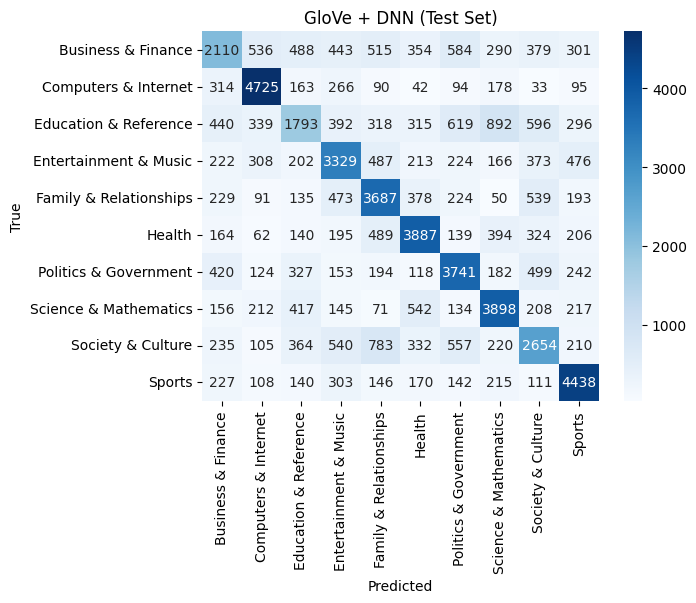

In [82]:
tf.keras.backend.clear_session()
embedded_dnn_std = build_embedded_dnn(data_std, vocab_size, embedding_matrix)
embedded_dnn_history_std = run_nn_experiment(data_std, tokenizer, embedded_dnn_std, "GloVe + DNN")


--- Training GloVe + DNN (Hyperparameter) ---
Epoch 1/1000
2334/2334 [==============================] - 6s 2ms/step - loss: 1.5497 - accuracy: 0.4822 - val_loss: 1.4158 - val_accuracy: 0.5340
Epoch 2/1000
2334/2334 [==============================] - 6s 2ms/step - loss: 1.4357 - accuracy: 0.5263 - val_loss: 1.3774 - val_accuracy: 0.5482
Epoch 3/1000
2334/2334 [==============================] - 5s 2ms/step - loss: 1.4110 - accuracy: 0.5348 - val_loss: 1.3852 - val_accuracy: 0.5455
Epoch 4/1000
2334/2334 [==============================] - 5s 2ms/step - loss: 1.3922 - accuracy: 0.5428 - val_loss: 1.3624 - val_accuracy: 0.5524
Epoch 5/1000
2334/2334 [==============================] - 6s 2ms/step - loss: 1.3779 - accuracy: 0.5458 - val_loss: 1.3881 - val_accuracy: 0.5418
Epoch 6/1000
2334/2334 [==============================] - 5s 2ms/step - loss: 1.3729 - accuracy: 0.5475 - val_loss: 1.3400 - val_accuracy: 0.5578
Epoch 7/1000
2334/2334 [==============================] - 5s 2ms/step - loss:

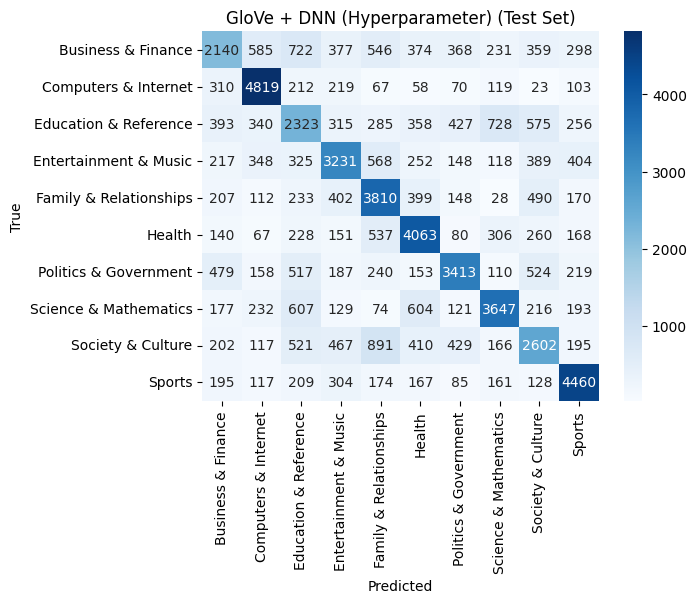

In [83]:
tf.keras.backend.clear_session()
embedded_dnn_hyper_std = build_embedded_dnn(data_std, vocab_size, embedding_matrix)
embedded_dnn_hyper_history_std = run_nn_experiment(data_std, tokenizer, embedded_dnn_hyper_std, "GloVe + DNN (Hyperparameter)")

RNN


--- Training GloVe + RNN ---
Epoch 1/1000
2334/2334 [==============================] - 193s 82ms/step - loss: 1.7041 - accuracy: 0.4300 - val_loss: 1.4839 - val_accuracy: 0.5106
Epoch 2/1000
2334/2334 [==============================] - 174s 74ms/step - loss: 1.6162 - accuracy: 0.4702 - val_loss: 1.5073 - val_accuracy: 0.5023
Epoch 3/1000
2334/2334 [==============================] - 172s 74ms/step - loss: 1.6701 - accuracy: 0.4516 - val_loss: 1.6277 - val_accuracy: 0.4528
Epoch 4/1000
2334/2334 [==============================] - 178s 76ms/step - loss: 1.6829 - accuracy: 0.4413 - val_loss: 1.7257 - val_accuracy: 0.4346
Epoch 5/1000
2334/2334 [==============================] - 181s 77ms/step - loss: 1.7188 - accuracy: 0.4308 - val_loss: 1.6238 - val_accuracy: 0.4725
Epoch 6/1000
2334/2334 [==============================] - 193s 83ms/step - loss: 1.7451 - accuracy: 0.4110 - val_loss: 1.6222 - val_accuracy: 0.4541
Epoch 7/1000
2334/2334 [==============================] - 179s 77ms/step - l

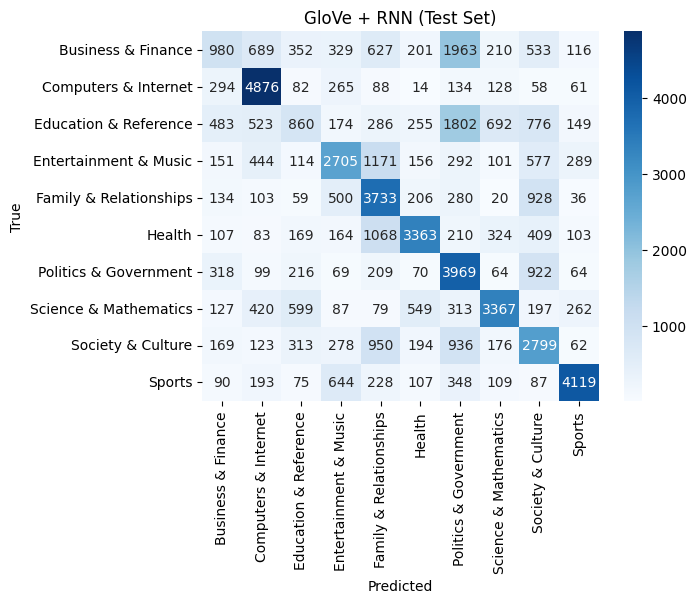

In [84]:
tf.keras.backend.clear_session()
rnn_std = build_rnn(data_std, vocab_size, embedding_matrix)
rnn_history_std = run_nn_experiment(data_std, tokenizer, rnn_std, "GloVe + RNN")


--- Training GloVe + RNN (Hyperparameter) ---
Epoch 1/1000
2334/2334 [==============================] - 431s 184ms/step - loss: 1.8971 - accuracy: 0.3514 - val_loss: 1.7142 - val_accuracy: 0.4219
Epoch 2/1000
2334/2334 [==============================] - 363s 155ms/step - loss: 1.7166 - accuracy: 0.4245 - val_loss: 1.7230 - val_accuracy: 0.4227
Epoch 3/1000
2334/2334 [==============================] - 402s 172ms/step - loss: 1.8831 - accuracy: 0.3502 - val_loss: 1.8397 - val_accuracy: 0.3640
Epoch 4/1000
2334/2334 [==============================] - 399s 171ms/step - loss: 1.9006 - accuracy: 0.3379 - val_loss: 1.8487 - val_accuracy: 0.3531
Epoch 5/1000
2334/2334 [==============================] - 373s 160ms/step - loss: 2.0139 - accuracy: 0.2791 - val_loss: 2.4706 - val_accuracy: 0.1961
Epoch 6/1000
2334/2334 [==============================] - 402s 172ms/step - loss: 1.9060 - accuracy: 0.3362 - val_loss: 1.9051 - val_accuracy: 0.3538
Epoch 7/1000
2334/2334 [=============================

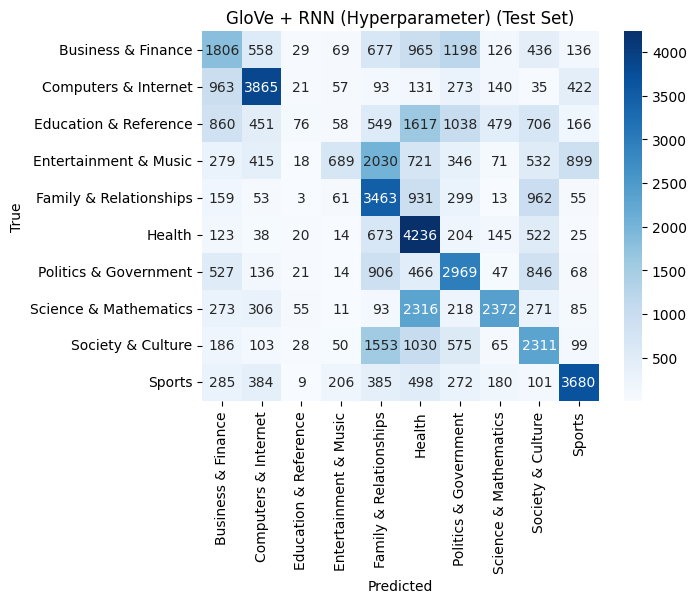

In [85]:
tf.keras.backend.clear_session()
rnn_hyper_std = build_rnn_hyperparameter(data_std, vocab_size, embedding_matrix)
rnn_hyper_history_std = run_nn_experiment(data_std, tokenizer, rnn_hyper_std, "GloVe + RNN (Hyperparameter)")

GRU


--- Training GloVe + GRU ---
Epoch 1/1000
2334/2334 [==============================] - 18s 7ms/step - loss: 1.3900 - accuracy: 0.5303 - val_loss: 1.0470 - val_accuracy: 0.6670
Epoch 2/1000
2334/2334 [==============================] - 16s 7ms/step - loss: 1.0288 - accuracy: 0.6743 - val_loss: 0.9811 - val_accuracy: 0.6852
Epoch 3/1000
2334/2334 [==============================] - 15s 7ms/step - loss: 0.9744 - accuracy: 0.6903 - val_loss: 0.9467 - val_accuracy: 0.6967
Epoch 4/1000
2334/2334 [==============================] - 15s 7ms/step - loss: 0.9406 - accuracy: 0.7001 - val_loss: 0.9420 - val_accuracy: 0.6963
Epoch 5/1000
2334/2334 [==============================] - 15s 6ms/step - loss: 0.9168 - accuracy: 0.7069 - val_loss: 0.9342 - val_accuracy: 0.6988
Epoch 6/1000
2334/2334 [==============================] - 15s 6ms/step - loss: 0.8978 - accuracy: 0.7120 - val_loss: 0.9266 - val_accuracy: 0.7017
Epoch 7/1000
2334/2334 [==============================] - 15s 7ms/step - loss: 0.8805 - 

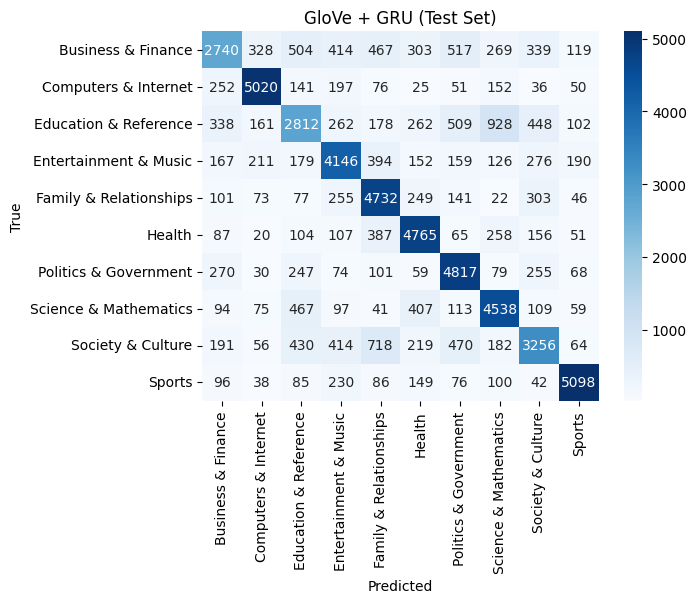

In [86]:
tf.keras.backend.clear_session()
gru_std = build_gru(data_std, vocab_size, embedding_matrix)
gru_history_std = run_nn_experiment(data_std, tokenizer, gru_std, "GloVe + GRU")


--- Training GloVe + GRU (Hyperparameter) ---
Epoch 1/1000
2334/2334 [==============================] - 27s 11ms/step - loss: 1.3451 - accuracy: 0.5515 - val_loss: 1.0212 - val_accuracy: 0.6731
Epoch 2/1000
2334/2334 [==============================] - 25s 11ms/step - loss: 1.0164 - accuracy: 0.6804 - val_loss: 0.9747 - val_accuracy: 0.6871
Epoch 3/1000
2334/2334 [==============================] - 25s 11ms/step - loss: 0.9616 - accuracy: 0.6957 - val_loss: 0.9371 - val_accuracy: 0.6998
Epoch 4/1000
2334/2334 [==============================] - 25s 11ms/step - loss: 0.9217 - accuracy: 0.7083 - val_loss: 0.9445 - val_accuracy: 0.6988
Epoch 5/1000
2334/2334 [==============================] - 26s 11ms/step - loss: 0.8827 - accuracy: 0.7200 - val_loss: 0.9497 - val_accuracy: 0.6968
Epoch 6/1000
2334/2334 [==============================] - 26s 11ms/step - loss: 0.8532 - accuracy: 0.7273 - val_loss: 0.9342 - val_accuracy: 0.7061
Epoch 7/1000
2334/2334 [==============================] - 26s 11m

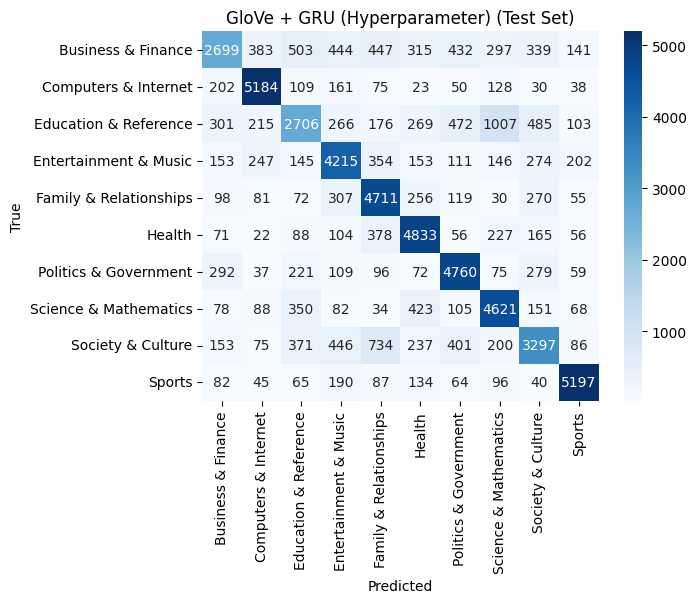

In [87]:
tf.keras.backend.clear_session()
gru_hyper_std = build_gru_hyperparameter(data_std, vocab_size, embedding_matrix)
gru_hyper_history_std = run_nn_experiment(data_std, tokenizer, gru_hyper_std, "GloVe + GRU (Hyperparameter)")

LSTM


--- Training GloVe + LSTM ---
Epoch 1/1000
2334/2334 [==============================] - 16s 7ms/step - loss: 1.6242 - accuracy: 0.4582 - val_loss: 1.2839 - val_accuracy: 0.6065
Epoch 2/1000
2334/2334 [==============================] - 15s 7ms/step - loss: 1.2340 - accuracy: 0.6281 - val_loss: 1.1297 - val_accuracy: 0.6466
Epoch 3/1000
2334/2334 [==============================] - 15s 7ms/step - loss: 1.1101 - accuracy: 0.6605 - val_loss: 1.0627 - val_accuracy: 0.6704
Epoch 4/1000
2334/2334 [==============================] - 15s 7ms/step - loss: 1.0465 - accuracy: 0.6770 - val_loss: 1.0175 - val_accuracy: 0.6775
Epoch 5/1000
2334/2334 [==============================] - 15s 6ms/step - loss: 1.0006 - accuracy: 0.6872 - val_loss: 0.9980 - val_accuracy: 0.6809
Epoch 6/1000
2334/2334 [==============================] - 15s 7ms/step - loss: 0.9669 - accuracy: 0.6964 - val_loss: 0.9701 - val_accuracy: 0.6916
Epoch 7/1000
2334/2334 [==============================] - 15s 7ms/step - loss: 0.9398 -

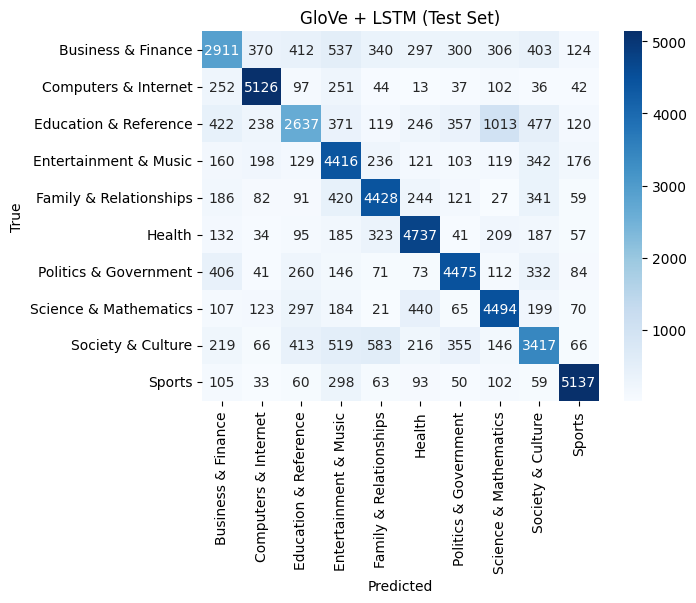

In [88]:
tf.keras.backend.clear_session()
lstm_std = build_lstm(data_std, vocab_size, embedding_matrix)
lstm_history_std = run_nn_experiment(data_std, tokenizer, lstm_std, "GloVe + LSTM")


--- Training GloVe + LSTM (Hyperparameter) ---
Epoch 1/1000
2334/2334 [==============================] - 32s 13ms/step - loss: 1.6093 - accuracy: 0.4710 - val_loss: 1.2853 - val_accuracy: 0.6050
Epoch 2/1000
2334/2334 [==============================] - 30s 13ms/step - loss: 1.2676 - accuracy: 0.6175 - val_loss: 1.1583 - val_accuracy: 0.6396
Epoch 3/1000
2334/2334 [==============================] - 30s 13ms/step - loss: 1.1923 - accuracy: 0.6389 - val_loss: 1.1272 - val_accuracy: 0.6471
Epoch 4/1000
2334/2334 [==============================] - 30s 13ms/step - loss: 1.1131 - accuracy: 0.6584 - val_loss: 1.0570 - val_accuracy: 0.6666
Epoch 5/1000
2334/2334 [==============================] - 30s 13ms/step - loss: 1.0585 - accuracy: 0.6731 - val_loss: 1.0348 - val_accuracy: 0.6715
Epoch 6/1000
2334/2334 [==============================] - 30s 13ms/step - loss: 1.0205 - accuracy: 0.6823 - val_loss: 0.9906 - val_accuracy: 0.6885
Epoch 7/1000
2334/2334 [==============================] - 30s 13

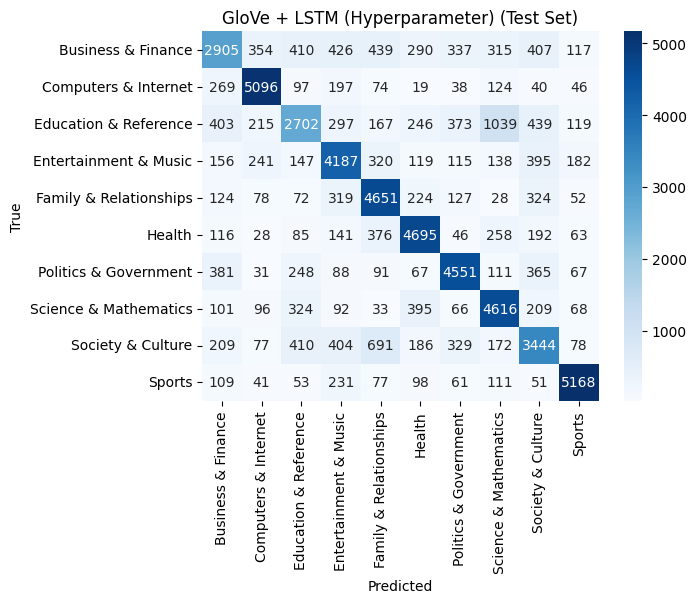

In [89]:
tf.keras.backend.clear_session()
lstm_hyper_std = build_lstm_hyperparameter(data_std, vocab_size, embedding_matrix)
lstm_hyper_history_std = run_nn_experiment(data_std, tokenizer, lstm_hyper_std, "GloVe + LSTM (Hyperparameter)")

Bi RNN


--- Training GloVe + Bi-RNN ---
Epoch 1/1000
2334/2334 [==============================] - 178s 76ms/step - loss: 1.4712 - accuracy: 0.5194 - val_loss: 1.2713 - val_accuracy: 0.5908
Epoch 2/1000
2334/2334 [==============================] - 176s 75ms/step - loss: 1.2768 - accuracy: 0.6009 - val_loss: 1.2976 - val_accuracy: 0.5862
Epoch 3/1000
2334/2334 [==============================] - 176s 75ms/step - loss: 1.2427 - accuracy: 0.6130 - val_loss: 1.2274 - val_accuracy: 0.6099
Epoch 4/1000
2334/2334 [==============================] - 178s 76ms/step - loss: 1.2289 - accuracy: 0.6163 - val_loss: 1.2418 - val_accuracy: 0.6071
Epoch 5/1000
2334/2334 [==============================] - 182s 78ms/step - loss: 1.2391 - accuracy: 0.6158 - val_loss: 1.2226 - val_accuracy: 0.6139
Epoch 6/1000
2334/2334 [==============================] - 182s 78ms/step - loss: 1.2451 - accuracy: 0.6147 - val_loss: 1.1703 - val_accuracy: 0.6314
Epoch 7/1000
2334/2334 [==============================] - 181s 78ms/step 

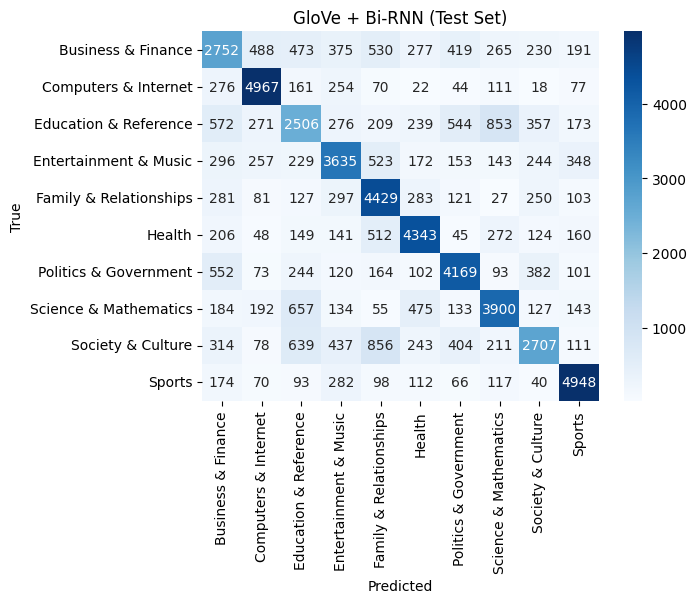

In [90]:
tf.keras.backend.clear_session()
birnn_std = build_birnn(data_std, vocab_size, embedding_matrix)
birnn_history_std = run_nn_experiment(data_std, tokenizer, birnn_std, "GloVe + Bi-RNN")


--- Training GloVe + Bi-RNN (Hyperparameter) ---
Epoch 1/1000
2334/2334 [==============================] - 433s 185ms/step - loss: 1.5932 - accuracy: 0.4789 - val_loss: 1.3362 - val_accuracy: 0.5737
Epoch 2/1000
2334/2334 [==============================] - 437s 187ms/step - loss: 1.3849 - accuracy: 0.5698 - val_loss: 1.4376 - val_accuracy: 0.5431
Epoch 3/1000
2334/2334 [==============================] - 428s 184ms/step - loss: 1.3652 - accuracy: 0.5753 - val_loss: 1.3216 - val_accuracy: 0.5866
Epoch 4/1000
2334/2334 [==============================] - 400s 171ms/step - loss: 1.3570 - accuracy: 0.5789 - val_loss: 1.3148 - val_accuracy: 0.5857
Epoch 5/1000
2334/2334 [==============================] - 428s 184ms/step - loss: 1.3494 - accuracy: 0.5815 - val_loss: 1.2608 - val_accuracy: 0.6050
Epoch 6/1000
2334/2334 [==============================] - 418s 179ms/step - loss: 1.3418 - accuracy: 0.5862 - val_loss: 1.3553 - val_accuracy: 0.5726
Epoch 7/1000
2334/2334 [==========================

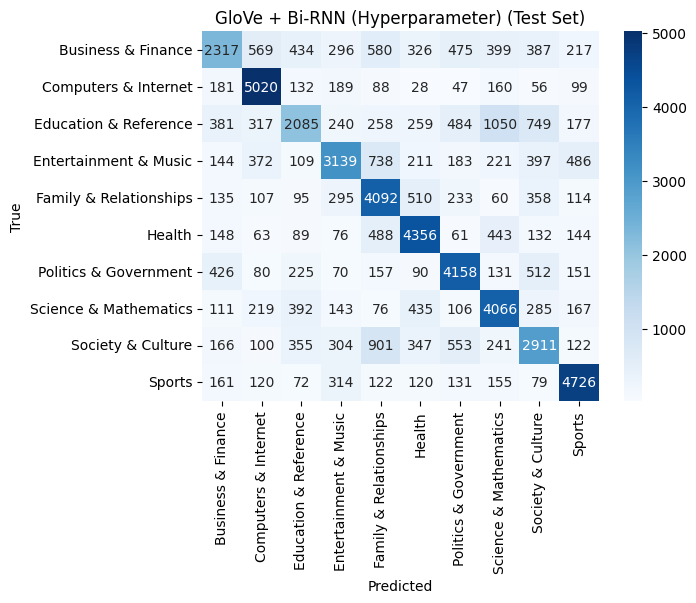

In [91]:
tf.keras.backend.clear_session()
birnn_hyper_std = build_birnn_hyperparameter(data_std, vocab_size, embedding_matrix)
birnn_hyper_history_std = run_nn_experiment(data_std, tokenizer, birnn_hyper_std, "GloVe + Bi-RNN (Hyperparameter)")

Bi GRU


--- Training GloVe + Bi-GRU ---
Epoch 1/1000
2334/2334 [==============================] - 28s 12ms/step - loss: 1.1640 - accuracy: 0.6209 - val_loss: 0.9950 - val_accuracy: 0.6806
Epoch 2/1000
2334/2334 [==============================] - 27s 11ms/step - loss: 0.9915 - accuracy: 0.6825 - val_loss: 0.9640 - val_accuracy: 0.6896
Epoch 3/1000
2334/2334 [==============================] - 29s 12ms/step - loss: 0.9496 - accuracy: 0.6955 - val_loss: 0.9411 - val_accuracy: 0.6967
Epoch 4/1000
2334/2334 [==============================] - 28s 12ms/step - loss: 0.9199 - accuracy: 0.7042 - val_loss: 0.9435 - val_accuracy: 0.6956
Epoch 5/1000
2334/2334 [==============================] - 28s 12ms/step - loss: 0.8913 - accuracy: 0.7133 - val_loss: 0.9535 - val_accuracy: 0.6935
Epoch 6/1000
2334/2334 [==============================] - 29s 12ms/step - loss: 0.8678 - accuracy: 0.7201 - val_loss: 0.9441 - val_accuracy: 0.6955
Epoch 7/1000
2334/2334 [==============================] - 27s 11ms/step - loss:

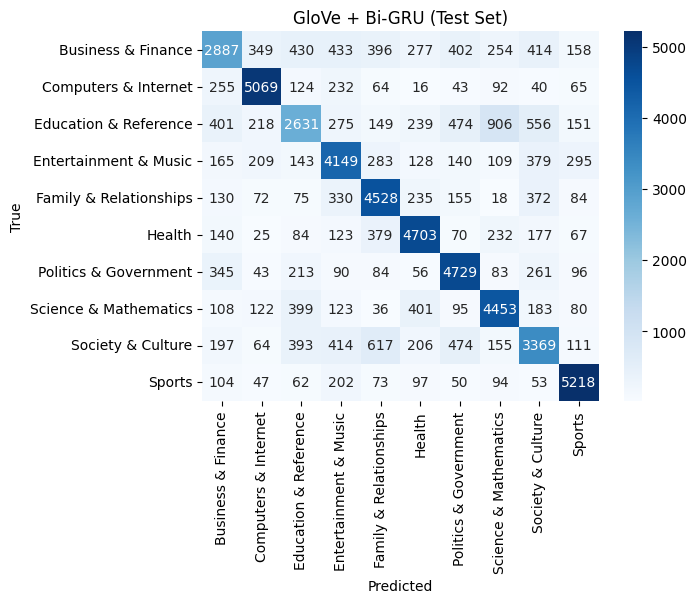

In [92]:
tf.keras.backend.clear_session()
bigru_std = build_bigru(data_std, vocab_size, embedding_matrix)
bigru_history_std = run_nn_experiment(data_std, tokenizer, bigru_std, "GloVe + Bi-GRU")


--- Training GloVe + Bi-GRU (Hyperparameter) ---
Epoch 1/1000
2334/2334 [==============================] - 56s 23ms/step - loss: 1.1638 - accuracy: 0.6241 - val_loss: 0.9869 - val_accuracy: 0.6839
Epoch 2/1000
2334/2334 [==============================] - 53s 23ms/step - loss: 0.9966 - accuracy: 0.6836 - val_loss: 0.9563 - val_accuracy: 0.6938
Epoch 3/1000
2334/2334 [==============================] - 52s 22ms/step - loss: 0.9470 - accuracy: 0.6992 - val_loss: 0.9310 - val_accuracy: 0.7028
Epoch 4/1000
2334/2334 [==============================] - 53s 23ms/step - loss: 0.9055 - accuracy: 0.7117 - val_loss: 0.9453 - val_accuracy: 0.6998
Epoch 5/1000
2334/2334 [==============================] - 53s 23ms/step - loss: 0.8610 - accuracy: 0.7249 - val_loss: 0.9534 - val_accuracy: 0.6952
Epoch 6/1000
2334/2334 [==============================] - 50s 21ms/step - loss: 0.8191 - accuracy: 0.7380 - val_loss: 0.9417 - val_accuracy: 0.7031
Epoch 7/1000
2334/2334 [==============================] - 52s 

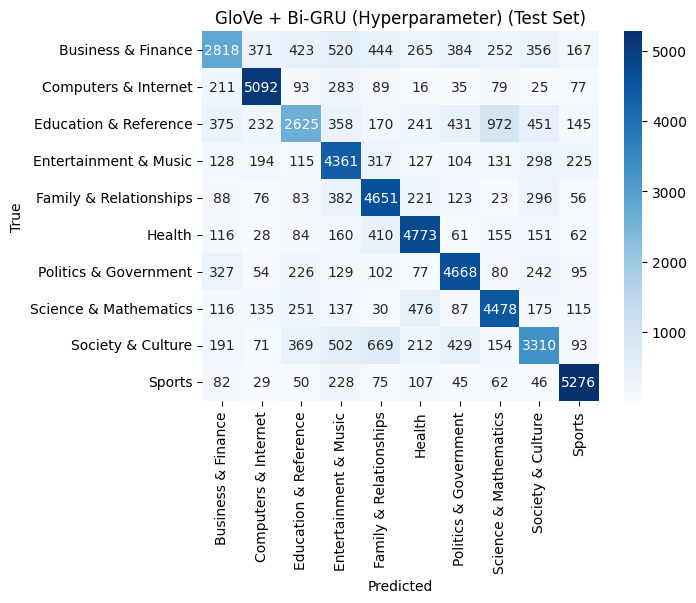

In [93]:
tf.keras.backend.clear_session()
bigru_hyper_std = build_bigru_hyperparameter(data_std, vocab_size, embedding_matrix)
bigru_hyper_history_std = run_nn_experiment(data_std, tokenizer, bigru_hyper_std, "GloVe + Bi-GRU (Hyperparameter)")

Bi LSTM


--- Training GloVe + Bi-LSTM ---
Epoch 1/1000
2334/2334 [==============================] - 31s 13ms/step - loss: 1.1594 - accuracy: 0.6266 - val_loss: 1.0068 - val_accuracy: 0.6719
Epoch 2/1000
2334/2334 [==============================] - 28s 12ms/step - loss: 1.0064 - accuracy: 0.6779 - val_loss: 0.9781 - val_accuracy: 0.6831
Epoch 3/1000
2334/2334 [==============================] - 29s 12ms/step - loss: 0.9637 - accuracy: 0.6909 - val_loss: 0.9517 - val_accuracy: 0.6935
Epoch 4/1000
2334/2334 [==============================] - 29s 12ms/step - loss: 0.9346 - accuracy: 0.7007 - val_loss: 0.9511 - val_accuracy: 0.6919
Epoch 5/1000
2334/2334 [==============================] - 29s 12ms/step - loss: 0.9060 - accuracy: 0.7081 - val_loss: 0.9538 - val_accuracy: 0.6914
Epoch 6/1000
2334/2334 [==============================] - 30s 13ms/step - loss: 0.8843 - accuracy: 0.7141 - val_loss: 0.9376 - val_accuracy: 0.6976
Epoch 7/1000
2334/2334 [==============================] - 28s 12ms/step - loss

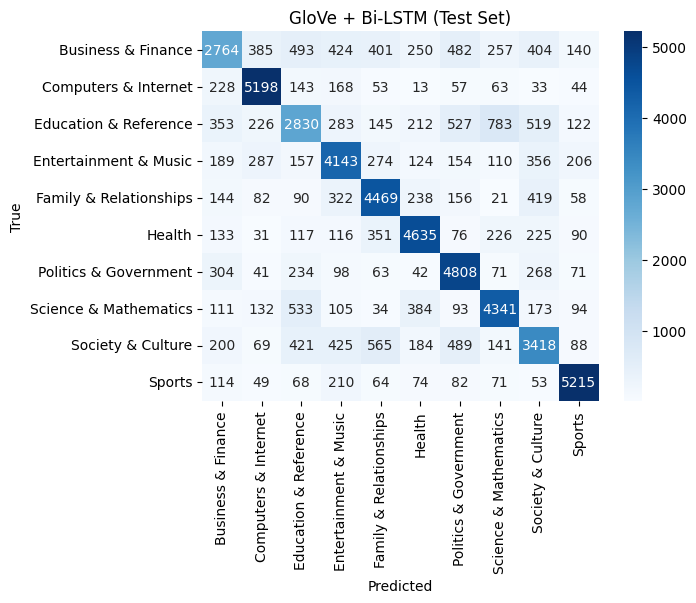

In [94]:
tf.keras.backend.clear_session()
bilstm_std = build_bilstm(data_std, vocab_size, embedding_matrix)
bilstm_history_std = run_nn_experiment(data_std, tokenizer, bilstm_std, "GloVe + Bi-LSTM")


--- Training GloVe + Bi-LSTM (Hyperparameter) ---
Epoch 1/1000
2334/2334 [==============================] - 60s 25ms/step - loss: 1.1500 - accuracy: 0.6355 - val_loss: 1.0033 - val_accuracy: 0.6803
Epoch 2/1000
2334/2334 [==============================] - 56s 24ms/step - loss: 1.0046 - accuracy: 0.6810 - val_loss: 0.9642 - val_accuracy: 0.6882
Epoch 3/1000
2334/2334 [==============================] - 56s 24ms/step - loss: 0.9523 - accuracy: 0.6984 - val_loss: 0.9355 - val_accuracy: 0.7013
Epoch 4/1000
2334/2334 [==============================] - 56s 24ms/step - loss: 0.9059 - accuracy: 0.7105 - val_loss: 0.9304 - val_accuracy: 0.7004
Epoch 5/1000
2334/2334 [==============================] - 56s 24ms/step - loss: 0.8642 - accuracy: 0.7245 - val_loss: 0.9405 - val_accuracy: 0.6981
Epoch 6/1000
2334/2334 [==============================] - 56s 24ms/step - loss: 0.8237 - accuracy: 0.7355 - val_loss: 0.9327 - val_accuracy: 0.7061
Epoch 7/1000
2334/2334 [==============================] - 56s

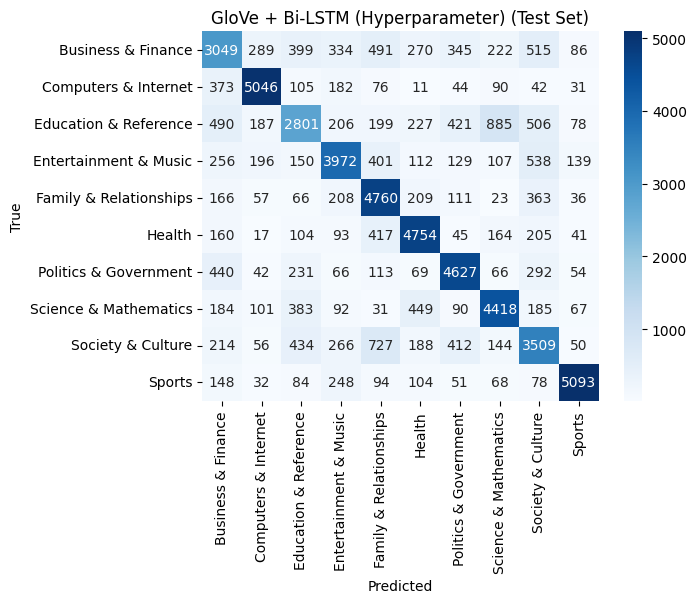

In [95]:
tf.keras.backend.clear_session()
bilstm_hyper_std = build_bilstm_hyperparameter(data_std, vocab_size, embedding_matrix)
bilstm_hyper_history_std = run_nn_experiment(data_std, tokenizer, bilstm_hyper_std, "GloVe + Bi-LSTM (Hyperparameter)")

### Feature Engineered Data

In [96]:
embedding_matrix_eng, vocab_size_eng, tokenizer_eng = build_embedding_matrix(data_eng)
embedding_matrix, vocab_size, tokenizer = embedding_matrix_eng, vocab_size_eng, tokenizer_eng

DNN


--- Training GloVe + DNN (Eng) ---
Epoch 1/1000
2334/2334 [==============================] - 6s 2ms/step - loss: 1.5303 - accuracy: 0.4899 - val_loss: 1.4044 - val_accuracy: 0.5375
Epoch 2/1000
2334/2334 [==============================] - 5s 2ms/step - loss: 1.4138 - accuracy: 0.5338 - val_loss: 1.3577 - val_accuracy: 0.5549
Epoch 3/1000
2334/2334 [==============================] - 5s 2ms/step - loss: 1.3879 - accuracy: 0.5433 - val_loss: 1.3572 - val_accuracy: 0.5548
Epoch 4/1000
2334/2334 [==============================] - 5s 2ms/step - loss: 1.3692 - accuracy: 0.5497 - val_loss: 1.3527 - val_accuracy: 0.5565
Epoch 5/1000
2334/2334 [==============================] - 5s 2ms/step - loss: 1.3553 - accuracy: 0.5547 - val_loss: 1.3481 - val_accuracy: 0.5535
Epoch 6/1000
2334/2334 [==============================] - 5s 2ms/step - loss: 1.3510 - accuracy: 0.5567 - val_loss: 1.3192 - val_accuracy: 0.5662
Epoch 7/1000
2334/2334 [==============================] - 5s 2ms/step - loss: 1.3383 - a

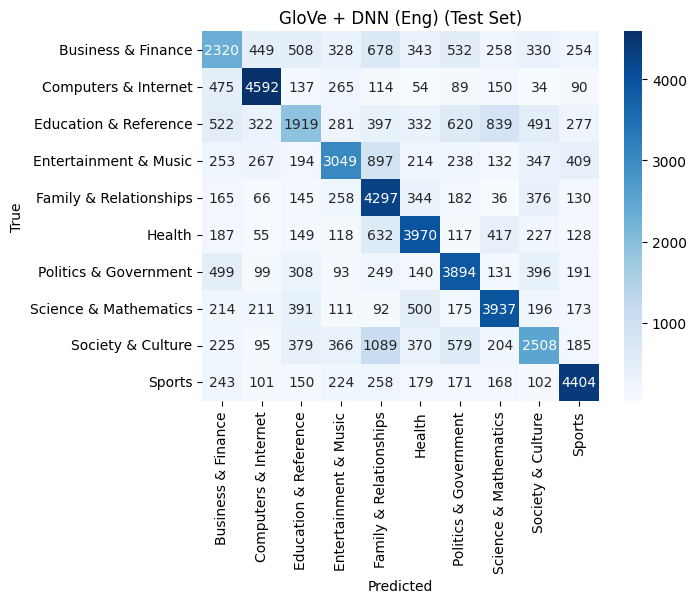

In [97]:
tf.keras.backend.clear_session()
embedded_dnn_eng = build_embedded_dnn(data_eng, vocab_size, embedding_matrix)
embedded_dnn_history_eng = run_nn_experiment(data_eng, tokenizer, embedded_dnn_eng, "GloVe + DNN (Eng)")


--- Training GloVe + DNN (Eng - Hyperparameter) ---
Epoch 1/1000
2334/2334 [==============================] - 6s 3ms/step - loss: 1.5250 - accuracy: 0.4903 - val_loss: 1.3871 - val_accuracy: 0.5393
Epoch 2/1000
2334/2334 [==============================] - 5s 2ms/step - loss: 1.4124 - accuracy: 0.5345 - val_loss: 1.3598 - val_accuracy: 0.5575
Epoch 3/1000
2334/2334 [==============================] - 5s 2ms/step - loss: 1.3873 - accuracy: 0.5428 - val_loss: 1.3739 - val_accuracy: 0.5496
Epoch 4/1000
2334/2334 [==============================] - 5s 2ms/step - loss: 1.3674 - accuracy: 0.5500 - val_loss: 1.3516 - val_accuracy: 0.5546
Epoch 5/1000
2334/2334 [==============================] - 5s 2ms/step - loss: 1.3573 - accuracy: 0.5547 - val_loss: 1.3378 - val_accuracy: 0.5592
Epoch 6/1000
2334/2334 [==============================] - 5s 2ms/step - loss: 1.3463 - accuracy: 0.5572 - val_loss: 1.3260 - val_accuracy: 0.5676
Epoch 7/1000
2334/2334 [==============================] - 5s 2ms/step -

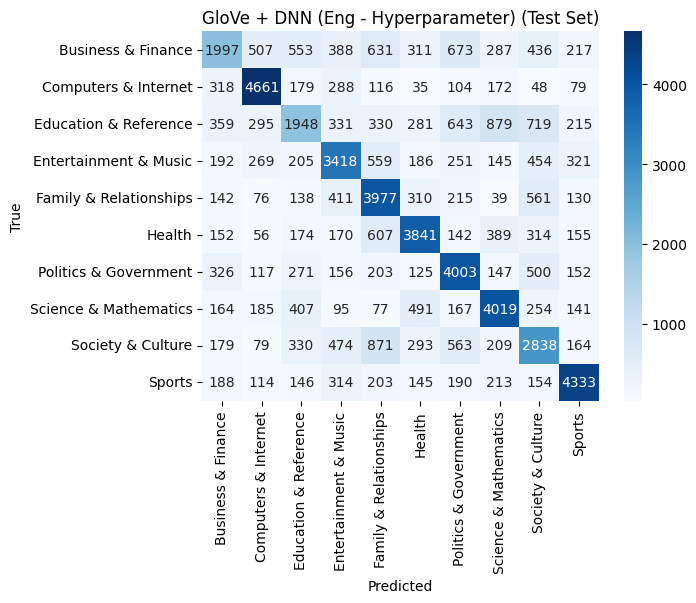

In [98]:
tf.keras.backend.clear_session()
embedded_dnn_hyper_eng = build_embedded_dnn(data_eng, vocab_size, embedding_matrix)
embedded_dnn_hyper_history_eng = run_nn_experiment(data_eng, tokenizer, embedded_dnn_hyper_eng, "GloVe + DNN (Eng - Hyperparameter)")

RNN


--- Training GloVe + RNN (Eng) ---
Epoch 1/1000
2334/2334 [==============================] - 186s 79ms/step - loss: 1.7618 - accuracy: 0.3963 - val_loss: 1.5155 - val_accuracy: 0.4900
Epoch 2/1000
2334/2334 [==============================] - 180s 77ms/step - loss: 1.5948 - accuracy: 0.4785 - val_loss: 1.5640 - val_accuracy: 0.4836
Epoch 3/1000
2334/2334 [==============================] - 174s 74ms/step - loss: 1.6659 - accuracy: 0.4489 - val_loss: 1.9517 - val_accuracy: 0.3759
Epoch 4/1000
2334/2334 [==============================] - 176s 76ms/step - loss: 1.7686 - accuracy: 0.4028 - val_loss: 1.6167 - val_accuracy: 0.4692
Epoch 5/1000
2334/2334 [==============================] - 175s 75ms/step - loss: 1.6839 - accuracy: 0.4404 - val_loss: 1.5922 - val_accuracy: 0.4800
Epoch 6/1000
2334/2334 [==============================] - 177s 76ms/step - loss: 1.6760 - accuracy: 0.4413 - val_loss: 1.6566 - val_accuracy: 0.4477
Epoch 7/1000
2334/2334 [==============================] - 171s 73ms/st

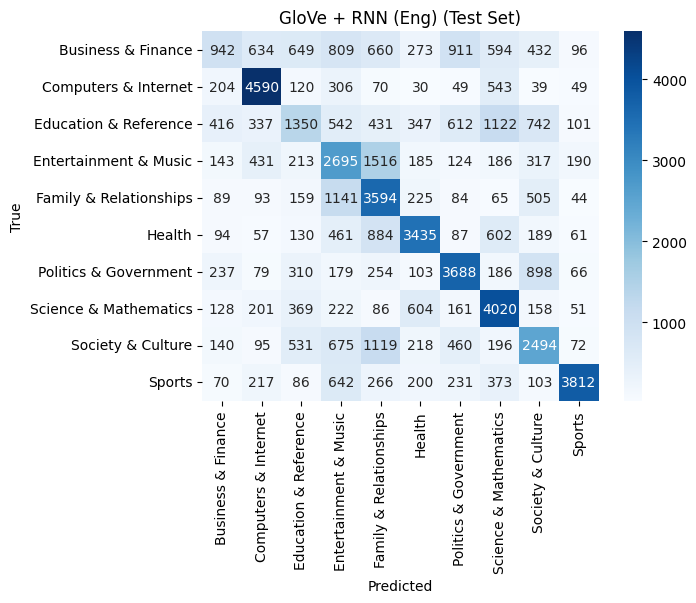

In [99]:
tf.keras.backend.clear_session()
rnn_eng = build_rnn(data_eng, vocab_size, embedding_matrix)
rnn_history_eng = run_nn_experiment(data_eng, tokenizer, rnn_eng, "GloVe + RNN (Eng)")


--- Training GloVe + RNN (Eng - Hyperparameter) ---
Epoch 1/1000
2334/2334 [==============================] - 372s 159ms/step - loss: 1.8281 - accuracy: 0.3809 - val_loss: 1.7372 - val_accuracy: 0.4227
Epoch 2/1000
2334/2334 [==============================] - 388s 166ms/step - loss: 1.7640 - accuracy: 0.4041 - val_loss: 1.7909 - val_accuracy: 0.3874
Epoch 3/1000
2334/2334 [==============================] - 376s 161ms/step - loss: 1.8393 - accuracy: 0.3703 - val_loss: 2.0047 - val_accuracy: 0.2863
Epoch 4/1000
2334/2334 [==============================] - 381s 163ms/step - loss: 1.8726 - accuracy: 0.3537 - val_loss: 1.8112 - val_accuracy: 0.3752
Epoch 5/1000
2334/2334 [==============================] - 350s 150ms/step - loss: 1.6687 - accuracy: 0.4461 - val_loss: 1.6207 - val_accuracy: 0.4596
Epoch 6/1000
2334/2334 [==============================] - 356s 152ms/step - loss: 1.8146 - accuracy: 0.3752 - val_loss: 1.9822 - val_accuracy: 0.3051
Epoch 7/1000
2334/2334 [=======================

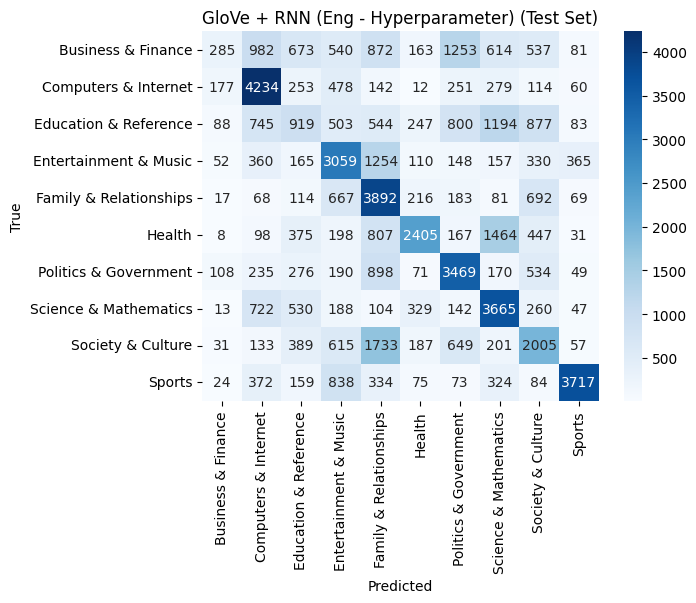

In [100]:
tf.keras.backend.clear_session()
rnn_hyper_eng = build_rnn_hyperparameter(data_eng, vocab_size, embedding_matrix)
rnn_hyper_history_eng = run_nn_experiment(data_eng, tokenizer, rnn_hyper_eng, "GloVe + RNN (Eng - Hyperparameter)")

GRU


--- Training GloVe + GRU (Eng) ---
Epoch 1/1000
2334/2334 [==============================] - 15s 6ms/step - loss: 1.4803 - accuracy: 0.4978 - val_loss: 1.0724 - val_accuracy: 0.6622
Epoch 2/1000
2334/2334 [==============================] - 15s 6ms/step - loss: 1.0454 - accuracy: 0.6713 - val_loss: 0.9869 - val_accuracy: 0.6851
Epoch 3/1000
2334/2334 [==============================] - 15s 6ms/step - loss: 0.9815 - accuracy: 0.6873 - val_loss: 0.9548 - val_accuracy: 0.6985
Epoch 4/1000
2334/2334 [==============================] - 15s 7ms/step - loss: 0.9469 - accuracy: 0.6982 - val_loss: 0.9510 - val_accuracy: 0.6956
Epoch 5/1000
2334/2334 [==============================] - 15s 7ms/step - loss: 0.9194 - accuracy: 0.7066 - val_loss: 0.9480 - val_accuracy: 0.6961
Epoch 6/1000
2334/2334 [==============================] - 15s 6ms/step - loss: 0.8982 - accuracy: 0.7121 - val_loss: 0.9343 - val_accuracy: 0.7029
Epoch 7/1000
2334/2334 [==============================] - 15s 6ms/step - loss: 0.8

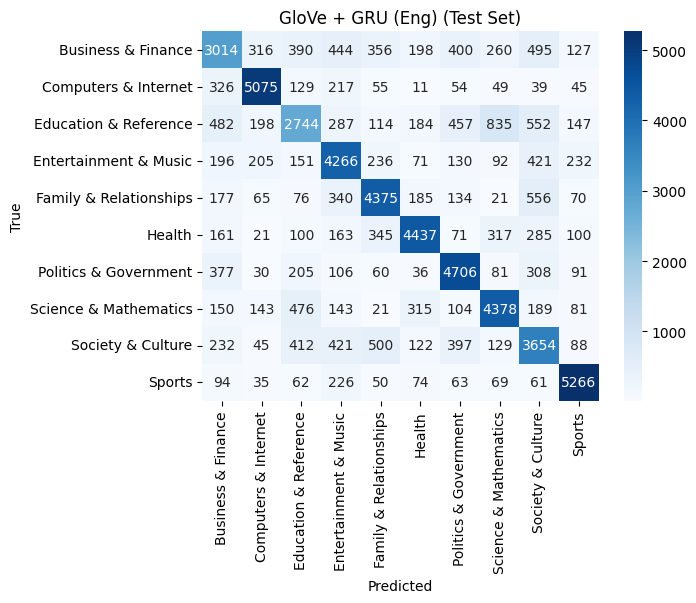

In [101]:
tf.keras.backend.clear_session()
gru_eng = build_gru(data_eng, vocab_size, embedding_matrix)
gru_history_eng = run_nn_experiment(data_eng, tokenizer, gru_eng, "GloVe + GRU (Eng)")


--- Training GloVe + GRU (Eng - Hyperparameter) ---
Epoch 1/1000
2334/2334 [==============================] - 30s 12ms/step - loss: 1.3421 - accuracy: 0.5512 - val_loss: 1.0115 - val_accuracy: 0.6798
Epoch 2/1000
2334/2334 [==============================] - 29s 12ms/step - loss: 1.0095 - accuracy: 0.6833 - val_loss: 0.9619 - val_accuracy: 0.6938
Epoch 3/1000
2334/2334 [==============================] - 29s 12ms/step - loss: 0.9512 - accuracy: 0.6990 - val_loss: 0.9350 - val_accuracy: 0.7018
Epoch 4/1000
2334/2334 [==============================] - 29s 12ms/step - loss: 0.9141 - accuracy: 0.7107 - val_loss: 0.9276 - val_accuracy: 0.7003
Epoch 5/1000
2334/2334 [==============================] - 28s 12ms/step - loss: 0.8761 - accuracy: 0.7228 - val_loss: 0.9349 - val_accuracy: 0.6981
Epoch 6/1000
2334/2334 [==============================] - 29s 12ms/step - loss: 0.8444 - accuracy: 0.7317 - val_loss: 0.9377 - val_accuracy: 0.7041
Epoch 7/1000
2334/2334 [==============================] - 2

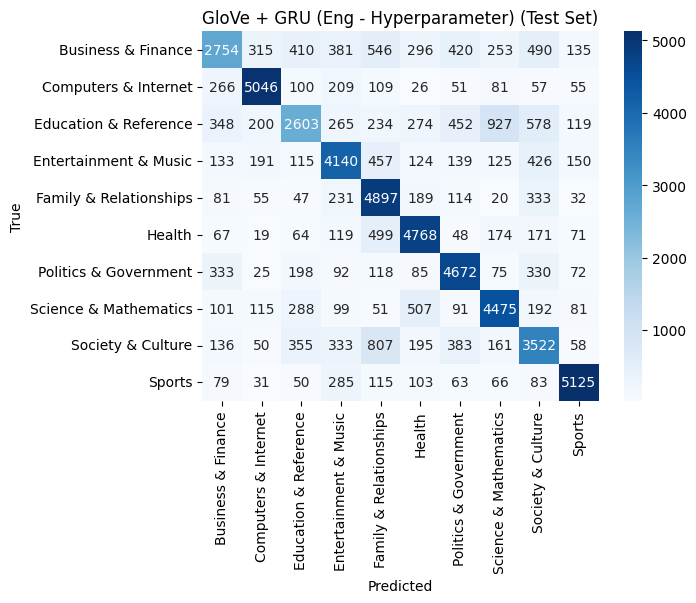

In [102]:
tf.keras.backend.clear_session()
gru_hyper_eng = build_gru_hyperparameter(data_eng, vocab_size, embedding_matrix)
gru_hyper_history_eng = run_nn_experiment(data_eng, tokenizer, gru_hyper_eng, "GloVe + GRU (Eng - Hyperparameter)")

LSTM


--- Training GloVe + LSTM (Eng) ---
Epoch 1/1000
2334/2334 [==============================] - 18s 7ms/step - loss: 2.0587 - accuracy: 0.2564 - val_loss: 2.0938 - val_accuracy: 0.2099
Epoch 2/1000
2334/2334 [==============================] - 17s 7ms/step - loss: 1.8704 - accuracy: 0.3393 - val_loss: 1.6274 - val_accuracy: 0.4709
Epoch 3/1000
2334/2334 [==============================] - 16s 7ms/step - loss: 1.3821 - accuracy: 0.5660 - val_loss: 1.2238 - val_accuracy: 0.6118
Epoch 4/1000
2334/2334 [==============================] - 16s 7ms/step - loss: 1.2147 - accuracy: 0.6293 - val_loss: 1.1237 - val_accuracy: 0.6474
Epoch 5/1000
2334/2334 [==============================] - 16s 7ms/step - loss: 1.0954 - accuracy: 0.6612 - val_loss: 1.0469 - val_accuracy: 0.6672
Epoch 6/1000
2334/2334 [==============================] - 16s 7ms/step - loss: 1.0331 - accuracy: 0.6768 - val_loss: 0.9971 - val_accuracy: 0.6816
Epoch 7/1000
2334/2334 [==============================] - 17s 7ms/step - loss: 0.

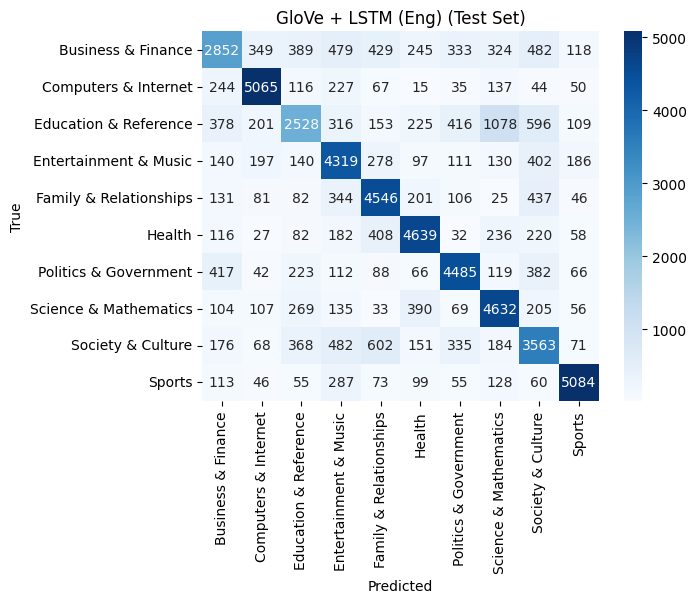

In [103]:
tf.keras.backend.clear_session()
lstm_eng = build_lstm(data_eng, vocab_size, embedding_matrix)
lstm_history_eng = run_nn_experiment(data_eng, tokenizer, lstm_eng, "GloVe + LSTM (Eng)")


--- Training GloVe + LSTM (Eng - Hyperparameter) ---
Epoch 1/1000
2334/2334 [==============================] - 34s 14ms/step - loss: 1.9222 - accuracy: 0.3138 - val_loss: 1.4847 - val_accuracy: 0.5104
Epoch 2/1000
2334/2334 [==============================] - 31s 13ms/step - loss: 1.2530 - accuracy: 0.6078 - val_loss: 1.0679 - val_accuracy: 0.6623
Epoch 3/1000
2334/2334 [==============================] - 32s 14ms/step - loss: 1.0726 - accuracy: 0.6657 - val_loss: 1.0055 - val_accuracy: 0.6805
Epoch 4/1000
2334/2334 [==============================] - 31s 13ms/step - loss: 1.0111 - accuracy: 0.6845 - val_loss: 0.9851 - val_accuracy: 0.6874
Epoch 5/1000
2334/2334 [==============================] - 32s 14ms/step - loss: 0.9656 - accuracy: 0.6975 - val_loss: 0.9624 - val_accuracy: 0.6915
Epoch 6/1000
2334/2334 [==============================] - 33s 14ms/step - loss: 0.9321 - accuracy: 0.7080 - val_loss: 0.9520 - val_accuracy: 0.7018
Epoch 7/1000
2334/2334 [==============================] - 

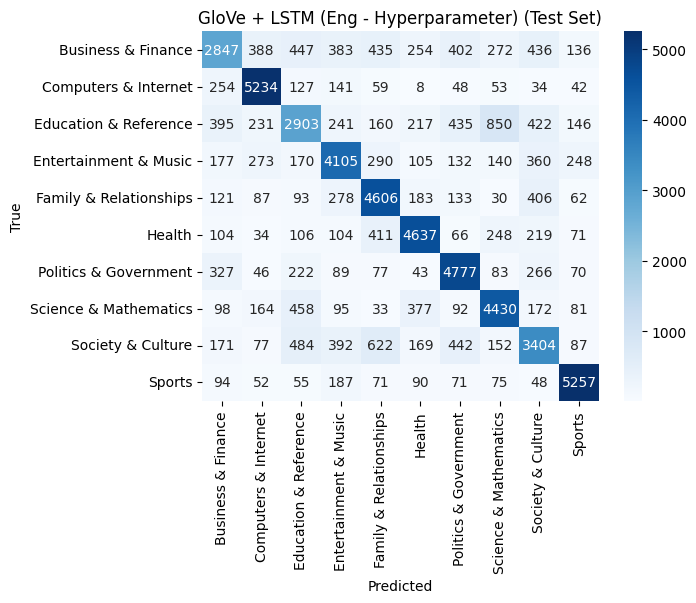

In [104]:
tf.keras.backend.clear_session()
lstm_hyper_eng = build_lstm_hyperparameter(data_eng, vocab_size, embedding_matrix)
lstm_hyper_history_eng = run_nn_experiment(data_eng, tokenizer, lstm_hyper_eng, "GloVe + LSTM (Eng - Hyperparameter)")

Bi RNN


--- Training GloVe + Bi-RNN (Eng) ---
Epoch 1/1000
2334/2334 [==============================] - 203s 87ms/step - loss: 1.4299 - accuracy: 0.5323 - val_loss: 1.2662 - val_accuracy: 0.5950
Epoch 2/1000
2334/2334 [==============================] - 206s 88ms/step - loss: 1.2451 - accuracy: 0.6068 - val_loss: 1.1860 - val_accuracy: 0.6219
Epoch 3/1000
2334/2334 [==============================] - 211s 90ms/step - loss: 1.2521 - accuracy: 0.6075 - val_loss: 1.1945 - val_accuracy: 0.6223
Epoch 4/1000
2334/2334 [==============================] - 198s 85ms/step - loss: 1.2184 - accuracy: 0.6220 - val_loss: 1.1765 - val_accuracy: 0.6295
Epoch 5/1000
2334/2334 [==============================] - 190s 81ms/step - loss: 1.2142 - accuracy: 0.6223 - val_loss: 1.1887 - val_accuracy: 0.6263
Epoch 6/1000
2334/2334 [==============================] - 183s 78ms/step - loss: 1.2431 - accuracy: 0.6092 - val_loss: 1.1705 - val_accuracy: 0.6301
Epoch 7/1000
2334/2334 [==============================] - 187s 80ms

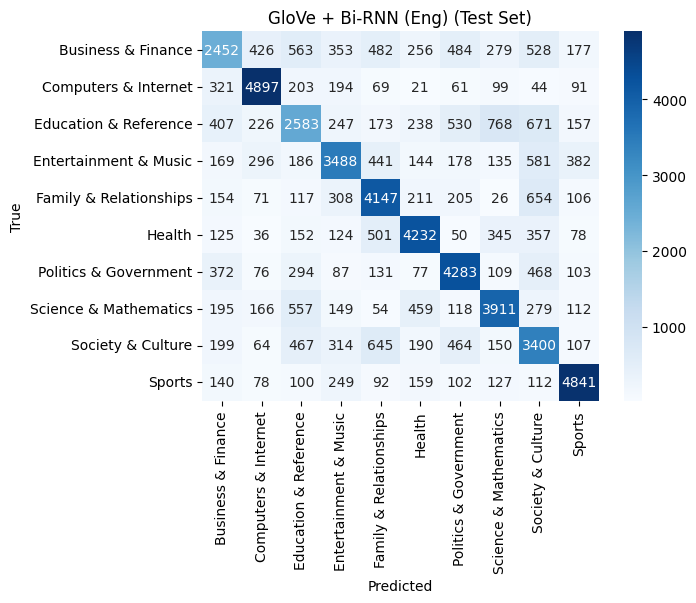

In [105]:
tf.keras.backend.clear_session()
birnn_eng = build_birnn(data_eng, vocab_size, embedding_matrix)
birnn_history_eng = run_nn_experiment(data_eng, tokenizer, birnn_eng, "GloVe + Bi-RNN (Eng)")


--- Training GloVe + Bi-RNN (Eng - Hyperparameter) ---
Epoch 1/1000
2334/2334 [==============================] - 485s 207ms/step - loss: 1.4976 - accuracy: 0.5170 - val_loss: 1.2885 - val_accuracy: 0.5945
Epoch 2/1000
2334/2334 [==============================] - 411s 176ms/step - loss: 1.3240 - accuracy: 0.5866 - val_loss: 1.2299 - val_accuracy: 0.6130
Epoch 3/1000
2334/2334 [==============================] - 432s 185ms/step - loss: 1.2756 - accuracy: 0.6053 - val_loss: 1.2046 - val_accuracy: 0.6182
Epoch 4/1000
2334/2334 [==============================] - 436s 187ms/step - loss: 1.2616 - accuracy: 0.6108 - val_loss: 1.2189 - val_accuracy: 0.6209
Epoch 5/1000
2334/2334 [==============================] - 444s 190ms/step - loss: 1.2746 - accuracy: 0.6081 - val_loss: 1.1859 - val_accuracy: 0.6293
Epoch 6/1000
2334/2334 [==============================] - 428s 184ms/step - loss: 1.2889 - accuracy: 0.6013 - val_loss: 1.2142 - val_accuracy: 0.6193
Epoch 7/1000
2334/2334 [====================

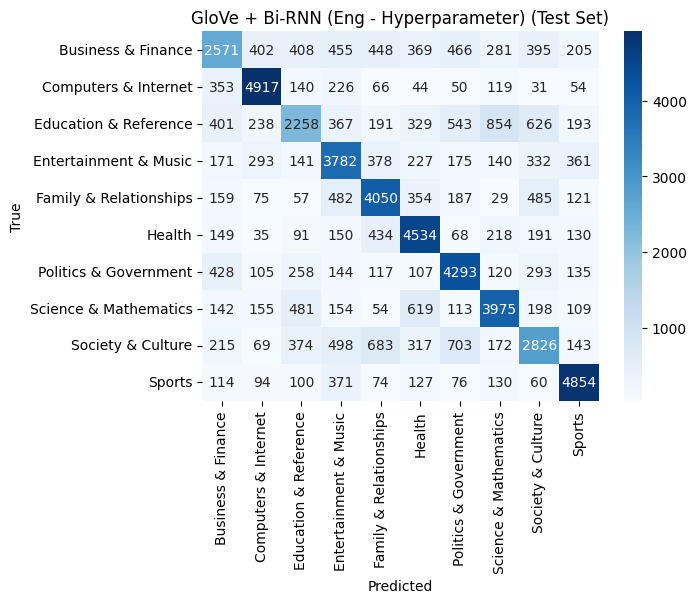

In [106]:
tf.keras.backend.clear_session()
birnn_hyper_eng = build_birnn_hyperparameter(data_eng, vocab_size, embedding_matrix)
birnn_hyper_history_eng = run_nn_experiment(data_eng, tokenizer, birnn_hyper_eng, "GloVe + Bi-RNN (Eng - Hyperparameter)")

Bi GRU


--- Training GloVe + Bi-GRU (Eng) ---
Epoch 1/1000
2334/2334 [==============================] - 29s 12ms/step - loss: 1.1427 - accuracy: 0.6332 - val_loss: 0.9933 - val_accuracy: 0.6783
Epoch 2/1000
2334/2334 [==============================] - 27s 11ms/step - loss: 0.9914 - accuracy: 0.6818 - val_loss: 0.9619 - val_accuracy: 0.6902
Epoch 3/1000
2334/2334 [==============================] - 26s 11ms/step - loss: 0.9554 - accuracy: 0.6921 - val_loss: 0.9444 - val_accuracy: 0.6948
Epoch 4/1000
2334/2334 [==============================] - 26s 11ms/step - loss: 0.9281 - accuracy: 0.7005 - val_loss: 0.9427 - val_accuracy: 0.6937
Epoch 5/1000
2334/2334 [==============================] - 26s 11ms/step - loss: 0.9015 - accuracy: 0.7078 - val_loss: 0.9427 - val_accuracy: 0.6948
Epoch 6/1000
2334/2334 [==============================] - 26s 11ms/step - loss: 0.8823 - accuracy: 0.7137 - val_loss: 0.9390 - val_accuracy: 0.6972
Epoch 7/1000
2334/2334 [==============================] - 26s 11ms/step -

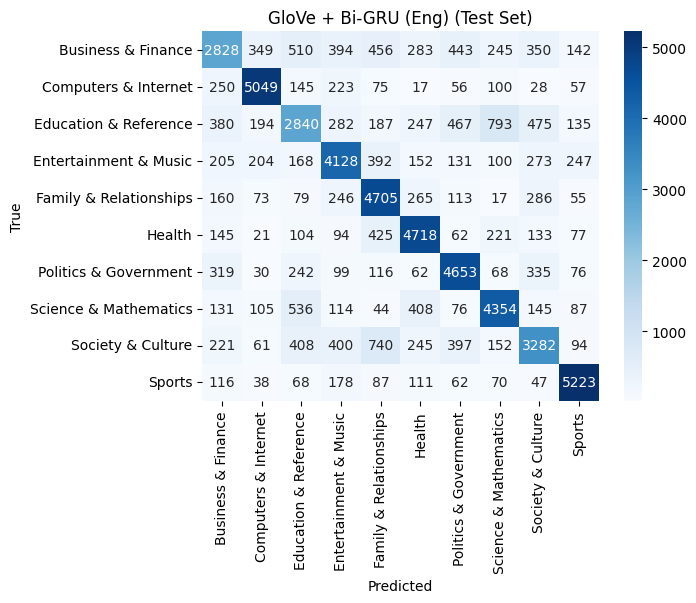

In [107]:
tf.keras.backend.clear_session()
bigru_eng = build_bigru(data_eng, vocab_size, embedding_matrix)
bigru_history_eng = run_nn_experiment(data_eng, tokenizer, bigru_eng, "GloVe + Bi-GRU (Eng)")


--- Training GloVe + Bi-GRU (Eng - Hyperparameter) ---
Epoch 1/1000
2334/2334 [==============================] - 53s 22ms/step - loss: 1.1410 - accuracy: 0.6347 - val_loss: 0.9822 - val_accuracy: 0.6877
Epoch 2/1000
2334/2334 [==============================] - 56s 24ms/step - loss: 0.9912 - accuracy: 0.6855 - val_loss: 0.9550 - val_accuracy: 0.6938
Epoch 3/1000
2334/2334 [==============================] - 50s 22ms/step - loss: 0.9409 - accuracy: 0.7007 - val_loss: 0.9335 - val_accuracy: 0.7009
Epoch 4/1000
2334/2334 [==============================] - 50s 21ms/step - loss: 0.9008 - accuracy: 0.7128 - val_loss: 0.9383 - val_accuracy: 0.6997
Epoch 5/1000
2334/2334 [==============================] - 50s 21ms/step - loss: 0.8567 - accuracy: 0.7275 - val_loss: 0.9505 - val_accuracy: 0.6964
Epoch 6/1000
2334/2334 [==============================] - 49s 21ms/step - loss: 0.8172 - accuracy: 0.7399 - val_loss: 0.9409 - val_accuracy: 0.7024
Epoch 7/1000
2334/2334 [==============================] 

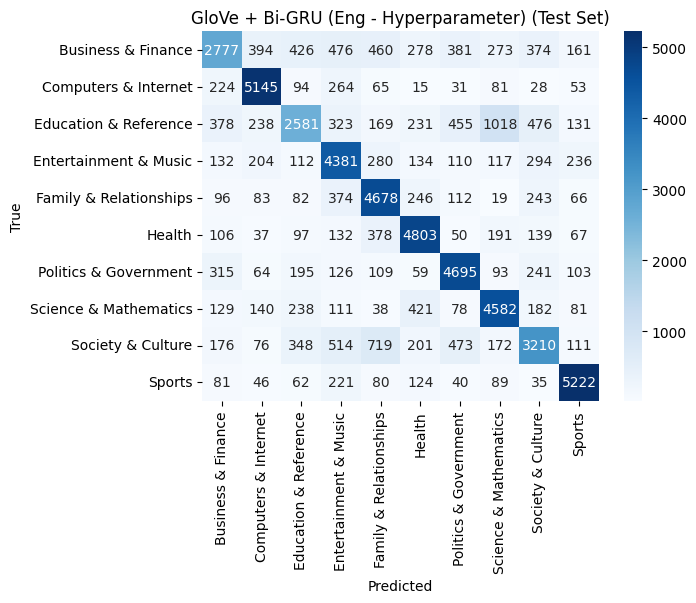

In [108]:
tf.keras.backend.clear_session()
bigru_hyper_eng = build_bigru_hyperparameter(data_eng, vocab_size, embedding_matrix)
bigru_hyper_history_eng = run_nn_experiment(data_eng, tokenizer, bigru_hyper_eng, "GloVe + Bi-GRU (Eng - Hyperparameter)")

Bi LSTM


--- Training GloVe + Bi-LSTM (Eng) ---
Epoch 1/1000
2334/2334 [==============================] - 30s 12ms/step - loss: 1.1447 - accuracy: 0.6345 - val_loss: 1.0078 - val_accuracy: 0.6768
Epoch 2/1000
2334/2334 [==============================] - 29s 12ms/step - loss: 1.0021 - accuracy: 0.6814 - val_loss: 0.9771 - val_accuracy: 0.6862
Epoch 3/1000
2334/2334 [==============================] - 28s 12ms/step - loss: 0.9584 - accuracy: 0.6921 - val_loss: 0.9461 - val_accuracy: 0.6948
Epoch 4/1000
2334/2334 [==============================] - 28s 12ms/step - loss: 0.9273 - accuracy: 0.7028 - val_loss: 0.9447 - val_accuracy: 0.6949
Epoch 5/1000
2334/2334 [==============================] - 29s 13ms/step - loss: 0.9004 - accuracy: 0.7085 - val_loss: 0.9453 - val_accuracy: 0.6946
Epoch 6/1000
2334/2334 [==============================] - 30s 13ms/step - loss: 0.8794 - accuracy: 0.7170 - val_loss: 0.9358 - val_accuracy: 0.6970
Epoch 7/1000
2334/2334 [==============================] - 31s 13ms/step 

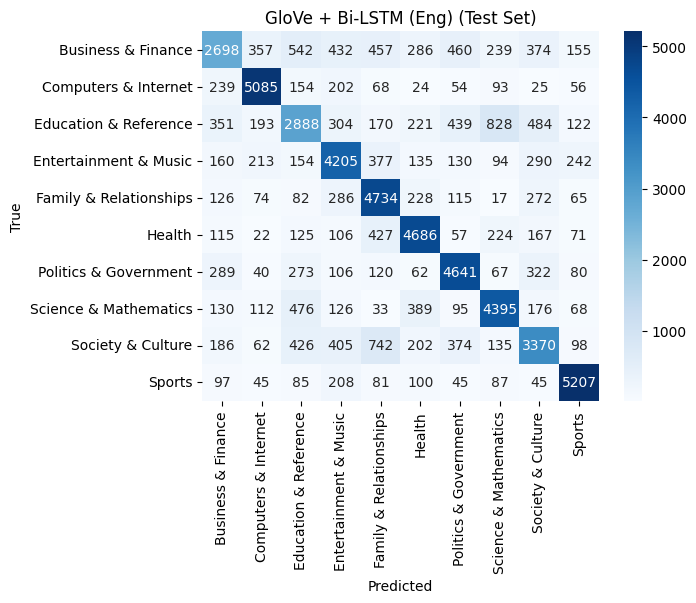

In [109]:
tf.keras.backend.clear_session()
bilstm_eng = build_bilstm(data_eng, vocab_size, embedding_matrix)
bilstm_history_eng = run_nn_experiment(data_eng, tokenizer, bilstm_eng, "GloVe + Bi-LSTM (Eng)")


--- Training GloVe + Bi-LSTM (Eng - Hyperparameter) ---
Epoch 1/1000
2334/2334 [==============================] - 62s 26ms/step - loss: 1.1351 - accuracy: 0.6412 - val_loss: 0.9887 - val_accuracy: 0.6821
Epoch 2/1000
2334/2334 [==============================] - 58s 25ms/step - loss: 0.9938 - accuracy: 0.6867 - val_loss: 0.9663 - val_accuracy: 0.6906
Epoch 3/1000
2334/2334 [==============================] - 58s 25ms/step - loss: 0.9422 - accuracy: 0.7010 - val_loss: 0.9325 - val_accuracy: 0.7007
Epoch 4/1000
2334/2334 [==============================] - 60s 26ms/step - loss: 0.8967 - accuracy: 0.7151 - val_loss: 0.9253 - val_accuracy: 0.7019
Epoch 5/1000
2334/2334 [==============================] - 60s 26ms/step - loss: 0.8539 - accuracy: 0.7275 - val_loss: 0.9288 - val_accuracy: 0.7008
Epoch 6/1000
2334/2334 [==============================] - 59s 25ms/step - loss: 0.8144 - accuracy: 0.7400 - val_loss: 0.9285 - val_accuracy: 0.7099
Epoch 7/1000
2334/2334 [==============================]

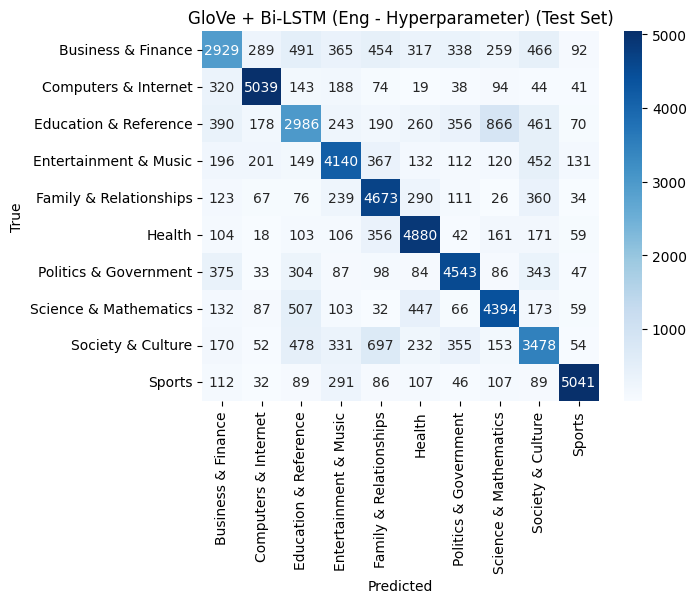

In [110]:
tf.keras.backend.clear_session()
bilstm_hyper_eng = build_bilstm_hyperparameter(data_eng, vocab_size, embedding_matrix)
bilstm_hyper_history_eng = run_nn_experiment(data_eng, tokenizer, bilstm_hyper_eng, "GloVe + Bi-LSTM (Eng - Hyperparameter)")

# 12. Final Plots

## 12.1 Loss & Accuracy Curves (All NN Models)

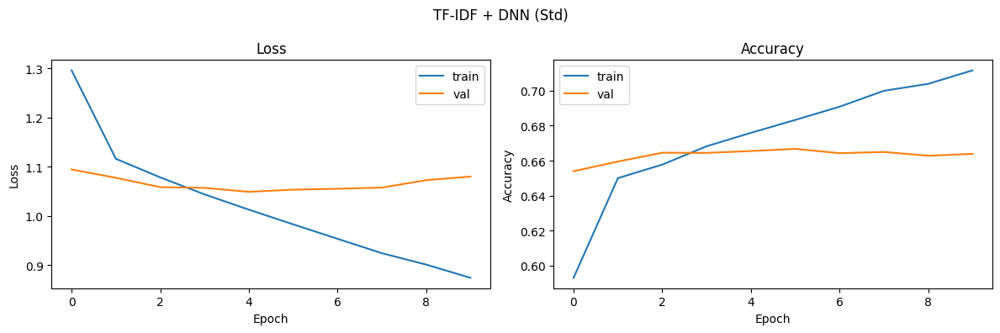

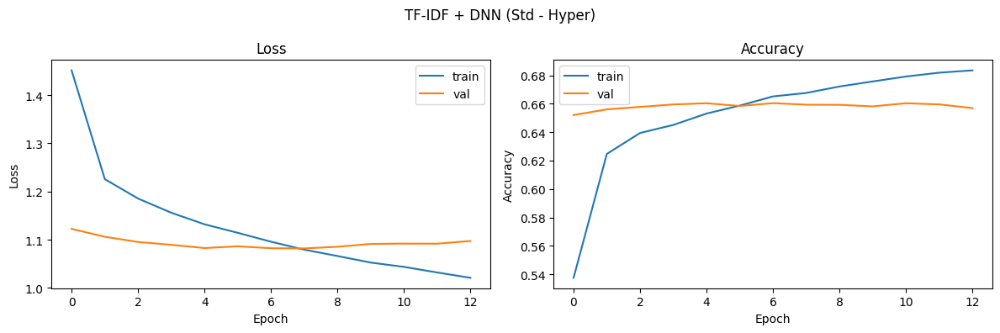

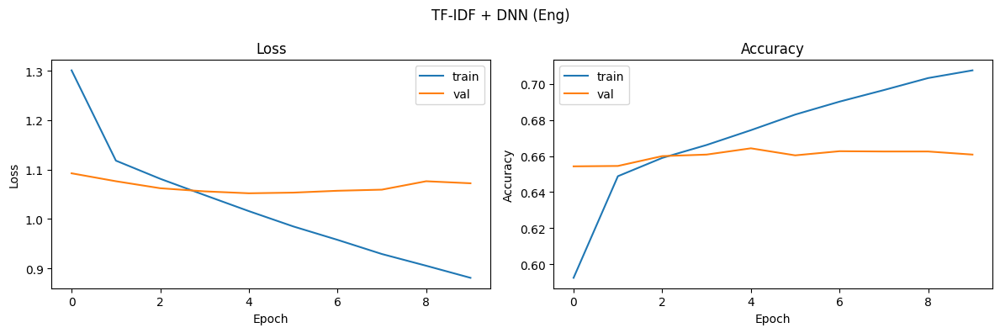

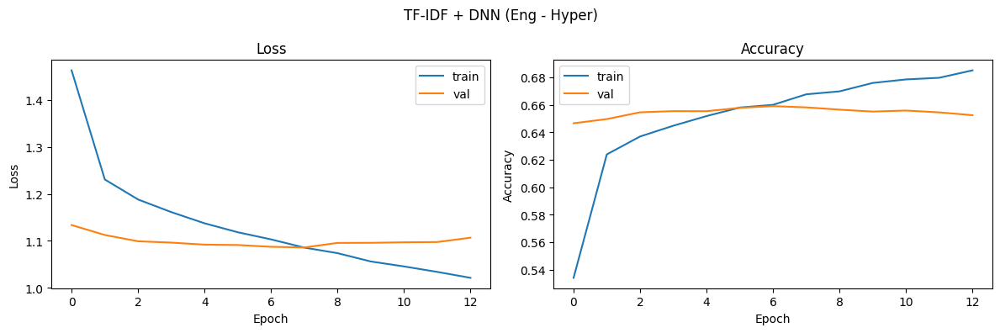

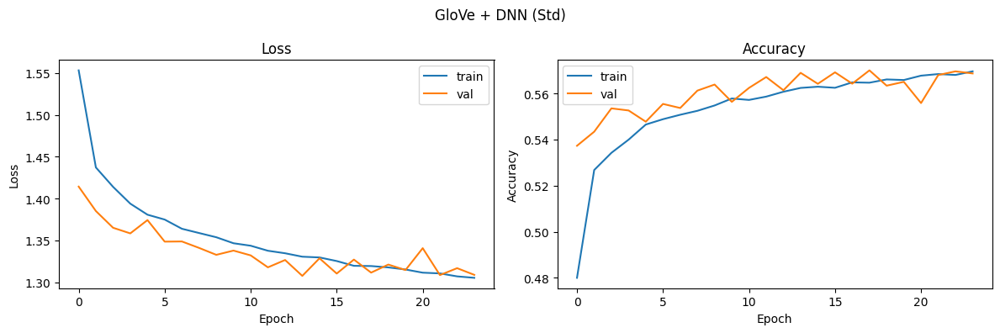

...

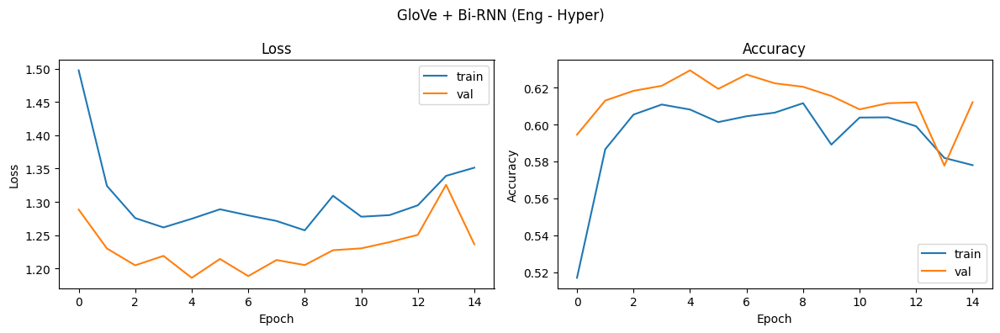

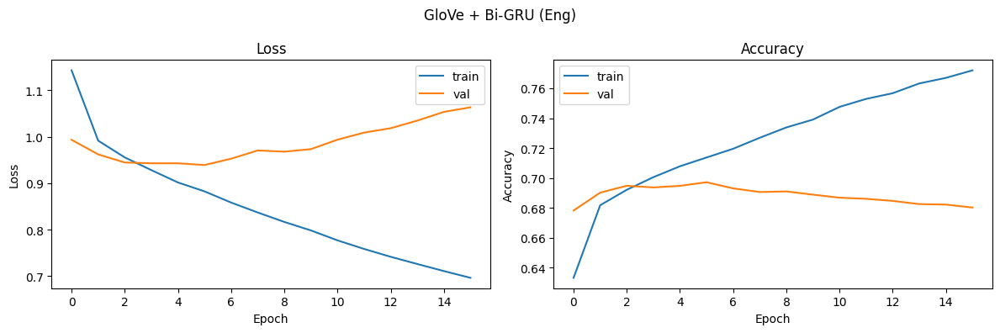

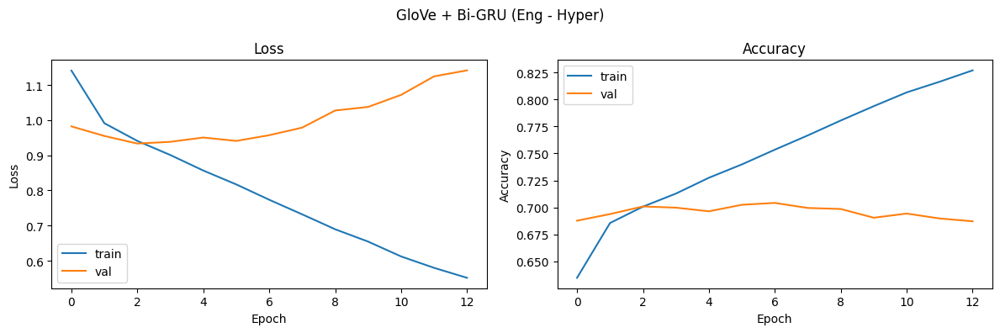

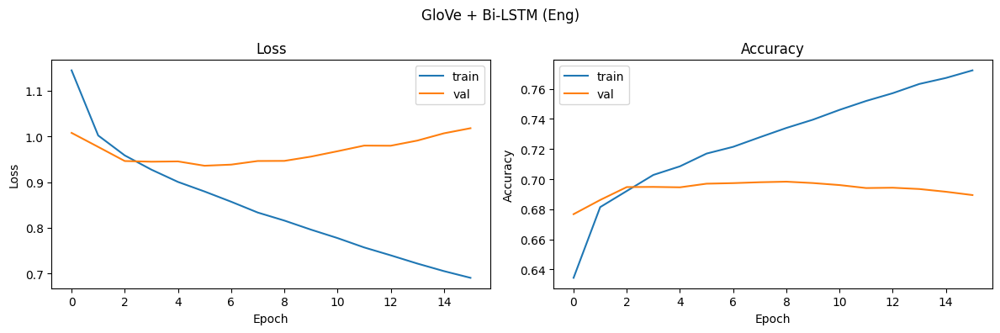

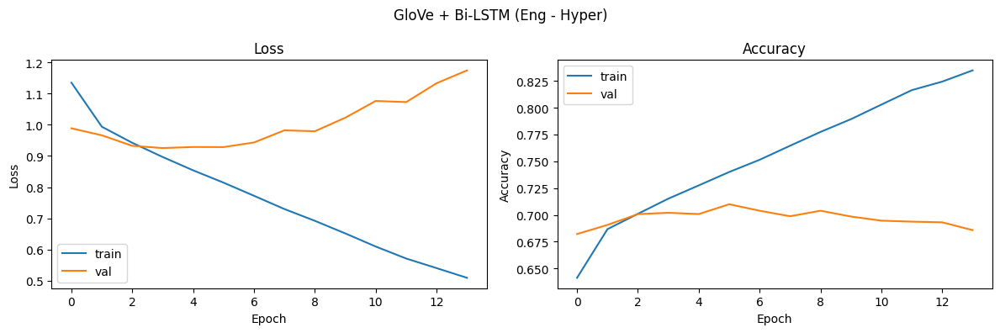

In [111]:
def _get_global(name: str):
    return globals().get(name, None)

def _history_metric(history, key: str):
    if history is None:
        return None
    h = getattr(history, "history", None)
    if not isinstance(h, dict):
        return None
    if key in h:
        return h[key]
    # Backward-compat for older Keras keys
    alt = {"accuracy": "acc", "val_accuracy": "val_acc"}.get(key)
    if alt and alt in h:
        return h[alt]
    return None

def plot_history(history, title: str):
    loss = _history_metric(history, "loss")
    val_loss = _history_metric(history, "val_loss")
    acc = _history_metric(history, "accuracy")
    val_acc = _history_metric(history, "val_accuracy")

    if loss is None and acc is None:
        print(f"[skip] No usable history for: {title}")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title)

    # Loss
    if loss is not None:
        axes[0].plot(loss, label="train")
    if val_loss is not None:
        axes[0].plot(val_loss, label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # Accuracy
    if acc is not None:
        axes[1].plot(acc, label="train")
    if val_acc is not None:
        axes[1].plot(val_acc, label="val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def collect_nn_histories():
    # Add/adjust names here if you add new NN models later.
    candidates = [
        # TF-IDF DNNs
        ("TF-IDF + DNN (Std)", "dnn_history_std"),
        ("TF-IDF + DNN (Std - Hyper)", "dnn_hyper_history_std"),
        ("TF-IDF + DNN (Eng)", "dnn_history_eng"),
        ("TF-IDF + DNN (Eng - Hyper)", "dnn_hyper_history_eng"),

        # GloVe / Skip-gram NN models (Std)
        ("GloVe + DNN (Std)", "embedded_dnn_history_std"),
        ("GloVe + DNN (Std - Hyper)", "embedded_dnn_hyper_history_std"),
        ("GloVe + RNN (Std)", "rnn_history_std"),
        ("GloVe + RNN (Std - Hyper)", "rnn_hyper_history_std"),
        ("GloVe + GRU (Std)", "gru_history_std"),
        ("GloVe + GRU (Std - Hyper)", "gru_hyper_history_std"),
        ("GloVe + LSTM (Std)", "lstm_history_std"),
        ("GloVe + LSTM (Std - Hyper)", "lstm_hyper_history_std"),
        ("GloVe + Bi-RNN (Std)", "birnn_history_std"),
        ("GloVe + Bi-RNN (Std - Hyper)", "birnn_hyper_history_std"),
        ("GloVe + Bi-GRU (Std)", "bigru_history_std"),
        ("GloVe + Bi-GRU (Std - Hyper)", "bigru_hyper_history_std"),
        ("GloVe + Bi-LSTM (Std)", "bilstm_history_std"),
        ("GloVe + Bi-LSTM (Std - Hyper)", "bilstm_hyper_history_std"),

        # GloVe / Skip-gram NN models (Eng)
        ("GloVe + DNN (Eng)", "embedded_dnn_history_eng"),
        ("GloVe + DNN (Eng - Hyper)", "embedded_dnn_hyper_history_eng"),
        ("GloVe + RNN (Eng)", "rnn_history_eng"),
        ("GloVe + RNN (Eng - Hyper)", "rnn_hyper_history_eng"),
        ("GloVe + GRU (Eng)", "gru_history_eng"),
        ("GloVe + GRU (Eng - Hyper)", "gru_hyper_history_eng"),
        ("GloVe + LSTM (Eng)", "lstm_history_eng"),
        ("GloVe + LSTM (Eng - Hyper)", "lstm_hyper_history_eng"),
        ("GloVe + Bi-RNN (Eng)", "birnn_history_eng"),
        ("GloVe + Bi-RNN (Eng - Hyper)", "birnn_hyper_history_eng"),
        ("GloVe + Bi-GRU (Eng)", "bigru_history_eng"),
        ("GloVe + Bi-GRU (Eng - Hyper)", "bigru_hyper_history_eng"),
        ("GloVe + Bi-LSTM (Eng)", "bilstm_history_eng"),
        ("GloVe + Bi-LSTM (Eng - Hyper)", "bilstm_hyper_history_eng"),
    ]

    histories = []
    for label, var in candidates:
        hist = _get_global(var)
        if hist is None:
            print(f"[skip] Missing history variable: {var}")
            continue
        histories.append((label, hist))
    return histories

# --- RUN 12.1 ---
for label, hist in collect_nn_histories():
    plot_history(hist, label)

## 12.2 ROC & AUC Curves (All Models)

[skip] TF-IDF + DNN (Std) failed: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.
[skip] TF-IDF + DNN (Std - Hyper) failed: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.
[skip] TF-IDF + DNN (Eng) failed: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.
[skip] TF-IDF + DNN (Eng - Hyper) failed: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.
1875/1875 [==============================] - 19s 10ms/step

AUC (micro-average) by model:
- GloVe + Bi-L

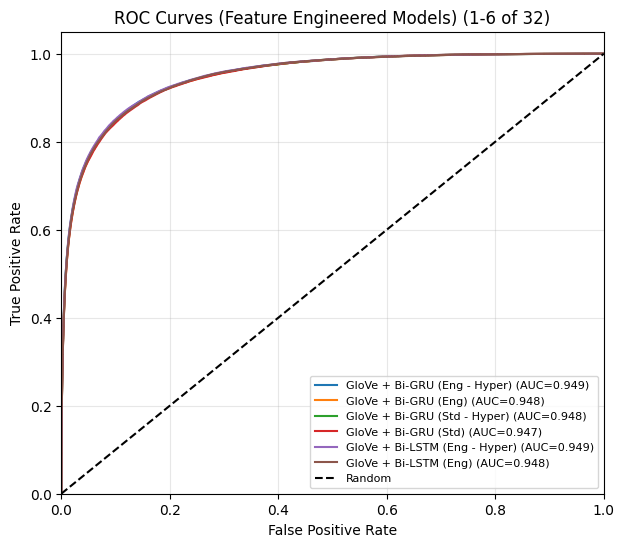

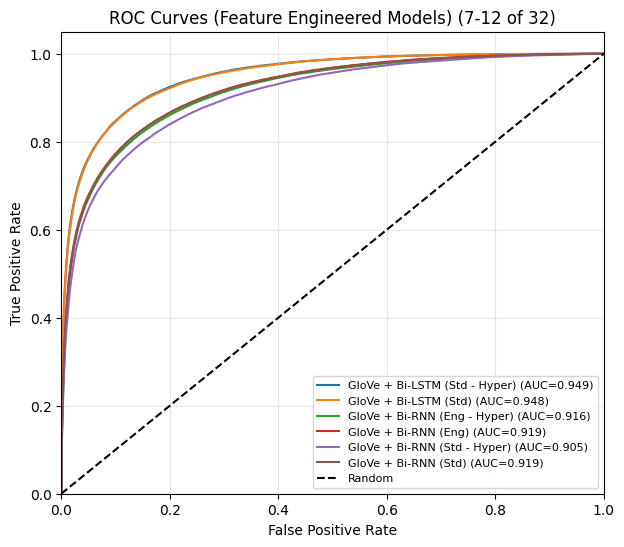

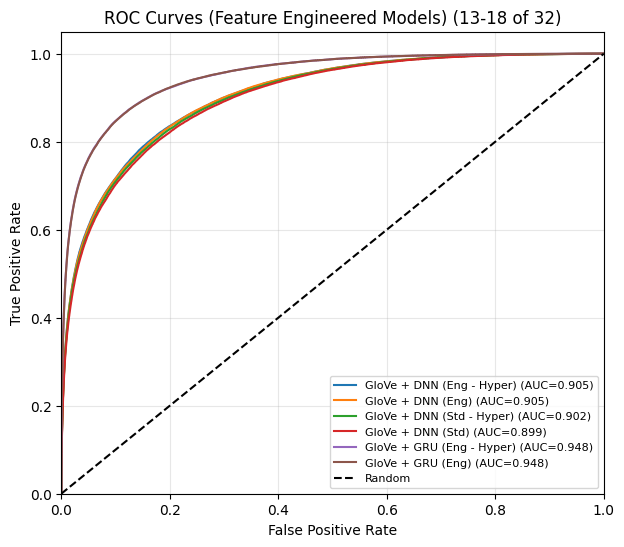

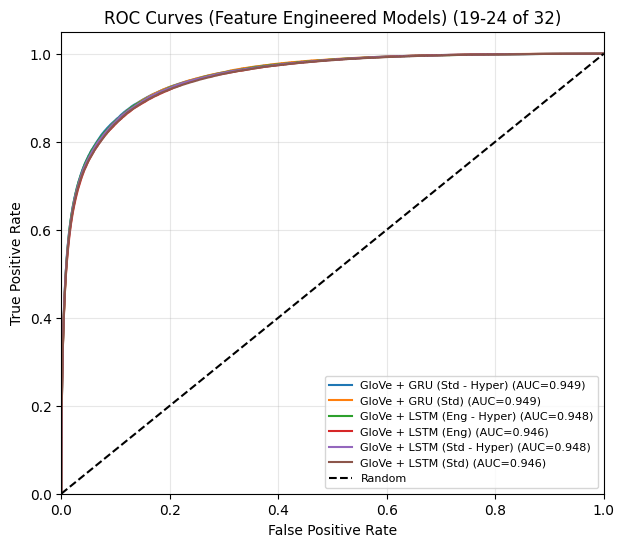

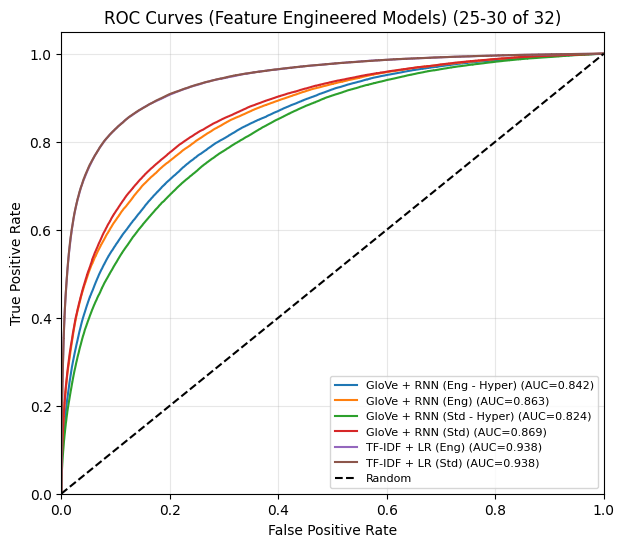

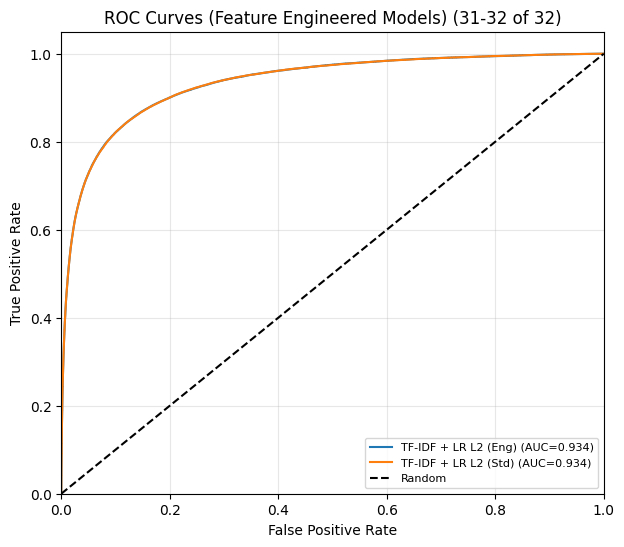

In [112]:
def _safe_predict_proba(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    raise TypeError(f"Model {model} does not support predict_proba().")

def _tfidf_test_matrix(data, vectorizer, dense: bool):
    X = vectorizer.transform(data["X_test"])
    return X.toarray().astype("float32") if dense else X

def get_probs_sklearn_tfidf(data, vectorizer, model):
    X_test = _tfidf_test_matrix(data, vectorizer, dense=False)
    return _safe_predict_proba(model, X_test)

def get_probs_tfidf_dnn(data, vectorizer, keras_model):
    X_test = _tfidf_test_matrix(data, vectorizer, dense=True)
    return keras_model.predict(X_test)

def get_probs_glove_nn(data, tokenizer, keras_model):
    # Uses your existing padding/sequence utility (section 10)
    _, _, X_test_seq = apply_pad_sequencing(tokenizer, data)
    return keras_model.predict(X_test_seq)

def compute_micro_roc_auc(y_true_int, y_score, num_classes: int):
    y_true_bin = label_binarize(y_true_int, classes=np.arange(num_classes))
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    return fpr, tpr, auc(fpr, tpr)

def build_model_specs():
    # Each entry describes how to get probabilities on the test set.
    # If a variable doesn't exist in the notebook run, it will be skipped safely.
    return [
        # TF-IDF (sklearn)
        {"label": "TF-IDF + LR (Std)", "kind": "sklearn_tfidf", "data": "data_std", "vectorizer": "tfidf_vectorizer_std", "model": "lr_model_std"},
        {"label": "TF-IDF + LR L2 (Std)", "kind": "sklearn_tfidf", "data": "data_std", "vectorizer": "tfidf_vectorizer_std", "model": "lr_model_hyper_std"},
        {"label": "TF-IDF + LR (Eng)", "kind": "sklearn_tfidf", "data": "data_eng", "vectorizer": "tfidf_vectorizer_eng", "model": "lr_model_eng"},
        {"label": "TF-IDF + LR L2 (Eng)", "kind": "sklearn_tfidf", "data": "data_eng", "vectorizer": "tfidf_vectorizer_eng", "model": "lr_model_hyper_eng"},

        # TF-IDF (DNN)
        {"label": "TF-IDF + DNN (Std)", "kind": "tfidf_dnn", "data": "data_std", "vectorizer": "tfidf_vectorizer_std", "model": "dnn_std"},
        {"label": "TF-IDF + DNN (Std - Hyper)", "kind": "tfidf_dnn", "data": "data_std", "vectorizer": "tfidf_vectorizer_std", "model": "dnn_std_hyper"},
        {"label": "TF-IDF + DNN (Eng)", "kind": "tfidf_dnn", "data": "data_eng", "vectorizer": "tfidf_vectorizer_eng", "model": "dnn_eng"},
        {"label": "TF-IDF + DNN (Eng - Hyper)", "kind": "tfidf_dnn", "data": "data_eng", "vectorizer": "tfidf_vectorizer_eng", "model": "dnn_eng_hyper"},

        # GloVe / Skip-gram (NN) - Std
        {"label": "GloVe + DNN (Std)", "kind": "glove_nn", "data": "data_std", "tokenizer": "tokenizer_std", "model": "embedded_dnn_std"},
        {"label": "GloVe + DNN (Std - Hyper)", "kind": "glove_nn", "data": "data_std", "tokenizer": "tokenizer_std", "model": "embedded_dnn_hyper_std"},
        {"label": "GloVe + RNN (Std)", "kind": "glove_nn", "data": "data_std", "tokenizer": "tokenizer_std", "model": "rnn_std"},
        {"label": "GloVe + RNN (Std - Hyper)", "kind": "glove_nn", "data": "data_std", "tokenizer": "tokenizer_std", "model": "rnn_hyper_std"},
        {"label": "GloVe + GRU (Std)", "kind": "glove_nn", "data": "data_std", "tokenizer": "tokenizer_std", "model": "gru_std"},
        {"label": "GloVe + GRU (Std - Hyper)", "kind": "glove_nn", "data": "data_std", "tokenizer": "tokenizer_std", "model": "gru_hyper_std"},
        {"label": "GloVe + LSTM (Std)", "kind": "glove_nn", "data": "data_std", "tokenizer": "tokenizer_std", "model": "lstm_std"},
        {"label": "GloVe + LSTM (Std - Hyper)", "kind": "glove_nn", "data": "data_std", "tokenizer": "tokenizer_std", "model": "lstm_hyper_std"},
        {"label": "GloVe + Bi-RNN (Std)", "kind": "glove_nn", "data": "data_std", "tokenizer": "tokenizer_std", "model": "birnn_std"},
        {"label": "GloVe + Bi-RNN (Std - Hyper)", "kind": "glove_nn", "data": "data_std", "tokenizer": "tokenizer_std", "model": "birnn_hyper_std"},
        {"label": "GloVe + Bi-GRU (Std)", "kind": "glove_nn", "data": "data_std", "tokenizer": "tokenizer_std", "model": "bigru_std"},
        {"label": "GloVe + Bi-GRU (Std - Hyper)", "kind": "glove_nn", "data": "data_std", "tokenizer": "tokenizer_std", "model": "bigru_hyper_std"},
        {"label": "GloVe + Bi-LSTM (Std)", "kind": "glove_nn", "data": "data_std", "tokenizer": "tokenizer_std", "model": "bilstm_std"},
        {"label": "GloVe + Bi-LSTM (Std - Hyper)", "kind": "glove_nn", "data": "data_std", "tokenizer": "tokenizer_std", "model": "bilstm_hyper_std"},

        # GloVe / Skip-gram (NN) - Eng
        {"label": "GloVe + DNN (Eng)", "kind": "glove_nn", "data": "data_eng", "tokenizer": "tokenizer_eng", "model": "embedded_dnn_eng"},
        {"label": "GloVe + DNN (Eng - Hyper)", "kind": "glove_nn", "data": "data_eng", "tokenizer": "tokenizer_eng", "model": "embedded_dnn_hyper_eng"},
        {"label": "GloVe + RNN (Eng)", "kind": "glove_nn", "data": "data_eng", "tokenizer": "tokenizer_eng", "model": "rnn_eng"},
        {"label": "GloVe + RNN (Eng - Hyper)", "kind": "glove_nn", "data": "data_eng", "tokenizer": "tokenizer_eng", "model": "rnn_hyper_eng"},
        {"label": "GloVe + GRU (Eng)", "kind": "glove_nn", "data": "data_eng", "tokenizer": "tokenizer_eng", "model": "gru_eng"},
        {"label": "GloVe + GRU (Eng - Hyper)", "kind": "glove_nn", "data": "data_eng", "tokenizer": "tokenizer_eng", "model": "gru_hyper_eng"},
        {"label": "GloVe + LSTM (Eng)", "kind": "glove_nn", "data": "data_eng", "tokenizer": "tokenizer_eng", "model": "lstm_eng"},
        {"label": "GloVe + LSTM (Eng - Hyper)", "kind": "glove_nn", "data": "data_eng", "tokenizer": "tokenizer_eng", "model": "lstm_hyper_eng"},
        {"label": "GloVe + Bi-RNN (Eng)", "kind": "glove_nn", "data": "data_eng", "tokenizer": "tokenizer_eng", "model": "birnn_eng"},
        {"label": "GloVe + Bi-RNN (Eng - Hyper)", "kind": "glove_nn", "data": "data_eng", "tokenizer": "tokenizer_eng", "model": "birnn_hyper_eng"},
        {"label": "GloVe + Bi-GRU (Eng)", "kind": "glove_nn", "data": "data_eng", "tokenizer": "tokenizer_eng", "model": "bigru_eng"},
        {"label": "GloVe + Bi-GRU (Eng - Hyper)", "kind": "glove_nn", "data": "data_eng", "tokenizer": "tokenizer_eng", "model": "bigru_hyper_eng"},
        {"label": "GloVe + Bi-LSTM (Eng)", "kind": "glove_nn", "data": "data_eng", "tokenizer": "tokenizer_eng", "model": "bilstm_eng"},
        {"label": "GloVe + Bi-LSTM (Eng - Hyper)", "kind": "glove_nn", "data": "data_eng", "tokenizer": "tokenizer_eng", "model": "bilstm_hyper_eng"},
    ]

def _resolve(name: str):
    return globals().get(name, None)

def collect_roc_results():
    results = []
    for spec in build_model_specs():
        data = _resolve(spec["data"])
        model = _resolve(spec["model"])
        if data is None or model is None:
            print(f"[skip] Missing: {spec['label']} ({spec['data']} or {spec['model']})")
            continue

        y_true = data["y_test_enc"]
        num_classes = int(data["num_classes"])

        try:
            if spec["kind"] == "sklearn_tfidf":
                vectorizer = _resolve(spec["vectorizer"])
                if vectorizer is None:
                    print(f"[skip] Missing vectorizer for: {spec['label']}")
                    continue
                y_score = get_probs_sklearn_tfidf(data, vectorizer, model)
            elif spec["kind"] == "tfidf_dnn":
                vectorizer = _resolve(spec["vectorizer"])
                if vectorizer is None:
                    print(f"[skip] Missing vectorizer for: {spec['label']}")
                    continue
                y_score = get_probs_tfidf_dnn(data, vectorizer, model)
            elif spec["kind"] == "glove_nn":
                tokenizer = _resolve(spec["tokenizer"])
                if tokenizer is None:
                    print(f"[skip] Missing tokenizer for: {spec['label']}")
                    continue
                y_score = get_probs_glove_nn(data, tokenizer, model)
            else:
                print(f"[skip] Unknown kind: {spec['kind']}")
                continue

            fpr, tpr, auc_value = compute_micro_roc_auc(y_true, y_score, num_classes=num_classes)
            results.append({"label": spec["label"], "fpr": fpr, "tpr": tpr, "auc": auc_value})
        except Exception as e:
            print(f"[skip] {spec['label']} failed: {e}")
            continue
    return results

def plot_roc_curves_in_batches(roc_results, title: str, max_models_per_fig: int = 6):
    if not roc_results:
        print("No ROC results to plot.")
        return

    # sort for stable order
    roc_results = sorted(roc_results, key=lambda r: r["label"])
    for start in range(0, len(roc_results), max_models_per_fig):
        chunk = roc_results[start:start + max_models_per_fig]
        plt.figure(figsize=(7, 6))
        for r in chunk:
            plt.plot(r["fpr"], r["tpr"], label=f"{r['label']} (AUC={r['auc']:.3f})")
        plt.plot([0, 1], [0, 1], "k--", label="Random")
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{title} ({start+1}-{start+len(chunk)} of {len(roc_results)})")
        plt.legend(loc="lower right", fontsize=8)
        plt.grid(True, alpha=0.3)
        plt.show()

def print_auc_table(roc_results):
    if not roc_results:
        return
    print("\nAUC (micro-average) by model:")
    for r in sorted(roc_results, key=lambda x: x["auc"], reverse=True):
        print(f"- {r['label']}: {r['auc']:.4f}")

# --- RUN 12.2 ---
roc_results = collect_roc_results()
print_auc_table(roc_results)
plot_roc_curves_in_batches(roc_results, title="ROC Curves (Feature Engineered Models)", max_models_per_fig=6)